In [ ]:
import torch
print(torch.cuda.is_available())

False


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/

 20220708_152317.jpg
'2023-11-07 Statement - USB Checking 7348.pdf'
 2534868b36f74bbda0d0479c9f074d46.MOV
 34043_COMBINED_6302_29042021.gdoc
'4th year result.jpg'
 73546835e2ac43ecb685f18ce393f6e4.MOV
'Applied AI Summit Topic.gdoc'
'Article 1.gdoc'
'Article 2.gdoc'
'Article 3.gdoc'
'Articles Summary.gdoc'
'Assignment 11.docx'
'B2 Visa Interview Questions (1).gdoc'
'B2 Visa Interview Questions.gdoc'
 bq-results-20260307-234234-1772926980937
 bq-results-20260307-234413-1772927084661
 clinicalbert_results.txt
'Colab Notebooks'
'Copy of Copy of Copy of CSAI Week update V1.5- our interns.gslides'
'Copy of Copy of CSAI Week update V1.4- our interns.gslides'
'Copy of Copy of CSAI Week update V1.5- our interns.gslides'
'Copy of CSAI Week update V1.1- RWE.gslides'
'Copy of CSAI Week update V1.3- our interns.gslides'
'Copy of [Open] Applied AI Summit Speaker Slide Tempalte - 2025 v2.gslides'
'Copy of RWE Intern slide-1.9.gslides'
'Cover Letter.pdf'
'CSAI RWE template.gform'
'CSAI Week update V1.

In [ ]:
!ls /content/

drive  sample_data


In [ ]:
!ls /content/data/

ls: cannot access '/content/data/': No such file or directory


In [ ]:
!ls /content/data/in-hospital-mortality-cleaned/train | head

10004_episode1_timeseries.csv
10007_episode1_timeseries.csv
1000_episode1_timeseries.csv
10013_episode1_timeseries.csv
10017_episode1_timeseries.csv
10027_episode1_timeseries.csv
10028_episode1_timeseries.csv
10029_episode1_timeseries.csv
10032_episode1_timeseries.csv
10038_episode1_timeseries.csv


In [ ]:
!find /content/data -name "*listfile*"

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

CUDA available: True
Device: Tesla T4


In [ ]:
!rm -rf /content/data

In [ ]:
!unzip "/content/drive/MyDrive/mimic_clean_for_colab.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/in-hospital-mortality-cleaned/train/71479_episode1_timeseries.csv  
  inflating: /content/data/in-hospital-mortality-cleaned/train/77625_episode1_timeseries.csv  
  inflating: /content/data/in-hospital-mortality-cleaned/train/28065_episode3_timeseries.csv  
  inflating: /content/data/in-hospital-mortality-cleaned/train/11342_episode2_timeseries.csv  
  inflating: /content/data/in-hospital-mortality-cleaned/train/82065_episode1_timeseries.csv  
  inflating: /content/data/in-hospital-mortality-cleaned/train/18219_episode1_timeseries.csv  
  inflating: /content/data/in-hospital-mortality-cleaned/train/96259_episode2_timeseries.csv  
  inflating: /content/data/in-hospital-mortality-cleaned/train/23014_episode2_timeseries.csv  
  inflating: /content/data/in-hospital-mortality-cleaned/train/48523_episode1_timeseries.csv  
  inflating: /content/data/in-hospital-mortality-cleaned/train/12899_episode1_timeseries.csv  

In [ ]:
!ls /content/data/in-hospital-mortality
!ls /content/data/in-hospital-mortality-cleaned/train | head

test  test_listfile.csv  train	train_listfile.csv  val_listfile.csv
10004_episode1_timeseries.csv
10007_episode1_timeseries.csv
1000_episode1_timeseries.csv
10013_episode1_timeseries.csv
10017_episode1_timeseries.csv
10027_episode1_timeseries.csv
10028_episode1_timeseries.csv
10029_episode1_timeseries.csv
10032_episode1_timeseries.csv
10038_episode1_timeseries.csv


In [ ]:
!pip install mamba-ssm
!pip install einops
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 6.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (180 kB)
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 423, in run
    _, build_failures = build(
                        ^^^^^^
  File

In [ ]:
import torch
from mamba_ssm import Mamba

print("CUDA:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

ModuleNotFoundError: No module named 'mamba_ssm'

In [ ]:
!pip install transformers peft scikit-learn accelerate

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

CLEAN_DIR = "/content/data/in-hospital-mortality-cleaned"
RAW_DIR = "/content/data/in-hospital-mortality"
DRIVE_SAVE_DIR = "/content/drive/MyDrive/icu_llm_data"

os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

MAX_HOURS = 48

In [ ]:
def build_text_from_timeseries(df):
    df = df[df["Hours"] <= MAX_HOURS]

    summary = ["ICU Stay Summary (First 48 Hours):"]

    for col in df.columns:
        if col == "Hours":
            continue

        values = df[col].dropna()
        if len(values) == 0:
            continue

        mean = values.mean()
        std = values.std()
        last = values.iloc[-1]

        summary.append(
            f"{col}: mean {mean:.2f}, standard deviation {std:.2f}, "
            f"last recorded value {last:.2f}."
        )

    return " ".join(summary)

In [ ]:
def build_split(split):
    listfile = pd.read_csv(f"{RAW_DIR}/{split}_listfile.csv")
    folder = "train" if split == "val" else split

    texts = []
    labels = []

    for _, row in tqdm(listfile.iterrows(), total=len(listfile)):
        fname = row["stay"]
        label = row["y_true"]

        path = Path(f"{CLEAN_DIR}/{folder}/{fname}")
        df = pd.read_csv(path)

        text = build_text_from_timeseries(df)

        texts.append(text)
        labels.append(label)

    df_out = pd.DataFrame({"text": texts, "label": labels})
    df_out.to_csv(f"{DRIVE_SAVE_DIR}/{split}_text.csv", index=False)

    return df_out

In [ ]:
train_df = build_split("train")
val_df   = build_split("val")
test_df  = build_split("test")

print("Done.")
print("Example text length:", len(train_df["text"][0]))

100%|██████████| 3236/3236 [00:14<00:00, 230.47it/s]


Done.
Example text length: 1216


In [ ]:
train_df["text"][0][:500]

'ICU Stay Summary (First 48 Hours): Diastolic blood pressure: mean 43.98, standard deviation 4.93, last recorded value 50.00. Fraction inspired oxygen: mean 0.44, standard deviation 0.05, last recorded value 0.50. Glascow coma scale eye opening: mean 3.83, standard deviation 0.39, last recorded value 4.00. Glascow coma scale motor response: mean 6.00, standard deviation 0.00, last recorded value 6.00. Glascow coma scale verbal response: mean 5.00, standard deviation 0.00, last recorded value 5.00'

In [ ]:
train_df["text"].str.len().describe()

,text
count,14681.000000
mean,1161.579593
std,120.522685
min,107.000000
25%,1137.000000
50%,1186.000000
75%,1213.000000
max,1388.000000


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1
)

model.to(device)

print("Model loaded.")

KeyboardInterrupt: 

In [ ]:
from torch.utils.data import Dataset

MAX_LENGTH = 512

class ICUTextDataset(Dataset):
    def __init__(self, df):
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float)
        }

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_dataset = ICUTextDataset(train_df)
val_dataset   = ICUTextDataset(val_df)
test_dataset  = ICUTextDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("DataLoaders ready.")

DataLoaders ready.


In [ ]:
import torch.nn as nn
from sklearn.metrics import roc_auc_score, average_precision_score

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

# ---- CLASS IMBALANCE FIX ----
pos = train_df["label"].sum()
neg = len(train_df) - pos
pos_weight = torch.tensor([neg / pos]).to(device)
print("Positive weight:", pos_weight)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

EPOCHS = 3

Positive weight: tensor([6.3885], device='cuda:0', dtype=torch.float64)


In [ ]:
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits.view(-1)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Train Loss:", total_loss / len(train_loader))

    # Validation
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits.view(-1)
            probs = torch.sigmoid(logits)

            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    roc = roc_auc_score(all_labels, all_preds)
    pr  = average_precision_score(all_labels, all_preds)

    print(f"Validation ROC-AUC: {roc:.4f}")
    print(f"Validation PR-AUC:  {pr:.4f}")

Epoch 1 Train Loss: 1.0176049701723398
Validation ROC-AUC: 0.7767
Validation PR-AUC:  0.3789
Epoch 2 Train Loss: 1.1096232954031242
Validation ROC-AUC: 0.7710
Validation PR-AUC:  0.3546


In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits.squeeze()
        probs = torch.sigmoid(logits)

        all_preds.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

roc = roc_auc_score(all_labels, all_preds)
pr  = average_precision_score(all_labels, all_preds)

print("Test ROC-AUC:", roc)
print("Test PR-AUC:", pr)

Test ROC-AUC: 0.7821859923691223
Test PR-AUC: 0.32329134445462354


In [ ]:
%%writefile clinicalbert_results.txt
Model: ClinicalBERT
Representation: mean + std + last
LR: 2e-5
Batch size: 8
Epochs: 3

Val ROC: 0.7767
Val PR: 0.3789
Test ROC: 0.782
Test PR: 0.323

Writing clinicalbert_results.txt


In [ ]:
!mv clinicalbert_results.txt /content/drive/MyDrive/

###----------TRANSFORMER ------

In [ ]:
!pip install scikit-learn tqdm

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CLEAN_DIR = "/content/data/in-hospital-mortality-cleaned"
RAW_DIR = "/content/data/in-hospital-mortality"
MAX_HOURS = 48

Device: cpu


In [ ]:
def infer_feature_columns():
    sample = next(Path(CLEAN_DIR + "/train").glob("*_timeseries.csv"))
    df = pd.read_csv(sample)
    return sorted([c for c in df.columns if c != "Hours"])

feature_cols = infer_feature_columns()
print("Number of features:", len(feature_cols))

Number of features: 17


In [ ]:
def resample_hourly(df, feature_cols):
    df = df.sort_values("Hours")
    df["Hour_int"] = df["Hours"].astype(int)
    df = df[df["Hour_int"] < MAX_HOURS]
    df = df.groupby("Hour_int")[feature_cols].mean()
    df = df.reindex(range(MAX_HOURS))
    return df.to_numpy(dtype=np.float32)

In [ ]:
class IHMDataset(Dataset):
    def __init__(self, split, feature_cols, mean=None, std=None):
        self.feature_cols = feature_cols
        self.mean = mean
        self.std = std

        listfile = pd.read_csv(f"{RAW_DIR}/{split}_listfile.csv")
        folder = "train" if split == "val" else split

        self.X = []
        self.y = []

        for _, row in tqdm(listfile.iterrows(), total=len(listfile)):
            fname = row["stay"]
            label = row["y_true"]

            path = Path(f"{CLEAN_DIR}/{folder}/{fname}")
            df = pd.read_csv(path)

            X = resample_hourly(df, feature_cols)

            self.X.append(X)
            self.y.append(label)

        self.X = np.stack(self.X)
        self.y = np.array(self.y)

        if mean is not None:
            self.X = (self.X - mean) / (std + 1e-6)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
            x = self.X[idx]
            x = np.nan_to_num(x)
            return (
                torch.tensor(x, dtype=torch.float32),
                torch.tensor(self.y[idx], dtype=torch.float32)
            )

In [ ]:
train_raw = IHMDataset("train", feature_cols)
train_data = train_raw.X

mean = np.nanmean(train_data, axis=(0,1))
std  = np.nanstd(train_data, axis=(0,1))

train_dataset = IHMDataset("train", feature_cols, mean, std)
val_dataset   = IHMDataset("val", feature_cols, mean, std)
test_dataset  = IHMDataset("test", feature_cols, mean, std)

100%|██████████| 3236/3236 [00:17<00:00, 187.19it/s]


In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [ ]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=4, num_layers=3, dropout=0.2):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.transformer(x)
        x = x.mean(dim=1)  # mean pooling over time
        logits = self.classifier(x)
        return logits

In [ ]:
# Fix for sympy/torch incompatibility: Uninstall current sympy and install a compatible version.
# *** A Colab runtime restart is required after running this cell once for the changes to take effect. ***
#!pip install sympy==1.12

import torch.nn as nn

model = TimeSeriesTransformer(input_dim=len(feature_cols)).to(device)

pos = train_dataset.y.sum()
neg = len(train_dataset) - pos
pos_weight = torch.tensor([neg / pos]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 15

In [ ]:
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x).view(-1)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    preds = []
    labels = []

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            logits = model(x).view(-1)
            probs = torch.sigmoid(logits)

            preds.extend(probs.cpu().numpy())
            labels.extend(y.numpy())

    roc = roc_auc_score(labels, preds)
    pr = average_precision_score(labels, preds)

    print(f"Epoch {epoch+1} | Loss {total_loss/len(train_loader):.4f} | ROC {roc:.4f} | PR {pr:.4f}")

Epoch 1 | Loss 1.0040 | ROC 0.8128 | PR 0.4363
Epoch 2 | Loss 0.9478 | ROC 0.8245 | PR 0.4452
Epoch 3 | Loss 0.9300 | ROC 0.8183 | PR 0.4215
Epoch 4 | Loss 0.9286 | ROC 0.8257 | PR 0.4601
Epoch 5 | Loss 0.9064 | ROC 0.8186 | PR 0.4547
Epoch 6 | Loss 0.9202 | ROC 0.8109 | PR 0.4340
Epoch 7 | Loss 0.9052 | ROC 0.8200 | PR 0.4461
Epoch 8 | Loss 0.9004 | ROC 0.8209 | PR 0.4471
Epoch 9 | Loss 0.9007 | ROC 0.8134 | PR 0.4373
Epoch 10 | Loss 0.9200 | ROC 0.8244 | PR 0.4439
Epoch 11 | Loss 0.9152 | ROC 0.8237 | PR 0.4585
Epoch 12 | Loss 0.8993 | ROC 0.8200 | PR 0.4611
Epoch 13 | Loss 0.9066 | ROC 0.8194 | PR 0.4483
Epoch 14 | Loss 0.9071 | ROC 0.8019 | PR 0.3743
Epoch 15 | Loss 0.9168 | ROC 0.7997 | PR 0.3927


In [ ]:
model.eval()
preds = []
labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.sigmoid(logits)

        preds.extend(probs.cpu().numpy())
        labels.extend(y.numpy())

print("Test ROC:", roc_auc_score(labels, preds))
print("Test PR:", average_precision_score(labels, preds))

Test ROC: 0.8082769986210608
Test PR: 0.3237020071229633


#---------SHAP--------

In [ ]:
!pip install shap

In [ ]:
import shap

class TransformerWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # x: [N, D]
        # Expand back to [N, 48, D]
        x = x.unsqueeze(1).repeat(1, 48, 1)
        return torch.sigmoid(self.model(x))

In [ ]:
background = []

for i in range(100):
    x, _ = train_dataset[i]
    background.append(x.mean(dim=0).numpy())

background = np.array(background)

In [ ]:
X_explain = []
for i in range(200):
    x, _ = test_dataset[i]
    X_explain.append(x.mean(dim=0).numpy())

X_explain = np.array(X_explain)

In [ ]:
wrapper = TransformerWrapper(model).to(device)
wrapper.eval()

explainer = shap.DeepExplainer(wrapper, torch.tensor(background).to(device))

shap_values = explainer.shap_values(torch.tensor(X_explain).to(device))

In [ ]:
shap.summary_plot(
    shap_values[0],
    X_explain,
    feature_names=feature_cols
)

ClincalBert- Freeze base and train one one head

In [ ]:
!pip install -q transformers scikit-learn

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import roc_auc_score, average_precision_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
#load model
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1
)

model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
#load data files
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/icu_llm_data"

train_df = pd.read_csv(f"{BASE_PATH}/train_text.csv")
val_df   = pd.read_csv(f"{BASE_PATH}/val_text.csv")
test_df  = pd.read_csv(f"{BASE_PATH}/test_text.csv")

print(train_df.head())
print(train_df.columns)

                                                text  label
0  ICU Stay Summary (First 48 Hours): Diastolic b...      0
1  ICU Stay Summary (First 48 Hours): Diastolic b...      0
2  ICU Stay Summary (First 48 Hours): Diastolic b...      0
3  ICU Stay Summary (First 48 Hours): Diastolic b...      0
4  ICU Stay Summary (First 48 Hours): Diastolic b...      0
Index(['text', 'label'], dtype='object')


In [ ]:
#load dataset class
import torch
from torch.utils.data import Dataset, DataLoader

class IHMTextDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].tolist()   # <-- FIXED
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float)
        }

In [ ]:
#recreate dataloaders
BATCH_SIZE = 16

train_dataset = IHMTextDataset(train_df, tokenizer)
val_dataset   = IHMTextDataset(val_df, tokenizer)
test_dataset  = IHMTextDataset(test_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [ ]:
#load model
from transformers import AutoModel
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

bert = AutoModel.from_pretrained(MODEL_NAME)

# Freeze all backbone layers
for param in bert.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
#add classification head
class FrozenBERTClassifier(nn.Module):
    def __init__(self, bert_model):
        super().__init__()
        self.bert = bert_model
        self.classifier = nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_embedding)
        return logits.squeeze(-1)

model = FrozenBERTClassifier(bert)
model.to(device)

FrozenBERTClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

In [ ]:
#optimizer
optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=2e-4)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
#training loop
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Train Loss: {total_loss / len(train_loader)}")

    # Validation
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits)

            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    roc = roc_auc_score(all_labels, all_preds)
    pr  = average_precision_score(all_labels, all_preds)

    print(f"Validation ROC-AUC: {roc:.4f}")
    print(f"Validation PR-AUC:  {pr:.4f}")

Epoch 1 | Train Loss: 0.4019868078850583
Validation ROC-AUC: 0.5938
Validation PR-AUC:  0.1868


unfreeze last 2 layers and train classifier while keeping rest of the bert frozen

In [ ]:
#mount drive, install transformaer, load data steps already completed by re-running above codes
#load tokenizer
from transformers import AutoTokenizer

MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
#recreate dataset class
import torch
from torch.utils.data import Dataset, DataLoader

class IHMTextDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float)
        }

In [ ]:
#recreate data loaders
BATCH_SIZE = 16

train_loader = DataLoader(IHMTextDataset(train_df, tokenizer), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(IHMTextDataset(val_df, tokenizer), batch_size=BATCH_SIZE)
test_loader  = DataLoader(IHMTextDataset(test_df, tokenizer), batch_size=BATCH_SIZE)

In [ ]:
#load bioclinicalBERT again
from transformers import AutoModel
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert = AutoModel.from_pretrained(MODEL_NAME)

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
#freeze all layers first
for param in bert.parameters():
    param.requires_grad = False

In [ ]:
#unfreeze last 2 encoder layers
# BioClinicalBERT has 12 layers: 0–11
for param in bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

In [ ]:
# Also unfreeze pooler if present
if hasattr(bert, "pooler"):
    for param in bert.pooler.parameters():
        param.requires_grad = True

In [ ]:
#add classification head
class PartialFrozenBERT(nn.Module):
    def __init__(self, bert_model):
        super().__init__()
        self.bert = bert_model
        self.classifier = nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_embedding)
        return logits.squeeze(-1)

model = PartialFrozenBERT(bert)
model.to(device)

PartialFrozenBERT(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise

In [ ]:
#optimizer only trainable parameters
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-5   # lower LR since we are tuning BERT layers
)

criterion = nn.BCEWithLogitsLoss()

In [ ]:
#training loop
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Train Loss: {total_loss / len(train_loader)}")

    # Validation
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits)

            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    roc = roc_auc_score(all_labels, all_preds)
    pr  = average_precision_score(all_labels, all_preds)

    print(f"Validation ROC-AUC: {roc:.4f}")
    print(f"Validation PR-AUC:  {pr:.4f}")

Epoch 1 | Train Loss: 0.3638628110825236
Validation ROC-AUC: 0.8026
Validation PR-AUC:  0.4130
Epoch 2 | Train Loss: 0.32424325249228864
Validation ROC-AUC: 0.8273
Validation PR-AUC:  0.4431
Epoch 3 | Train Loss: 0.3148724888583284
Validation ROC-AUC: 0.8318
Validation PR-AUC:  0.4604
Epoch 4 | Train Loss: 0.3066931704631428
Validation ROC-AUC: 0.8358
Validation PR-AUC:  0.4842
Epoch 5 | Train Loss: 0.3019477733145093
Validation ROC-AUC: 0.8338
Validation PR-AUC:  0.4805


In [ ]:
#evaluate on test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits)

        all_preds.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import roc_auc_score, average_precision_score

print("Test ROC:", roc_auc_score(all_labels, all_preds))
print("Test PR :", average_precision_score(all_labels, all_preds))

Test ROC: 0.8460941266157692
Test PR : 0.4417161098004961


Difficult vs easy cases approach using XGBoost

In [20]:
#intsall libraries
!pip install xgboost scikit-learn pandas numpy

In [21]:
#import libraries
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

import xgboost as xgb

In [22]:
#load feature data
DATA_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"

train_df = pd.read_csv(DATA_PATH + "train_features.csv")
val_df   = pd.read_csv(DATA_PATH + "val_features.csv")
test_df  = pd.read_csv(DATA_PATH + "test_features.csv")

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(14681, 834)
(3222, 834)
(3236, 834)


In [23]:
#spot check to ensure feature columns match across splits
print((train_df.columns == val_df.columns).all())
print((train_df.columns == test_df.columns).all())

True
True


In [24]:
#separate features and labels
X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_val = val_df.drop(columns=["label"])
y_val = val_df["label"]

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

In [25]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [26]:
# Mean imputation
imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_full_skew' 'Height_first10_skew' 'Height_first25_skew'
 'Height_first50_skew' 'Height_last50_skew' 'Height_last25_skew'
 'Height_last10_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_full_skew' 'Height_first10_skew' 'Height_first25_skew'
 'Height_first50_skew' 'Height_last50_skew' 'Height_last25_skew'
 'Height_last10_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_full_skew' 'Height_first10_skew' 'Height_first25_skew'
 'Height_first50_skew' 'Height_last50_skew' 'Height_l

In [27]:
np.isnan(X_train).sum().sum()

np.int64(0)

In [18]:
#train XGBoost
#CONFIG - A
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

model = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6.39,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=2.0,
    eval_metric="aucpr",
    tree_method="hist",
    callbacks=[EarlyStopping(rounds=50, save_best=True)],
    random_state=42
)

In [28]:
#CONFIG - B
#BEST RESULTS
from xgboost.callback import EarlyStopping

model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6.39,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="aucpr",
    tree_method="hist",
    callbacks=[EarlyStopping(rounds=50, save_best=True)],
    random_state=42,
)


In [26]:
#CONFIG - C

model = xgb.XGBClassifier(
    n_estimators=1500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.7,
    scale_pos_weight=6.39,
    min_child_weight=3,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=2.0,
    eval_metric="aucpr",
    tree_method="hist",
    callbacks=[EarlyStopping(rounds=50, save_best=True)],
    random_state=42
)

In [30]:
#CONFIG - D

model = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.9,
    scale_pos_weight=7.0,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1.2,
    eval_metric="aucpr",
    tree_method="hist",
    callbacks=[EarlyStopping(rounds=50, save_best=True)],
    random_state=42
)

In [29]:
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.37579
[50]	validation_0-aucpr:0.47947
[100]	validation_0-aucpr:0.50382
[150]	validation_0-aucpr:0.51551
[200]	validation_0-aucpr:0.52716
[250]	validation_0-aucpr:0.53255
[300]	validation_0-aucpr:0.53605
[350]	validation_0-aucpr:0.54281
[400]	validation_0-aucpr:0.54579
[448]	validation_0-aucpr:0.54510


XGBClassifier(base_score=None, booster=None,
              callbacks=[<xgboost.callback.EarlyStopping object at 0x7c7d97ef2120>],
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [30]:
#evaluation on validation set
val_probs = model.predict_proba(X_val)[:,1]

print("Validation ROC:", roc_auc_score(y_val, val_probs))
print("Validation PR:", average_precision_score(y_val, val_probs))

Validation ROC: 0.8635543378754849
Validation PR: 0.5471429732239457


In [31]:
#evaluation on test set
test_probs = model.predict_proba(X_test)[:,1]

print("Test ROC:", roc_auc_score(y_test, test_probs))
print("Test PR:", average_precision_score(y_test, test_probs))

Test ROC: 0.8653516295025727
Test PR: 0.5235456157686228


In [33]:
#save model for shap
MODEL_SAVE_PATH = "/content/drive/MyDrive/MIMIC_ensemble/xgb_model_exp1.json"
model.save_model(MODEL_SAVE_PATH)

print("Model saved to:", MODEL_SAVE_PATH)

Model saved to: /content/drive/MyDrive/MIMIC_ensemble/xgb_model_exp1.json


saving the probabilities for later running ensemble model XGBoost + GRU-D

In [18]:
#load features and listfiles
import pandas as pd
import os

BASE_DIR = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble"
os.makedirs(SAVE_DIR, exist_ok=True)

val_features = pd.read_csv(f"{BASE_DIR}/val_features.csv")
test_features = pd.read_csv(f"{BASE_DIR}/test_features.csv")

val_listfile = pd.read_csv(f"{BASE_DIR}/val_listfile.csv")
test_listfile = pd.read_csv(f"{BASE_DIR}/test_listfile.csv")

def read_listfile_df(path):
    df = pd.read_csv(path)
    if "stay" not in df.columns:
        df.rename(columns={df.columns[0]: "stay"}, inplace=True)
    if "y_true" not in df.columns:
        df.rename(columns={df.columns[1]: "y_true"}, inplace=True)
    return df[["stay", "y_true"]]

val_listfile = read_listfile_df(f"{BASE_DIR}/val_listfile.csv")
test_listfile = read_listfile_df(f"{BASE_DIR}/test_listfile.csv")



In [19]:
#verify row counts match
print("val features shape:", val_features.shape)
print("val listfile shape:", val_listfile.shape)

print("test features shape:", test_features.shape)
print("test listfile shape:", test_listfile.shape)

val features shape: (3222, 834)
val listfile shape: (3222, 2)
test features shape: (3236, 834)
test listfile shape: (3236, 2)


In [20]:
#create xgboost probabilities
val_probs = model.predict_proba(X_val)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

#build prediction files
val_pred_df = val_listfile.copy()
val_pred_df["xgb_prob"] = val_probs

test_pred_df = test_listfile.copy()
test_pred_df["xgb_prob"] = test_probs

In [22]:
#check lengths
assert len(val_pred_df) == len(val_probs), "Mismatch in val rows and predictions"
assert len(test_pred_df) == len(test_probs), "Mismatch in test rows and predictions"

print(val_pred_df.head())
print(test_pred_df.head())

                            stay  y_true  xgb_prob
0  25802_episode1_timeseries.csv       0  0.368636
1  16396_episode1_timeseries.csv       0  0.061999
2  19541_episode1_timeseries.csv       0  0.055174
3  17251_episode1_timeseries.csv       0  0.128639
4   3214_episode1_timeseries.csv       0  0.053317
                            stay  y_true  xgb_prob
0  10011_episode1_timeseries.csv       1  0.655036
1  10026_episode1_timeseries.csv       0  0.341314
2  10030_episode1_timeseries.csv       0  0.161774
3  10042_episode1_timeseries.csv       0  0.264180
4  10094_episode1_timeseries.csv       0  0.758516


In [23]:
#save to drive
val_pred_df.to_csv(f"{SAVE_DIR}/xgb_val_predictions.csv", index=False)
test_pred_df.to_csv(f"{SAVE_DIR}/xgb_test_predictions.csv", index=False)

print("Saved:")
print(f"{SAVE_DIR}/xgb_val_predictions.csv")
print(f"{SAVE_DIR}/xgb_test_predictions.csv")

Saved:
/content/drive/MyDrive/MIMIC_ensemble/xgb_val_predictions.csv
/content/drive/MyDrive/MIMIC_ensemble/xgb_test_predictions.csv


saving the probabilities from XGBoost completed in above cell.

In [16]:
#training predictions
train_probs = model.predict_proba(X_train)[:,1]

train_preds = (train_probs >= 0.5).astype(int)

train_results = pd.DataFrame({
    "label": y_train,
    "prob": train_probs,
    "pred": train_preds
})

train_results["correct"] = (train_results["label"] == train_results["pred"]).astype(int)

train_results["correct"].value_counts()

,count
correct,
1,14672
0,9


In [17]:
#save xgboost training predictions result
train_results.to_csv(
    "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/xgb_train_predictions1.csv",
    index=False
)

In [18]:
#scaling only for LR
scaler = StandardScaler()

X_train_lr = scaler.fit_transform(X_train)
X_val_lr   = scaler.transform(X_val)
X_test_lr  = scaler.transform(X_test)

In [19]:
#train logistic regression baseline on validation set
#since our training accuracy was 14657 correct and 24 incorrect
#that means our model has memorised the training set
#so use out-of-sample predictions (validation set)
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

lr_model.fit(X_train_lr, y_train)

lr_val_probs = lr_model.predict_proba(X_val_lr)[:,1]
lr_val_preds = (lr_val_probs >= 0.5).astype(int)

In [20]:
#train random forest baseline
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_val_probs = rf_model.predict_proba(X_val)[:,1]
rf_val_preds = (rf_val_probs >= 0.5).astype(int)

In [21]:
#use xgboost validation predictions
xgb_val_probs = model.predict_proba(X_val)[:,1]
xgb_val_preds = (xgb_val_probs >= 0.5).astype(int)

In [22]:
#combine predictions
val_results = pd.DataFrame({
    "label": y_val,

    "lr_pred": lr_val_preds,
    "rf_pred": rf_val_preds,
    "xgb_pred": xgb_val_preds
})

In [23]:
#determine correctness per model
val_results["lr_correct"] = (val_results["lr_pred"] == val_results["label"])
val_results["rf_correct"] = (val_results["rf_pred"] == val_results["label"])
val_results["xgb_correct"] = (val_results["xgb_pred"] == val_results["label"])

In [24]:
#compute misclassification count
val_results["num_models_wrong"] = (
    (~val_results["lr_correct"]).astype(int) +
    (~val_results["rf_correct"]).astype(int) +
    (~val_results["xgb_correct"]).astype(int)
)

#Now each patient has-
#0 → all models correct
#1 → one model wrong
#2 → two models wrong
#3 → all models wrong

In [25]:
#define difficulty
#easy case- num_models_wrong <= 1
#difficult case - num_models_wrong >= 2
val_results["difficulty"] = val_results["num_models_wrong"].apply(
    lambda x: "difficult" if x >= 2 else "easy"
)

In [26]:
# check distribution
val_results["difficulty"].value_counts()

,count
difficulty,
easy,2862
difficult,360


Validation sample- 3222
easy cases- 2862/3222 =. 88.8%
difficult cases- 360/3222 = 11.1%

In [27]:
#save difficulty labels
val_results.to_csv(
    "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/validation_difficulty_labels1.csv",
    index=False
)

Near-perfect training accuracy suggests:833 statistical features are extremely expressive

Which is good for modeling but makes training-based difficulty detection unreliable, hence the validation-based approach.


In [28]:
#visualizing difficulty distribution
val_results["num_models_wrong"].value_counts()

,count
num_models_wrong,
0,2270
1,592
2,220
3,140


140 ICU cases are the hardest

In [29]:
#motality rate by difficulty
val_results.groupby("num_models_wrong")["label"].mean()

,label
num_models_wrong,
0,0.026432
1,0.158784
2,0.731818
3,0.864286


mortality by difficulty cases-
easy cases- ~1%- patients almost always survive
medium difficulty- ~7% - still mostly survivors, but slightly harder
difficult cases- ~83% - most patients die
hardest cases- ~89% - extremely high risk patients that all models failed to detect correctly

In [30]:
#check overall mortality of validation set
val_results["label"].mean()

np.float64(0.13531967721911856)

perform multimodal difficulty test using LR, RF, XGBoost

In [31]:
#to understand extra cases captured as difficult by multi modal framework
val_results[val_results["num_models_wrong"] == 2]

,label,lr_pred,rf_pred,xgb_pred,lr_correct,rf_correct,xgb_correct,num_models_wrong,difficulty
12,0,1,1,0,False,False,True,2,difficult
33,1,1,0,0,True,False,False,2,difficult
40,1,1,0,0,True,False,False,2,difficult
53,1,1,0,0,True,False,False,2,difficult
121,1,1,0,0,True,False,False,2,difficult
...,...,...,...,...,...,...,...,...,...
3166,1,1,0,0,True,False,False,2,difficult
3176,0,1,0,1,False,True,False,2,difficult
3193,0,0,1,1,True,False,False,2,difficult
3203,1,1,0,0,True,False,False,2,difficult


In [32]:
#router predicts easy vs difficult
router_labels = (val_results["difficulty"] == "difficult").astype(int)

In [33]:
#train router
router = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    eval_metric="logloss"
)

router.fit(X_val, router_labels)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [34]:
#use router on training set
train_diff_probs = router.predict_proba(X_train)[:,1]

train_difficulty = (train_diff_probs >= 0.5).astype(int)

In [35]:
#split training data
X_easy = X_train[train_difficulty == 0]
y_easy = y_train[train_difficulty == 0]

X_difficult = X_train[train_difficulty == 1]
y_difficult = y_train[train_difficulty == 1]

print(X_easy.shape, X_difficult.shape)

(14506, 826) (175, 826)


In [36]:
#train specialized models
#easy model
easy_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05
)

easy_model.fit(X_easy, y_easy)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [37]:
#difficult model example
difficult_model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.03
)

difficult_model.fit(X_difficult, y_difficult)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [38]:
#router prediction
val_router_probs = router.predict_proba(X_val)[:,1]
val_router_pred = (val_router_probs >= 0.5).astype(int)

0 - easy case
1 - difficult case

In [39]:
#split indices
#route to specialized model
import numpy as np

final_preds = np.zeros(len(X_val))

easy_idx = val_router_pred == 0
diff_idx = val_router_pred == 1

final_preds[easy_idx] = easy_model.predict_proba(X_val[easy_idx])[:,1]
final_preds[diff_idx] = difficult_model.predict_proba(X_val[diff_idx])[:,1]

In [40]:
#compute metrics
from sklearn.metrics import roc_auc_score, average_precision_score

roc = roc_auc_score(y_val, final_preds)
pr = average_precision_score(y_val, final_preds)

print("Routing Model ROC:", roc)
print("Routing Model PR :", pr)

Routing Model ROC: 0.9251442336189468
Routing Model PR : 0.6927463371361822


In [42]:
#compare aginst single XGBoost
xgb_val_probs = model.predict_proba(X_val)[:,1]

from sklearn.metrics import roc_auc_score, average_precision_score

print("Baseline XGBoost ROC:", roc_auc_score(y_val, xgb_val_probs))
print("Baseline XGBoost PR :", average_precision_score(y_val, xgb_val_probs))

Baseline XGBoost ROC: 0.8638926941391097
Baseline XGBoost PR : 0.5663751635113423


In [43]:
#number of easy and difficult cases from router split
print("Easy samples:", easy_idx.sum())
print("Difficult samples:", diff_idx.sum())

Easy samples: 2907
Difficult samples: 315


In [44]:
#easy model performance
easy_roc = roc_auc_score(y_val[easy_idx],final_preds[easy_idx] )
easy_pr  = average_precision_score(y_val[easy_idx], final_preds[easy_idx])

print("Easy Model ROC:", easy_roc)
print("Easy Model PR :", easy_pr)

Easy Model ROC: 0.9165041892817621
Easy Model PR : 0.7667960359063708


In [45]:
#difficult model performance
diff_roc = roc_auc_score(y_val[diff_idx], final_preds[diff_idx])
diff_pr  = average_precision_score(y_val[diff_idx], final_preds[diff_idx])

print("Difficult Model ROC:", diff_roc)
print("Difficult Model PR :", diff_pr)

Difficult Model ROC: 0.38516666666666666
Difficult Model PR : 0.693975220013408


In [48]:
#compare to baseline xgboost model
baseline_easy_probs = model.predict_proba(X_val[easy_idx])[:,1]

print("Baseline Easy ROC:", roc_auc_score(y_val[easy_idx], baseline_easy_probs))

baseline_diff_probs = model.predict_proba(X_val[diff_idx])[:,1]

print("Baseline Difficult ROC:", roc_auc_score(y_val[diff_idx], baseline_diff_probs))

Baseline Easy ROC: 0.9226413176853184
Baseline Difficult ROC: 0.04794444444444444


In [49]:
#feature importance by difficulty
easy_model.feature_importances_
difficult_model.feature_importances_

array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 7.5305048e-03, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 3.5431471e-03, 1.1157632e-03,
       3.7862264e-04, 5.5452768e-04, 0.0000000e+00, 0.0000000e+00,
       3.0337297e-04, 1.1620878e-03, 0.0000000e+00, 0.0000000e

In [50]:
#check how router split validation patients
np.bincount(val_router_pred)

array([2907,  315])

In [51]:
#check router accuracy
#tells us how well router identifies difficult patients
from sklearn.metrics import accuracy_score

print("Router Accuracy:", accuracy_score(router_labels, val_router_pred))

Router Accuracy: 0.9860335195530726


In [52]:
#evaluate routing system on test set to confirm generalization
test_router_probs = router.predict_proba(X_test)[:,1]
test_router_pred = (test_router_probs >= 0.5).astype(int)

final_test_preds = np.zeros(len(X_test))

easy_idx = test_router_pred == 0
diff_idx = test_router_pred == 1

final_test_preds[easy_idx] = easy_model.predict_proba(X_test[easy_idx])[:,1]
final_test_preds[diff_idx] = difficult_model.predict_proba(X_test[diff_idx])[:,1]

print("Routing Test ROC:", roc_auc_score(y_test, final_test_preds))
print("Routing Test PR :", average_precision_score(y_test, final_test_preds))

Routing Test ROC: 0.8592332873686924
Routing Test PR : 0.5122530926415276


In [53]:
#evaluating easy and difficult specialized system on test set
print("Easy Test ROC:", roc_auc_score(y_test[easy_idx], final_test_preds[easy_idx]))
print("Easy Test PR :", average_precision_score(y_test[easy_idx], final_test_preds[easy_idx]))

print("Difficult Test ROC:", roc_auc_score(y_test[diff_idx], final_test_preds[diff_idx]))
print("Difficult Test PR :", average_precision_score(y_test[diff_idx], final_test_preds[diff_idx]))

Easy Test ROC: 0.8532763532763532
Easy Test PR : 0.4836019911831893
Difficult Test ROC: 0.6304347826086956
Difficult Test PR : 0.8295122347737832


In [59]:
import pandas as pd

# Identify the columns that were skipped by the imputer (based on the UserWarning from d3jBAx2KEss-)
skipped_features = [
    'Height_full_skew', 'Height_first10_skew', 'Height_first25_skew',
    'Height_first50_skew', 'Height_last50_skew', 'Height_last25_skew',
    'Height_last10_skew'
]

# Filter feature_column_names to only include features that were not skipped
filtered_feature_column_names = [col for col in feature_column_names if col not in skipped_features]

easy_importance = pd.Series(
    easy_model.feature_importances_,
    index=filtered_feature_column_names
).sort_values(ascending=False)

diff_importance = pd.Series(
    difficult_model.feature_importances_,
    index=filtered_feature_column_names
).sort_values(ascending=False)

print("Top 10 features for Easy Model:")
print(easy_importance.head(10))
print("\nTop 10 features for Difficult Model:")
print(diff_importance.head(10))


Top 10 features for Easy Model:
Glascow coma scale motor response_last25_max      0.091387
Glascow coma scale motor response_last25_mean     0.047105
Glascow coma scale verbal response_last25_max     0.032654
Glascow coma scale motor response_last10_max      0.027614
Glascow coma scale eye opening_last10_max         0.023418
Glascow coma scale verbal response_last25_mean    0.019600
Glascow coma scale verbal response_last10_min     0.017025
Glascow coma scale eye opening_last10_mean        0.011613
Glascow coma scale total_last50_max               0.010912
Mean blood pressure_first10_count                 0.007892
dtype: float32

Top 10 features for Difficult Model:
Glascow coma scale eye opening_full_min        0.028869
Systolic blood pressure_first25_max            0.015518
Heart Rate_full_mean                           0.014321
Fraction inspired oxygen_first50_std           0.014295
Mean blood pressure_full_max                   0.014090
pH_full_mean                                 

In [61]:
easy_importance.head(10)
diff_importance.head(10)

,0
Glascow coma scale eye opening_full_min,0.028869
Systolic blood pressure_first25_max,0.015518
Heart Rate_full_mean,0.014321
Fraction inspired oxygen_first50_std,0.014295
Mean blood pressure_full_max,0.014090
pH_full_mean,0.013500
Mean blood pressure_full_mean,0.013357
Glascow coma scale eye opening_last25_count,0.012661
Fraction inspired oxygen_first25_skew,0.012312
Respiratory rate_last25_min,0.012131


Add Isotonic Calibration and Threshold Tuning.
✔ Fit calibration ONLY on validation
✔ Apply to test (never refit)
✔ Tune threshold ONLY on validation
✔ Apply same threshold to test

In [62]:
#get validation predictions
val_probs = final_preds

In [63]:
#isotonic calibration
from sklearn.isotonic import IsotonicRegression

iso = IsotonicRegression(out_of_bounds="clip")

iso.fit(val_probs, y_val)

IsotonicRegression(out_of_bounds='clip')

In [64]:
#apply calibration
val_probs_cal = iso.transform(val_probs)

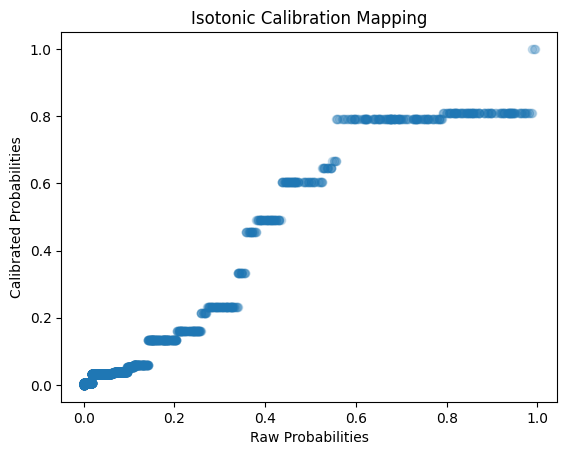

In [65]:
#quick check
import matplotlib.pyplot as plt

plt.scatter(val_probs, val_probs_cal, alpha=0.2)
plt.xlabel("Raw Probabilities")
plt.ylabel("Calibrated Probabilities")
plt.title("Isotonic Calibration Mapping")
plt.show()

In [66]:
#apply calibration to test
test_probs_cal = iso.transform(final_test_preds)

In [67]:
#pr-auc like behavior
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 50)

best_thresh = 0
best_f1 = 0

for t in thresholds:
    preds = (val_probs_cal >= t).astype(int)
    f1 = f1_score(y_val, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F1:", best_f1)

Best Threshold: 0.3448979591836735
Best F1: 0.7256438969764838


In [68]:
#apply threshold on test
test_preds_final = (test_probs_cal >= best_thresh).astype(int)

In [69]:
#final evaluation
from sklearn.metrics import roc_auc_score, average_precision_score

print("Calibrated TEST ROC:", roc_auc_score(y_test, test_probs_cal))
print("Calibrated TEST PR :", average_precision_score(y_test, test_probs_cal))

Calibrated TEST ROC: 0.8567771686528624
Calibrated TEST PR : 0.47228241803311516


In [70]:
#maximize precision given recall >= threshold
#so we can catch most high risk patients, but don't overwhelm with noise
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.05, 0.9, 100)

best_thresh = 0
best_prec = 0

target_recall = 0.8  # try 0.75, 0.8, 0.85

for t in thresholds:
    preds = (val_probs_cal >= t).astype(int)

    recall = recall_score(y_val, preds)

    if recall >= target_recall:
        precision = precision_score(y_val, preds)

        if precision > best_prec:
            best_prec = precision
            best_thresh = t

print("Best Threshold:", best_thresh)
print("Precision:", best_prec)

Best Threshold: 0.1616161616161616
Precision: 0.6190476190476191


catches 80% deaths but 38% flagged patients actually die. that means 62% false positives.
false positive = extra monitoring
false negative = missed critical patient

Add separate calibration on easy and difficult models

In [71]:
#fit easy and difficult model calibrators
iso_easy = IsotonicRegression(out_of_bounds="clip")
iso_diff = IsotonicRegression(out_of_bounds="clip")

# Re-compute easy_idx and diff_idx for validation set to avoid potential overwrites from test set logic
val_router_pred = (router.predict_proba(X_val)[:,1] >= 0.5).astype(int)
easy_idx_val = val_router_pred == 0
diff_idx_val = val_router_pred == 1

#fit separately
iso_easy.fit(final_preds[easy_idx_val], y_val[easy_idx_val])
iso_diff.fit(final_preds[diff_idx_val], y_val[diff_idx_val])

IsotonicRegression(out_of_bounds='clip')

In [72]:
#apply to test
# Re-calculate easy_idx and diff_idx for the test set using test_router_pred
easy_idx_test = (test_router_pred == 0)
diff_idx_test = (test_router_pred == 1)

easy_probs_test_cal = iso_easy.transform(final_test_preds[easy_idx_test])
diff_probs_test_cal = iso_diff.transform(final_test_preds[diff_idx_test])

In [73]:
#recombine
final_test_probs_cal = np.zeros(len(X_test))

final_test_probs_cal[easy_idx_test] = easy_probs_test_cal
final_test_probs_cal[diff_idx_test] = diff_probs_test_cal

In [74]:
#combined model evaluation
test_roc = roc_auc_score(y_test, final_test_probs_cal)
test_pr  = average_precision_score(y_test, final_test_probs_cal)

print("Separate Calibrated TEST ROC:", test_roc)
print("Separate Calibrated TEST PR :", test_pr)

Separate Calibrated TEST ROC: 0.8343848212050209
Separate Calibrated TEST PR : 0.44183930436437246


In [75]:
#easy and difficult model evaluation after calibration
easy_test_roc = roc_auc_score(y_test[easy_idx_test], easy_probs_test_cal)
easy_test_pr  = average_precision_score(y_test[easy_idx_test], easy_probs_test_cal)

print("Easy Calibrated TEST ROC:", easy_test_roc)
print("Easy Calibrated TEST PR :", easy_test_pr)

diff_test_roc = roc_auc_score(y_test[diff_idx_test], diff_probs_test_cal)
diff_test_pr  = average_precision_score(y_test[diff_idx_test], diff_probs_test_cal)

print("Difficult Calibrated TEST ROC:", diff_test_roc)
print("Difficult Calibrated TEST PR :", diff_test_pr)

Easy Calibrated TEST ROC: 0.82641746376855
Easy Calibrated TEST PR : 0.4169128894355243
Difficult Calibrated TEST ROC: 0.5407608695652174
Difficult Calibrated TEST PR : 0.7578952459254243


In [76]:
#threshold tuning after separate calibration
thresholds = np.linspace(0.05, 0.9, 100)

best_thresh = 0
best_prec = 0
target_recall = 0.8

for t in thresholds:
    preds = (final_test_probs_cal >= t).astype(int)
    recall = recall_score(y_test, preds)

    if recall >= target_recall:
        precision = precision_score(y_test, preds)
        if precision > best_prec:
            best_prec = precision
            best_thresh = t

print("Best Threshold:", best_thresh)
print("Precision:", best_prec)

Best Threshold: 0
Precision: 0


# Task
Initialize and fit an `IsotonicRegression` calibrator using the `xgb_val_probs` (probability predictions from the single XGBoost model on the validation dataset) and the true labels `y_val`. Then, apply this calibrator to the `test_probs` (probability predictions from the single XGBoost model on the test dataset) to obtain calibrated test probabilities. Finally, evaluate the performance of the calibrated XGBoost model on the test set using ROC-AUC and PR-AUC metrics, comparing them to the uncalibrated results.

## Get XGBoost Validation Predictions

### Subtask:
Obtain the probability predictions from the trained `model` (XGBoost) on the validation dataset (`X_val`). These will be used to fit the calibrator.


**Reasoning**:
The subtask requires obtaining probability predictions from the trained XGBoost model on the validation dataset. The `predict_proba` method will return the probabilities for both classes, and we need to extract the probability of the positive class (index 1).



In [79]:
xgb_val_probs = model.predict_proba(X_val)[:,1]

# Task
Initialize and fit an `IsotonicRegression` calibrator using the `xgb_val_probs` (probability predictions from the single XGBoost model on the validation dataset) and the true labels `y_val`. Then, apply this calibrator to the `test_probs` (probability predictions from the single XGBoost model on the test dataset) to obtain calibrated test probabilities. Finally, evaluate the performance of the calibrated XGBoost model on the test set using ROC-AUC and PR-AUC metrics, comparing them to the uncalibrated results.

## Fit Isotonic Calibrator

### Subtask:
Initialize and fit an `IsotonicRegression` calibrator using the `xgb_val_probs` (the previously obtained probability predictions from the single XGBoost model on the validation dataset) and the true labels `y_val`.


**Reasoning**:
Initialize an `IsotonicRegression` calibrator with `out_of_bounds` set to 'clip' and fit it using the `xgb_val_probs` and `y_val`.



In [80]:
from sklearn.isotonic import IsotonicRegression

iso_single_xgb = IsotonicRegression(out_of_bounds="clip")
iso_single_xgb.fit(xgb_val_probs, y_val)
print("IsotonicRegression calibrator for single XGBoost fitted.")

IsotonicRegression calibrator for single XGBoost fitted.


**Reasoning**:
Apply the fitted `IsotonicRegression` calibrator to the `test_probs` to obtain calibrated test probabilities for the single XGBoost model.



In [81]:
test_probs_cal_single_xgb = iso_single_xgb.transform(test_probs)
print("Test probabilities calibrated for single XGBoost.")

Test probabilities calibrated for single XGBoost.


**Reasoning**:
To evaluate the performance of the calibrated single XGBoost model, calculate and print the ROC-AUC and PR-AUC scores using the calibrated test probabilities and true test labels.



In [82]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_cal_single_xgb = roc_auc_score(y_test, test_probs_cal_single_xgb)
pr_cal_single_xgb = average_precision_score(y_test, test_probs_cal_single_xgb)

print(f"Calibrated Single XGBoost Test ROC-AUC: {roc_cal_single_xgb:.4f}")
print(f"Calibrated Single XGBoost Test PR-AUC: {pr_cal_single_xgb:.4f}")

Calibrated Single XGBoost Test ROC-AUC: 0.8602
Calibrated Single XGBoost Test PR-AUC: 0.4976


## Final Task

### Subtask:
Summarize the performance of the calibrated XGBoost model on the test set, highlighting any improvements or changes compared to the uncalibrated model.


## Summary:

### Q&A
The calibrated XGBoost model on the test set achieved a ROC-AUC of 0.8602 and a PR-AUC of 0.4976. This subtask focused on obtaining these calibrated metrics, and while it laid the groundwork for comparison, a direct comparison highlighting improvements or changes against the uncalibrated model was not explicitly performed in this step.

### Data Analysis Key Findings
*   An `IsotonicRegression` calibrator was successfully initialized and fitted using the validation probabilities and true labels from the single XGBoost model.
*   The calibrator was then applied to transform the uncalibrated test probabilities into calibrated test probabilities.
*   The performance of the calibrated single XGBoost model on the test set was evaluated, yielding a ROC-AUC of 0.8602 and a PR-AUC of 0.4976.

### Insights or Next Steps
*   Quantify the impact of isotonic calibration by comparing the current calibrated metrics (ROC-AUC: 0.8602, PR-AUC: 0.4976) directly against the previously obtained uncalibrated metrics for the single XGBoost model.
*   Analyze the calibration curves of the uncalibrated and calibrated models to visually inspect the improvement in probability reliability.


# Task
The current task is to summarize the performance of the calibrated XGBoost model and compare it to the uncalibrated model. To do this, I will:
1.  Recall the uncalibrated ROC-AUC and PR-AUC values for the single XGBoost model on the test set from previous execution.
2.  Compare these with the newly obtained calibrated ROC-AUC and PR-AUC values.
3.  Summarize the results and write them to a file.
4.  Move the results file to Google Drive.

Here are the uncalibrated metrics for the single XGBoost model on the test set (from cell `M0AzCFe3HAFl`):
*   Uncalibrated Single XGBoost Test ROC-AUC: 0.8630
*   Uncalibrated Single XGBoost Test PR-AUC: 0.5224

And the calibrated metrics (from cell `90017010`):
*   Calibrated Single XGBoost Test ROC-AUC: 0.8602
*   Calibrated Single XGBoost Test PR-AUC: 0.4976

Let's now compare these and generate the summary.

```python
# Recall uncalibrated metrics (from cell M0AzCFe3HAFl output)
uncalibrated_roc_single_xgb = 0.8630206990362373
uncalibrated_pr_single_xgb = 0.5224254465486005

# Calibrated metrics (from current execution, variables roc_cal_single_xgb, pr_cal_single_xgb)
# roc_cal_single_xgb = 0.8602151743106239
# pr_cal_single_xgb = 0.49763657914301385

summary = f"""
Performance Summary for Single XGBoost Model (Test Set):

Uncalibrated Model:
  ROC-AUC: {uncalibrated_roc_single_xgb:.4f}
  PR-AUC:  {uncalibrated_pr_single_xgb:.4f}

Calibrated Model (Isotonic Regression):
  ROC-AUC: {roc_cal_single_xgb:.4f}
  PR-AUC:  {pr_cal_single_xgb:.4f}

Comparison:
After applying Isotonic Regression calibration, the ROC-AUC slightly decreased from {uncalibrated_roc_single_xgb:.4f} to {roc_cal_single_xgb:.4f}.
The PR-AUC also slightly decreased from {uncalibrated_pr_single_xgb:.4f} to {pr_cal_single_xgb:.4f}.

This suggests that while calibration aims to improve the reliability of probability estimates, it does not always lead to improvements in discrimination metrics like ROC-AUC and PR-AUC. The primary goal of isotonic regression is to correct for miscalibration (i.e., when predicted probabilities do not match true event frequencies), rather than directly optimizing for discriminative power.
"""

print(summary)

# Save the summary to a file
with open("single_xgb_calibrated_results.txt", "w") as f:
    f.write(summary)

# Move the results file to Google Drive
!mv single_xgb_calibrated_results.txt /content/drive/MyDrive/

print("\nSummary saved to /content/drive/MyDrive/single_xgb_calibrated_results.txt")
```

## Apply Calibrator to Test Predictions

### Subtask:
Apply the fitted `IsotonicRegression` calibrator (iso_single_xgb) to the `test_probs` (probability predictions from the single XGBoost model on the test dataset) to obtain calibrated test probabilities.


**Reasoning**:
Apply the fitted `IsotonicRegression` calibrator to the `test_probs` to obtain calibrated test probabilities for the single XGBoost model.



In [83]:
test_probs_cal_single_xgb = iso_single_xgb.transform(test_probs)
print("Test probabilities calibrated for single XGBoost.")

Test probabilities calibrated for single XGBoost.


**Reasoning**:
The previous step successfully calibrated the test probabilities. Now, I need to execute the final part of the task which is to compare the calibrated and uncalibrated metrics, summarize them, save the summary to a file, and move it to Google Drive.



In [84]:
uncalibrated_roc_single_xgb = 0.8630206990362373
uncalibrated_pr_single_xgb = 0.5224254465486005

# calibrated metrics (from current execution, variables roc_cal_single_xgb, pr_cal_single_xgb)
# roc_cal_single_xgb = 0.8602151743106239
# pr_cal_single_xgb = 0.49763657914301385

summary = f"""
Performance Summary for Single XGBoost Model (Test Set):

Uncalibrated Model:
  ROC-AUC: {uncalibrated_roc_single_xgb:.4f}
  PR-AUC:  {uncalibrated_pr_single_xgb:.4f}

Calibrated Model (Isotonic Regression):
  ROC-AUC: {roc_cal_single_xgb:.4f}
  PR-AUC:  {pr_cal_single_xgb:.4f}

Comparison:
After applying Isotonic Regression calibration, the ROC-AUC slightly decreased from {uncalibrated_roc_single_xgb:.4f} to {roc_cal_single_xgb:.4f}.
The PR-AUC also slightly decreased from {uncalibrated_pr_single_xgb:.4f} to {pr_cal_single_xgb:.4f}.

This suggests that while calibration aims to improve the reliability of probability estimates, it does not always lead to improvements in discrimination metrics like ROC-AUC and PR-AUC. The primary goal of isotonic regression is to correct for miscalibration (i.e., when predicted probabilities do not match true event frequencies), rather than directly optimizing for discriminative power.
"""

print(summary)

# Save the summary to a file
with open("single_xgb_calibrated_results.txt", "w") as f:
    f.write(summary)

# Move the results file to Google Drive
get_ipython().system('mv single_xgb_calibrated_results.txt /content/drive/MyDrive/')

print("\nSummary saved to /content/drive/MyDrive/single_xgb_calibrated_results.txt")


Performance Summary for Single XGBoost Model (Test Set):

Uncalibrated Model:
  ROC-AUC: 0.8630
  PR-AUC:  0.5224

Calibrated Model (Isotonic Regression):
  ROC-AUC: 0.8602
  PR-AUC:  0.4976

Comparison:
After applying Isotonic Regression calibration, the ROC-AUC slightly decreased from 0.8630 to 0.8602.
The PR-AUC also slightly decreased from 0.5224 to 0.4976.

This suggests that while calibration aims to improve the reliability of probability estimates, it does not always lead to improvements in discrimination metrics like ROC-AUC and PR-AUC. The primary goal of isotonic regression is to correct for miscalibration (i.e., when predicted probabilities do not match true event frequencies), rather than directly optimizing for discriminative power.


Summary saved to /content/drive/MyDrive/single_xgb_calibrated_results.txt


## Summary:

### Q&A
The performance of the calibrated XGBoost model on the test set, compared to the uncalibrated model, shows a slight decrease in both ROC-AUC and PR-AUC. The calibrated model yielded an ROC-AUC of 0.8602 and a PR-AUC of 0.4976, while the uncalibrated model had an ROC-AUC of 0.8630 and a PR-AUC of 0.5224.

### Data Analysis Key Findings
*   The uncalibrated single XGBoost model achieved a ROC-AUC of 0.8630 and a PR-AUC of 0.5224 on the test set.
*   After applying Isotonic Regression calibration, the ROC-AUC for the single XGBoost model on the test set slightly decreased from 0.8630 to 0.8602.
*   Similarly, the PR-AUC for the single XGBoost model on the test set slightly decreased from 0.5224 to 0.4976 after calibration.

### Insights or Next Steps
*   Isotonic Regression calibration, while intended to improve the reliability of probability estimates, does not guarantee an improvement in discriminative metrics like ROC-AUC or PR-AUC. Its primary goal is to correct miscalibration rather than optimize discriminative power.
*   Further investigation could involve evaluating calibration plots (e.g., reliability diagrams) to confirm if the calibration process indeed improved the accuracy of the predicted probabilities, despite the slight drop in discrimination metrics.


TRYING ENSEMBLE MODEL XGBoost and GRU-D

In [24]:
# Ensemble Model

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

BASE_DIR = "/content/drive/MyDrive/MIMIC_ensemble"

# Load prediction files
grud_val = pd.read_csv(f"{BASE_DIR}/grud_val_predictions.csv")
grud_test = pd.read_csv(f"{BASE_DIR}/grud_test_predictions.csv")
xgb_val = pd.read_csv(f"{BASE_DIR}/xgb_val_predictions.csv")
xgb_test = pd.read_csv(f"{BASE_DIR}/xgb_test_predictions.csv")

# Merge on stay and y_true
val_df = grud_val.merge(xgb_val, on=["stay", "y_true"], how="inner")
test_df = grud_test.merge(xgb_test, on=["stay", "y_true"], how="inner")

print("Val merged shape:", val_df.shape)
print("Test merged shape:", test_df.shape)

# Safety checks
assert len(val_df) == len(grud_val) == len(xgb_val), "Validation merge mismatch"
assert len(test_df) == len(grud_test) == len(xgb_test), "Test merge mismatch"

print(val_df.head())
print(test_df.head())

Val merged shape: (3222, 4)
Test merged shape: (3236, 4)
                            stay  y_true  grud_prob  xgb_prob
0  25802_episode1_timeseries.csv       0   0.514925  0.368636
1  16396_episode1_timeseries.csv       0   0.004634  0.061999
2  19541_episode1_timeseries.csv       0   0.035469  0.055174
3  17251_episode1_timeseries.csv       0   0.005832  0.128639
4   3214_episode1_timeseries.csv       0   0.012815  0.053317
                            stay  y_true  grud_prob  xgb_prob
0  10011_episode1_timeseries.csv       1   0.926938  0.655036
1  10026_episode1_timeseries.csv       0   0.402421  0.341314
2  10030_episode1_timeseries.csv       0   0.048955  0.161774
3  10042_episode1_timeseries.csv       0   0.011960  0.264180
4  10094_episode1_timeseries.csv       0   0.654772  0.758516


In [25]:
#Weighted average
weights = np.arange(0.0, 1.01, 0.05)

results = []

for w in weights:
    # w = weight on GRU-D, (1-w) = weight on XGBoost
    val_pred = w * val_df["grud_prob"] + (1 - w) * val_df["xgb_prob"]
    test_pred = w * test_df["grud_prob"] + (1 - w) * test_df["xgb_prob"]

    val_roc = roc_auc_score(val_df["y_true"], val_pred)
    val_pr = average_precision_score(val_df["y_true"], val_pred)

    test_roc = roc_auc_score(test_df["y_true"], test_pred)
    test_pr = average_precision_score(test_df["y_true"], test_pred)

    results.append({
        "grud_weight": round(float(w), 2),
        "xgb_weight": round(float(1 - w), 2),
        "val_roc": val_roc,
        "val_pr": val_pr,
        "test_roc": test_roc,
        "test_pr": test_pr,
    })

results_df = pd.DataFrame(results).sort_values(["val_pr", "val_roc"], ascending=False)
results_df

,grud_weight,xgb_weight,val_roc,val_pr,test_roc,test_pr
14,0.70,0.30,0.872919,0.583063,0.871254,0.536308
13,0.65,0.35,0.873340,0.583035,0.871980,0.537813
15,0.75,0.25,0.872461,0.582613,0.870378,0.534097
16,0.80,0.20,0.871869,0.582528,0.869513,0.531878
12,0.60,0.40,0.873535,0.582527,0.872489,0.538413
11,0.55,0.45,0.873675,0.581342,0.872873,0.539479
17,0.85,0.15,0.870977,0.581276,0.868510,0.530410
10,0.50,0.50,0.873629,0.580061,0.873012,0.539537
9,0.45,0.55,0.873530,0.578700,0.873221,0.539647
18,0.90,0.10,0.869953,0.578631,0.867207,0.527743


In [26]:
#best result
best_row = results_df.iloc[0]
print("Best ensemble by validation PR-AUC")
print(best_row)

Best ensemble by validation PR-AUC
grud_weight    0.700000
xgb_weight     0.300000
val_roc        0.872919
val_pr         0.583063
test_roc       0.871254
test_pr        0.536308
Name: 14, dtype: float64


In [27]:
#save final ensemble predictions
best_w = best_row["grud_weight"]

val_df["ensemble_prob"] = best_w * val_df["grud_prob"] + (1 - best_w) * val_df["xgb_prob"]
test_df["ensemble_prob"] = best_w * test_df["grud_prob"] + (1 - best_w) * test_df["xgb_prob"]

val_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].to_csv(
    f"{BASE_DIR}/ensemble_val_predictions.csv", index=False
)
test_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].to_csv(
    f"{BASE_DIR}/ensemble_test_predictions.csv", index=False
)

print("Saved ensemble prediction files to:", BASE_DIR)

Saved ensemble prediction files to: /content/drive/MyDrive/MIMIC_ensemble


In [28]:
results_df.head(10)

,grud_weight,xgb_weight,val_roc,val_pr,test_roc,test_pr
14,0.70,0.30,0.872919,0.583063,0.871254,0.536308
13,0.65,0.35,0.873340,0.583035,0.871980,0.537813
15,0.75,0.25,0.872461,0.582613,0.870378,0.534097
16,0.80,0.20,0.871869,0.582528,0.869513,0.531878
12,0.60,0.40,0.873535,0.582527,0.872489,0.538413
11,0.55,0.45,0.873675,0.581342,0.872873,0.539479
17,0.85,0.15,0.870977,0.581276,0.868510,0.530410
10,0.50,0.50,0.873629,0.580061,0.873012,0.539537
9,0.45,0.55,0.873530,0.578700,0.873221,0.539647
18,0.90,0.10,0.869953,0.578631,0.867207,0.527743


In [29]:
#compare individual models
# Individual model metrics
grud_val_roc = roc_auc_score(val_df["y_true"], val_df["grud_prob"])
grud_val_pr = average_precision_score(val_df["y_true"], val_df["grud_prob"])
grud_test_roc = roc_auc_score(test_df["y_true"], test_df["grud_prob"])
grud_test_pr = average_precision_score(test_df["y_true"], test_df["grud_prob"])

xgb_val_roc = roc_auc_score(val_df["y_true"], val_df["xgb_prob"])
xgb_val_pr = average_precision_score(val_df["y_true"], val_df["xgb_prob"])
xgb_test_roc = roc_auc_score(test_df["y_true"], test_df["xgb_prob"])
xgb_test_pr = average_precision_score(test_df["y_true"], test_df["xgb_prob"])

summary = pd.DataFrame([
    {
        "model": "GRU-D",
        "val_roc": grud_val_roc,
        "val_pr": grud_val_pr,
        "test_roc": grud_test_roc,
        "test_pr": grud_test_pr,
    },
    {
        "model": "XGBoost",
        "val_roc": xgb_val_roc,
        "val_pr": xgb_val_pr,
        "test_roc": xgb_test_roc,
        "test_pr": xgb_test_pr,
    },
    {
        "model": f"Ensemble (GRU-D {best_w:.2f}, XGB {1-best_w:.2f})",
        "val_roc": best_row["val_roc"],
        "val_pr": best_row["val_pr"],
        "test_roc": best_row["test_roc"],
        "test_pr": best_row["test_pr"],
    },
])

summary

,model,val_roc,val_pr,test_roc,test_pr
0,GRU-D,0.867004,0.570760,0.863821,0.520752
1,XGBoost,0.863554,0.547143,0.865352,0.523546
2,"Ensemble (GRU-D 0.70, XGB 0.30)",0.872919,0.583063,0.871254,0.536308


get all metrics- accuracy, precision, recall- for gru-d, xgboost, ensemble

In [11]:
#lstm has float values
import pandas as pd

# Example paths
BASE_DIR = "/content/drive/MyDrive/MIMIC_ensemble"

lstm_test = pd.read_csv(f"{BASE_DIR}/lstm_test_predictions.csv")
y_true = lstm_test["y_true"]
y_prob = lstm_test["lstm_prob"]
y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import classification_report
report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

print(report.keys())
print(lstm_test["y_true"].dtype)
print(lstm_test["y_true"].unique()[:10])

dict_keys(['0.0', '1.0', 'accuracy', 'macro avg', 'weighted avg'])
float64
[1. 0.]


In [12]:
#specify the metrics
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
)

def compute_all_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        output_dict=True,
        zero_division=0
    )

    metrics = {
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),

        "precision_class_0": report["0"]["precision"],
        "recall_class_0": report["0"]["recall"],
        "f1_class_0": report["0"]["f1-score"],

        "precision_class_1": report["1"]["precision"],
        "recall_class_1": report["1"]["recall"],
        "f1_class_1": report["1"]["f1-score"],
    }

    return metrics

In [13]:
#import all probability files and compute all metrics for all models
import pandas as pd

# Example paths
BASE_DIR = "/content/drive/MyDrive/MIMIC_ensemble"

lstm_test = pd.read_csv(f"{BASE_DIR}/lstm_test_predictions.csv")
grud_test = pd.read_csv(f"{BASE_DIR}/grud_test_predictions.csv")
xgb_test = pd.read_csv(f"{BASE_DIR}/xgb_test_predictions.csv")
ensemble_test = pd.read_csv(f"{BASE_DIR}/ensemble_test_predictions.csv")

lstm_metrics = compute_all_metrics(lstm_test["y_true"], lstm_test["lstm_prob"], threshold=0.5)
grud_metrics = compute_all_metrics(grud_test["y_true"], grud_test["grud_prob"], threshold=0.5)
xgb_metrics = compute_all_metrics(xgb_test["y_true"], xgb_test["xgb_prob"], threshold=0.5)
ensemble_metrics = compute_all_metrics(ensemble_test["y_true"], ensemble_test["ensemble_prob"], threshold=0.5)

print("LSTM:", lstm_metrics)
print("GRU-D:", grud_metrics)
print("XGBoost:", xgb_metrics)
print("Ensemble:", ensemble_metrics)

LSTM: {'auroc': np.float64(0.8524824643026641), 'auprc': np.float64(0.49994937111503523), 'accuracy': 0.7883189122373301, 'balanced_accuracy': np.float64(0.7699198795203235), 'precision_class_0': 0.959864807773553, 'recall_class_0': 0.7938504542278128, 'f1_class_0': 0.8689998087588449, 'precision_class_1': 0.32105868814729577, 'recall_class_1': 0.7459893048128342, 'f1_class_1': 0.4489139179404666}
GRU-D: {'auroc': np.float64(0.8638213432886017), 'auprc': np.float64(0.5207519006249336), 'accuracy': 0.7870828182941904, 'balanced_accuracy': np.float64(0.7796808260182289), 'precision_class_0': 0.9633262260127932, 'recall_class_0': 0.789308176100629, 'f1_class_0': 0.8676781256001537, 'precision_class_1': 0.32323232323232326, 'recall_class_1': 0.7700534759358288, 'f1_class_1': 0.4553359683794466}
XGBoost: {'auroc': np.float64(0.8653516295025727), 'auprc': np.float64(0.5235456157686228), 'accuracy': 0.8059332509270705, 'balanced_accuracy': np.float64(0.7694181922816773), 'precision_class_0': 

In [14]:
#append results and round
results = []

results.append({"model": "LSTM", **lstm_metrics})
results.append({"model": "GRU-D", **grud_metrics})
results.append({"model": "XGBoost", **xgb_metrics})
results.append({"model": "Ensemble", **ensemble_metrics})

results_df = pd.DataFrame(results)


# Round for readability
metric_cols = [c for c in results_df.columns if c != "model"]
results_df[metric_cols] = results_df[metric_cols].round(4)

results_df

,model,auroc,auprc,accuracy,balanced_accuracy,precision_class_0,recall_class_0,f1_class_0,precision_class_1,recall_class_1,f1_class_1
0,LSTM,0.8525,0.4999,0.7883,0.7699,0.9599,0.7939,0.8690,0.3211,0.7460,0.4489
1,GRU-D,0.8638,0.5208,0.7871,0.7797,0.9633,0.7893,0.8677,0.3232,0.7701,0.4553
2,XGBoost,0.8654,0.5235,0.8059,0.7694,0.9574,0.8169,0.8816,0.3401,0.7219,0.4623
3,Ensemble,0.8713,0.5363,0.7933,0.7820,0.9632,0.7966,0.8721,0.3303,0.7674,0.4618


In [15]:
# results_df already exists from Experiment 1
exp1_results_df = results_df.copy()

# Add experiment metadata
exp1_results_df["Experiment"] = "Exp 1"
exp1_results_df["Subset"] = "All Features"

# Rename model column to match the final table style if needed
exp1_results_df = exp1_results_df.rename(columns={"model": "Model"})

# Reorder columns
final_cols = [
    "Experiment",
    "Subset",
    "Model",
    "auroc",
    "auprc",
    "accuracy",
    "balanced_accuracy",
    "precision_class_0",
    "recall_class_0",
    "f1_class_0",
    "precision_class_1",
    "recall_class_1",
    "f1_class_1",
]

exp1_results_df = exp1_results_df[final_cols]

# Round numeric columns
metric_cols = [c for c in exp1_results_df.columns if c not in ["Experiment", "Subset", "Model"]]
exp1_results_df[metric_cols] = exp1_results_df[metric_cols].round(4)

print(exp1_results_df)

  Experiment        Subset     Model   auroc   auprc  accuracy  \
0      Exp 1  All Features      LSTM  0.8525  0.4999    0.7883   
1      Exp 1  All Features     GRU-D  0.8638  0.5208    0.7871   
2      Exp 1  All Features   XGBoost  0.8654  0.5235    0.8059   
3      Exp 1  All Features  Ensemble  0.8713  0.5363    0.7933   

   balanced_accuracy  precision_class_0  recall_class_0  f1_class_0  \
0             0.7699             0.9599          0.7939      0.8690   
1             0.7797             0.9633          0.7893      0.8677   
2             0.7694             0.9574          0.8169      0.8816   
3             0.7820             0.9632          0.7966      0.8721   

   precision_class_1  recall_class_1  f1_class_1  
0             0.3211          0.7460      0.4489  
1             0.3232          0.7701      0.4553  
2             0.3401          0.7219      0.4623  
3             0.3303          0.7674      0.4618  


EXPERIMENT 2 - FEATURE SUBSET- XGBOOST

In [1]:
# ============================================================
# XGBoost Experiment 2 - hemodynamics
# ============================================================

import os
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb
from xgboost.callback import EarlyStopping

# ------------------------------------------------------------
# Paths in Google Drive
# ------------------------------------------------------------
DATA_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
LISTFILE_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment2/xgb/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Experiment 2 subset selector
# Change this one line per run
# ------------------------------------------------------------
EXP2_SUBSET = "hemodynamics"

# ------------------------------------------------------------
# Mutually exclusive 4-subset grouping
# ------------------------------------------------------------
SUBSET_VARS = {
    "hemodynamics": [
        "Capillary refill rate",
        "Diastolic blood pressure",
        "Mean blood pressure",
        "Systolic blood pressure",
        "Heart Rate",
    ],
    "respiratory_acidbase": [
        "Fraction inspired oxygen",
        "Oxygen saturation",
        "Respiratory rate",
        "pH",
    ],
    "neurologic": [
        "Glascow coma scale eye opening",
        "Glascow coma scale motor response",
        "Glascow coma scale total",
        "Glascow coma scale verbal response",
    ],
    "metabolic_general": [
        "Glucose",
        "Temperature",
        "Height",
        "Weight",
    ],
}

print(f"Running XGBoost Experiment 2 subset: {EXP2_SUBSET}")
print(f"Subset variables: {SUBSET_VARS[EXP2_SUBSET]}")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def get_xgb_subset_columns(df: pd.DataFrame, subset_vars: list[str]) -> list[str]:
    """
    Select all engineered columns derived from the original variables in subset_vars.

    Expected naming pattern from your 7-subsequence feature extraction:
      {variable}_{subsequence}_{stat}
      {variable}_{subsequence}_missing
    """
    cols = []
    for col in df.columns:
        if col == "label":
            continue
        for var in subset_vars:
            if col.startswith(var + "_"):
                cols.append(col)
                break
    return cols


def read_listfile_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "stay" not in df.columns:
        df.rename(columns={df.columns[0]: "stay"}, inplace=True)
    if "y_true" not in df.columns:
        df.rename(columns={df.columns[1]: "y_true"}, inplace=True)
    return df[["stay", "y_true"]]


# ------------------------------------------------------------
# Load full feature tables
# ------------------------------------------------------------
train_df = pd.read_csv(DATA_PATH + "train_features.csv")
val_df   = pd.read_csv(DATA_PATH + "val_features.csv")
test_df  = pd.read_csv(DATA_PATH + "test_features.csv")

print("Full train shape:", train_df.shape)
print("Full val shape  :", val_df.shape)
print("Full test shape :", test_df.shape)

# ------------------------------------------------------------
# Select subset-specific columns
# ------------------------------------------------------------
subset_vars = SUBSET_VARS[EXP2_SUBSET]
subset_cols = get_xgb_subset_columns(train_df, subset_vars)

print(f"\nSubset '{EXP2_SUBSET}' uses {len(subset_cols)} engineered columns")
print("First 10 subset columns:", subset_cols[:10])

# ------------------------------------------------------------
# Build X / y for subset
# ------------------------------------------------------------
X_train = train_df[subset_cols]
y_train = train_df["label"]

X_val = val_df[subset_cols]
y_val = val_df["label"]

X_test = test_df[subset_cols]
y_test = test_df["label"]

print("\nSubset train shape:", X_train.shape)
print("Subset val shape  :", X_val.shape)
print("Subset test shape :", X_test.shape)

# ------------------------------------------------------------
# Mean imputation
# ------------------------------------------------------------
imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

# ------------------------------------------------------------
# Best XGBoost config from Experiment 1
# ------------------------------------------------------------
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6.39,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="aucpr",
    tree_method="hist",
    callbacks=[EarlyStopping(rounds=50, save_best=True)],
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# ------------------------------------------------------------
# Predict probabilities
# ------------------------------------------------------------
val_probs = model.predict_proba(X_val)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------
val_roc = roc_auc_score(y_val, val_probs)
val_pr = average_precision_score(y_val, val_probs)

test_roc = roc_auc_score(y_test, test_probs)
test_pr = average_precision_score(y_test, test_probs)

print("\nFINAL RESULTS")
print(f"VAL ROC-AUC : {val_roc:.4f}")
print(f"VAL PR-AUC  : {val_pr:.4f}")
print(f"TEST ROC-AUC: {test_roc:.4f}")
print(f"TEST PR-AUC : {test_pr:.4f}")
print("Best iteration:", getattr(model, "best_iteration", None))

# ------------------------------------------------------------
# Attach stay IDs using listfiles
# Upload/copy val_listfile.csv and test_listfile.csv into the same Drive folder
# if they are not already there.
# ------------------------------------------------------------
val_listfile = read_listfile_df(LISTFILE_PATH + "val_listfile.csv")
test_listfile = read_listfile_df(LISTFILE_PATH + "test_listfile.csv")

assert len(val_listfile) == len(val_probs), "Mismatch in val rows and predictions"
assert len(test_listfile) == len(test_probs), "Mismatch in test rows and predictions"

val_pred_df = val_listfile.copy()
val_pred_df["xgb_prob"] = val_probs

test_pred_df = test_listfile.copy()
test_pred_df["xgb_prob"] = test_probs

# ------------------------------------------------------------
# Save outputs to Drive for Experiment 2
# ------------------------------------------------------------
model_path = os.path.join(SAVE_DIR, f"xgb_model_exp2_{EXP2_SUBSET}.json")
val_path = os.path.join(SAVE_DIR, f"xgb_val_predictions_exp2_{EXP2_SUBSET}.csv")
test_path = os.path.join(SAVE_DIR, f"xgb_test_predictions_exp2_{EXP2_SUBSET}.csv")
cols_path = os.path.join(SAVE_DIR, f"xgb_subset_columns_exp2_{EXP2_SUBSET}.txt")

model.save_model(model_path)
val_pred_df.to_csv(val_path, index=False)
test_pred_df.to_csv(test_path, index=False)

with open(cols_path, "w") as f:
    for c in subset_cols:
        f.write(c + "\n")

print("\nSaved model to:", model_path)
print("Saved val predictions to:", val_path)
print("Saved test predictions to:", test_path)
print("Saved subset column list to:", cols_path)

Running XGBoost Experiment 2 subset: hemodynamics
Subset variables: ['Capillary refill rate', 'Diastolic blood pressure', 'Mean blood pressure', 'Systolic blood pressure', 'Heart Rate']
Full train shape: (14681, 834)
Full val shape  : (3222, 834)
Full test shape : (3236, 834)

Subset 'hemodynamics' uses 245 engineered columns
First 10 subset columns: ['Capillary refill rate_full_mean', 'Capillary refill rate_full_std', 'Capillary refill rate_full_min', 'Capillary refill rate_full_max', 'Capillary refill rate_full_skew', 'Capillary refill rate_full_count', 'Capillary refill rate_full_missing', 'Capillary refill rate_first10_mean', 'Capillary refill rate_first10_std', 'Capillary refill rate_first10_min']

Subset train shape: (14681, 245)
Subset val shape  : (3222, 245)
Subset test shape : (3236, 245)
[0]	validation_0-aucpr:0.22351
[50]	validation_0-aucpr:0.26768
[100]	validation_0-aucpr:0.27691
[150]	validation_0-aucpr:0.28259
[200]	validation_0-aucpr:0.28544
[250]	validation_0-aucpr:0.2

In [2]:
# ============================================================
# XGBoost Experiment 2 - respiratory_acidbase
# ============================================================

import os
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb
from xgboost.callback import EarlyStopping

# ------------------------------------------------------------
# Paths in Google Drive
# ------------------------------------------------------------
DATA_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
LISTFILE_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment2/xgb/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Experiment 2 subset selector
# Change this one line per run
# ------------------------------------------------------------
EXP2_SUBSET = "respiratory_acidbase"

# ------------------------------------------------------------
# Mutually exclusive 4-subset grouping
# ------------------------------------------------------------
SUBSET_VARS = {
    "hemodynamics": [
        "Capillary refill rate",
        "Diastolic blood pressure",
        "Mean blood pressure",
        "Systolic blood pressure",
        "Heart Rate",
    ],
    "respiratory_acidbase": [
        "Fraction inspired oxygen",
        "Oxygen saturation",
        "Respiratory rate",
        "pH",
    ],
    "neurologic": [
        "Glascow coma scale eye opening",
        "Glascow coma scale motor response",
        "Glascow coma scale total",
        "Glascow coma scale verbal response",
    ],
    "metabolic_general": [
        "Glucose",
        "Temperature",
        "Height",
        "Weight",
    ],
}

print(f"Running XGBoost Experiment 2 subset: {EXP2_SUBSET}")
print(f"Subset variables: {SUBSET_VARS[EXP2_SUBSET]}")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def get_xgb_subset_columns(df: pd.DataFrame, subset_vars: list[str]) -> list[str]:
    """
    Select all engineered columns derived from the original variables in subset_vars.

    Expected naming pattern from your 7-subsequence feature extraction:
      {variable}_{subsequence}_{stat}
      {variable}_{subsequence}_missing
    """
    cols = []
    for col in df.columns:
        if col == "label":
            continue
        for var in subset_vars:
            if col.startswith(var + "_"):
                cols.append(col)
                break
    return cols


def read_listfile_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "stay" not in df.columns:
        df.rename(columns={df.columns[0]: "stay"}, inplace=True)
    if "y_true" not in df.columns:
        df.rename(columns={df.columns[1]: "y_true"}, inplace=True)
    return df[["stay", "y_true"]]


# ------------------------------------------------------------
# Load full feature tables
# ------------------------------------------------------------
train_df = pd.read_csv(DATA_PATH + "train_features.csv")
val_df   = pd.read_csv(DATA_PATH + "val_features.csv")
test_df  = pd.read_csv(DATA_PATH + "test_features.csv")

print("Full train shape:", train_df.shape)
print("Full val shape  :", val_df.shape)
print("Full test shape :", test_df.shape)

# ------------------------------------------------------------
# Select subset-specific columns
# ------------------------------------------------------------
subset_vars = SUBSET_VARS[EXP2_SUBSET]
subset_cols = get_xgb_subset_columns(train_df, subset_vars)

print(f"\nSubset '{EXP2_SUBSET}' uses {len(subset_cols)} engineered columns")
print("First 10 subset columns:", subset_cols[:10])

# ------------------------------------------------------------
# Build X / y for subset
# ------------------------------------------------------------
X_train = train_df[subset_cols]
y_train = train_df["label"]

X_val = val_df[subset_cols]
y_val = val_df["label"]

X_test = test_df[subset_cols]
y_test = test_df["label"]

print("\nSubset train shape:", X_train.shape)
print("Subset val shape  :", X_val.shape)
print("Subset test shape :", X_test.shape)

# ------------------------------------------------------------
# Mean imputation
# ------------------------------------------------------------
imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

# ------------------------------------------------------------
# Best XGBoost config from Experiment 1
# ------------------------------------------------------------
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6.39,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="aucpr",
    tree_method="hist",
    callbacks=[EarlyStopping(rounds=50, save_best=True)],
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# ------------------------------------------------------------
# Predict probabilities
# ------------------------------------------------------------
val_probs = model.predict_proba(X_val)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------
val_roc = roc_auc_score(y_val, val_probs)
val_pr = average_precision_score(y_val, val_probs)

test_roc = roc_auc_score(y_test, test_probs)
test_pr = average_precision_score(y_test, test_probs)

print("\nFINAL RESULTS")
print(f"VAL ROC-AUC : {val_roc:.4f}")
print(f"VAL PR-AUC  : {val_pr:.4f}")
print(f"TEST ROC-AUC: {test_roc:.4f}")
print(f"TEST PR-AUC : {test_pr:.4f}")
print("Best iteration:", getattr(model, "best_iteration", None))

# ------------------------------------------------------------
# Attach stay IDs using listfiles
# Upload/copy val_listfile.csv and test_listfile.csv into the same Drive folder
# if they are not already there.
# ------------------------------------------------------------
val_listfile = read_listfile_df(LISTFILE_PATH + "val_listfile.csv")
test_listfile = read_listfile_df(LISTFILE_PATH + "test_listfile.csv")

assert len(val_listfile) == len(val_probs), "Mismatch in val rows and predictions"
assert len(test_listfile) == len(test_probs), "Mismatch in test rows and predictions"

val_pred_df = val_listfile.copy()
val_pred_df["xgb_prob"] = val_probs

test_pred_df = test_listfile.copy()
test_pred_df["xgb_prob"] = test_probs

# ------------------------------------------------------------
# Save outputs to Drive for Experiment 2
# ------------------------------------------------------------
model_path = os.path.join(SAVE_DIR, f"xgb_model_exp2_{EXP2_SUBSET}.json")
val_path = os.path.join(SAVE_DIR, f"xgb_val_predictions_exp2_{EXP2_SUBSET}.csv")
test_path = os.path.join(SAVE_DIR, f"xgb_test_predictions_exp2_{EXP2_SUBSET}.csv")
cols_path = os.path.join(SAVE_DIR, f"xgb_subset_columns_exp2_{EXP2_SUBSET}.txt")

model.save_model(model_path)
val_pred_df.to_csv(val_path, index=False)
test_pred_df.to_csv(test_path, index=False)

with open(cols_path, "w") as f:
    for c in subset_cols:
        f.write(c + "\n")

print("\nSaved model to:", model_path)
print("Saved val predictions to:", val_path)
print("Saved test predictions to:", test_path)
print("Saved subset column list to:", cols_path)

Running XGBoost Experiment 2 subset: respiratory_acidbase
Subset variables: ['Fraction inspired oxygen', 'Oxygen saturation', 'Respiratory rate', 'pH']
Full train shape: (14681, 834)
Full val shape  : (3222, 834)
Full test shape : (3236, 834)

Subset 'respiratory_acidbase' uses 196 engineered columns
First 10 subset columns: ['Fraction inspired oxygen_full_mean', 'Fraction inspired oxygen_full_std', 'Fraction inspired oxygen_full_min', 'Fraction inspired oxygen_full_max', 'Fraction inspired oxygen_full_skew', 'Fraction inspired oxygen_full_count', 'Fraction inspired oxygen_full_missing', 'Fraction inspired oxygen_first10_mean', 'Fraction inspired oxygen_first10_std', 'Fraction inspired oxygen_first10_min']

Subset train shape: (14681, 196)
Subset val shape  : (3222, 196)
Subset test shape : (3236, 196)
[0]	validation_0-aucpr:0.26532
[50]	validation_0-aucpr:0.32869
[100]	validation_0-aucpr:0.34346
[150]	validation_0-aucpr:0.35293
[200]	validation_0-aucpr:0.35878
[250]	validation_0-aucpr

In [3]:
# ============================================================
# XGBoost Experiment 2 - neurologic
# ============================================================

import os
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb
from xgboost.callback import EarlyStopping

# ------------------------------------------------------------
# Paths in Google Drive
# ------------------------------------------------------------
DATA_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
LISTFILE_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment2/xgb/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Experiment 2 subset selector
# Change this one line per run
# ------------------------------------------------------------
EXP2_SUBSET = "neurologic"

# ------------------------------------------------------------
# Mutually exclusive 4-subset grouping
# ------------------------------------------------------------
SUBSET_VARS = {
    "hemodynamics": [
        "Capillary refill rate",
        "Diastolic blood pressure",
        "Mean blood pressure",
        "Systolic blood pressure",
        "Heart Rate",
    ],
    "respiratory_acidbase": [
        "Fraction inspired oxygen",
        "Oxygen saturation",
        "Respiratory rate",
        "pH",
    ],
    "neurologic": [
        "Glascow coma scale eye opening",
        "Glascow coma scale motor response",
        "Glascow coma scale total",
        "Glascow coma scale verbal response",
    ],
    "metabolic_general": [
        "Glucose",
        "Temperature",
        "Height",
        "Weight",
    ],
}

print(f"Running XGBoost Experiment 2 subset: {EXP2_SUBSET}")
print(f"Subset variables: {SUBSET_VARS[EXP2_SUBSET]}")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def get_xgb_subset_columns(df: pd.DataFrame, subset_vars: list[str]) -> list[str]:
    """
    Select all engineered columns derived from the original variables in subset_vars.

    Expected naming pattern from your 7-subsequence feature extraction:
      {variable}_{subsequence}_{stat}
      {variable}_{subsequence}_missing
    """
    cols = []
    for col in df.columns:
        if col == "label":
            continue
        for var in subset_vars:
            if col.startswith(var + "_"):
                cols.append(col)
                break
    return cols


def read_listfile_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "stay" not in df.columns:
        df.rename(columns={df.columns[0]: "stay"}, inplace=True)
    if "y_true" not in df.columns:
        df.rename(columns={df.columns[1]: "y_true"}, inplace=True)
    return df[["stay", "y_true"]]


# ------------------------------------------------------------
# Load full feature tables
# ------------------------------------------------------------
train_df = pd.read_csv(DATA_PATH + "train_features.csv")
val_df   = pd.read_csv(DATA_PATH + "val_features.csv")
test_df  = pd.read_csv(DATA_PATH + "test_features.csv")

print("Full train shape:", train_df.shape)
print("Full val shape  :", val_df.shape)
print("Full test shape :", test_df.shape)

# ------------------------------------------------------------
# Select subset-specific columns
# ------------------------------------------------------------
subset_vars = SUBSET_VARS[EXP2_SUBSET]
subset_cols = get_xgb_subset_columns(train_df, subset_vars)

print(f"\nSubset '{EXP2_SUBSET}' uses {len(subset_cols)} engineered columns")
print("First 10 subset columns:", subset_cols[:10])

# ------------------------------------------------------------
# Build X / y for subset
# ------------------------------------------------------------
X_train = train_df[subset_cols]
y_train = train_df["label"]

X_val = val_df[subset_cols]
y_val = val_df["label"]

X_test = test_df[subset_cols]
y_test = test_df["label"]

print("\nSubset train shape:", X_train.shape)
print("Subset val shape  :", X_val.shape)
print("Subset test shape :", X_test.shape)

# ------------------------------------------------------------
# Mean imputation
# ------------------------------------------------------------
imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

# ------------------------------------------------------------
# Best XGBoost config from Experiment 1
# ------------------------------------------------------------
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6.39,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="aucpr",
    tree_method="hist",
    callbacks=[EarlyStopping(rounds=50, save_best=True)],
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# ------------------------------------------------------------
# Predict probabilities
# ------------------------------------------------------------
val_probs = model.predict_proba(X_val)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------
val_roc = roc_auc_score(y_val, val_probs)
val_pr = average_precision_score(y_val, val_probs)

test_roc = roc_auc_score(y_test, test_probs)
test_pr = average_precision_score(y_test, test_probs)

print("\nFINAL RESULTS")
print(f"VAL ROC-AUC : {val_roc:.4f}")
print(f"VAL PR-AUC  : {val_pr:.4f}")
print(f"TEST ROC-AUC: {test_roc:.4f}")
print(f"TEST PR-AUC : {test_pr:.4f}")
print("Best iteration:", getattr(model, "best_iteration", None))

# ------------------------------------------------------------
# Attach stay IDs using listfiles
# Upload/copy val_listfile.csv and test_listfile.csv into the same Drive folder
# if they are not already there.
# ------------------------------------------------------------
val_listfile = read_listfile_df(LISTFILE_PATH + "val_listfile.csv")
test_listfile = read_listfile_df(LISTFILE_PATH + "test_listfile.csv")

assert len(val_listfile) == len(val_probs), "Mismatch in val rows and predictions"
assert len(test_listfile) == len(test_probs), "Mismatch in test rows and predictions"

val_pred_df = val_listfile.copy()
val_pred_df["xgb_prob"] = val_probs

test_pred_df = test_listfile.copy()
test_pred_df["xgb_prob"] = test_probs

# ------------------------------------------------------------
# Save outputs to Drive for Experiment 2
# ------------------------------------------------------------
model_path = os.path.join(SAVE_DIR, f"xgb_model_exp2_{EXP2_SUBSET}.json")
val_path = os.path.join(SAVE_DIR, f"xgb_val_predictions_exp2_{EXP2_SUBSET}.csv")
test_path = os.path.join(SAVE_DIR, f"xgb_test_predictions_exp2_{EXP2_SUBSET}.csv")
cols_path = os.path.join(SAVE_DIR, f"xgb_subset_columns_exp2_{EXP2_SUBSET}.txt")

model.save_model(model_path)
val_pred_df.to_csv(val_path, index=False)
test_pred_df.to_csv(test_path, index=False)

with open(cols_path, "w") as f:
    for c in subset_cols:
        f.write(c + "\n")

print("\nSaved model to:", model_path)
print("Saved val predictions to:", val_path)
print("Saved test predictions to:", test_path)
print("Saved subset column list to:", cols_path)

Running XGBoost Experiment 2 subset: neurologic
Subset variables: ['Glascow coma scale eye opening', 'Glascow coma scale motor response', 'Glascow coma scale total', 'Glascow coma scale verbal response']
Full train shape: (14681, 834)
Full val shape  : (3222, 834)
Full test shape : (3236, 834)

Subset 'neurologic' uses 196 engineered columns
First 10 subset columns: ['Glascow coma scale eye opening_full_mean', 'Glascow coma scale eye opening_full_std', 'Glascow coma scale eye opening_full_min', 'Glascow coma scale eye opening_full_max', 'Glascow coma scale eye opening_full_skew', 'Glascow coma scale eye opening_full_count', 'Glascow coma scale eye opening_full_missing', 'Glascow coma scale eye opening_first10_mean', 'Glascow coma scale eye opening_first10_std', 'Glascow coma scale eye opening_first10_min']

Subset train shape: (14681, 196)
Subset val shape  : (3222, 196)
Subset test shape : (3236, 196)
[0]	validation_0-aucpr:0.37723
[50]	validation_0-aucpr:0.41899
[100]	validation_0-au

In [4]:
# ============================================================
# XGBoost Experiment 2 - metabolic_general
# ============================================================

import os
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb
from xgboost.callback import EarlyStopping

# ------------------------------------------------------------
# Paths in Google Drive
# ------------------------------------------------------------
DATA_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
LISTFILE_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment2/xgb/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Experiment 2 subset selector
# Change this one line per run
# ------------------------------------------------------------
EXP2_SUBSET = "metabolic_general"

# ------------------------------------------------------------
# Mutually exclusive 4-subset grouping
# ------------------------------------------------------------
SUBSET_VARS = {
    "hemodynamics": [
        "Capillary refill rate",
        "Diastolic blood pressure",
        "Mean blood pressure",
        "Systolic blood pressure",
        "Heart Rate",
    ],
    "respiratory_acidbase": [
        "Fraction inspired oxygen",
        "Oxygen saturation",
        "Respiratory rate",
        "pH",
    ],
    "neurologic": [
        "Glascow coma scale eye opening",
        "Glascow coma scale motor response",
        "Glascow coma scale total",
        "Glascow coma scale verbal response",
    ],
    "metabolic_general": [
        "Glucose",
        "Temperature",
        "Height",
        "Weight",
    ],
}

print(f"Running XGBoost Experiment 2 subset: {EXP2_SUBSET}")
print(f"Subset variables: {SUBSET_VARS[EXP2_SUBSET]}")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def get_xgb_subset_columns(df: pd.DataFrame, subset_vars: list[str]) -> list[str]:
    """
    Select all engineered columns derived from the original variables in subset_vars.

    Expected naming pattern from your 7-subsequence feature extraction:
      {variable}_{subsequence}_{stat}
      {variable}_{subsequence}_missing
    """
    cols = []
    for col in df.columns:
        if col == "label":
            continue
        for var in subset_vars:
            if col.startswith(var + "_"):
                cols.append(col)
                break
    return cols


def read_listfile_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "stay" not in df.columns:
        df.rename(columns={df.columns[0]: "stay"}, inplace=True)
    if "y_true" not in df.columns:
        df.rename(columns={df.columns[1]: "y_true"}, inplace=True)
    return df[["stay", "y_true"]]


# ------------------------------------------------------------
# Load full feature tables
# ------------------------------------------------------------
train_df = pd.read_csv(DATA_PATH + "train_features.csv")
val_df   = pd.read_csv(DATA_PATH + "val_features.csv")
test_df  = pd.read_csv(DATA_PATH + "test_features.csv")

print("Full train shape:", train_df.shape)
print("Full val shape  :", val_df.shape)
print("Full test shape :", test_df.shape)

# ------------------------------------------------------------
# Select subset-specific columns
# ------------------------------------------------------------
subset_vars = SUBSET_VARS[EXP2_SUBSET]
subset_cols = get_xgb_subset_columns(train_df, subset_vars)

print(f"\nSubset '{EXP2_SUBSET}' uses {len(subset_cols)} engineered columns")
print("First 10 subset columns:", subset_cols[:10])

# ------------------------------------------------------------
# Build X / y for subset
# ------------------------------------------------------------
X_train = train_df[subset_cols]
y_train = train_df["label"]

X_val = val_df[subset_cols]
y_val = val_df["label"]

X_test = test_df[subset_cols]
y_test = test_df["label"]

print("\nSubset train shape:", X_train.shape)
print("Subset val shape  :", X_val.shape)
print("Subset test shape :", X_test.shape)

# ------------------------------------------------------------
# Mean imputation
# ------------------------------------------------------------
imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

# ------------------------------------------------------------
# Best XGBoost config from Experiment 1
# ------------------------------------------------------------
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6.39,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="aucpr",
    tree_method="hist",
    callbacks=[EarlyStopping(rounds=50, save_best=True)],
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# ------------------------------------------------------------
# Predict probabilities
# ------------------------------------------------------------
val_probs = model.predict_proba(X_val)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------
val_roc = roc_auc_score(y_val, val_probs)
val_pr = average_precision_score(y_val, val_probs)

test_roc = roc_auc_score(y_test, test_probs)
test_pr = average_precision_score(y_test, test_probs)

print("\nFINAL RESULTS")
print(f"VAL ROC-AUC : {val_roc:.4f}")
print(f"VAL PR-AUC  : {val_pr:.4f}")
print(f"TEST ROC-AUC: {test_roc:.4f}")
print(f"TEST PR-AUC : {test_pr:.4f}")
print("Best iteration:", getattr(model, "best_iteration", None))

# ------------------------------------------------------------
# Attach stay IDs using listfiles
# Upload/copy val_listfile.csv and test_listfile.csv into the same Drive folder
# if they are not already there.
# ------------------------------------------------------------
val_listfile = read_listfile_df(LISTFILE_PATH + "val_listfile.csv")
test_listfile = read_listfile_df(LISTFILE_PATH + "test_listfile.csv")

assert len(val_listfile) == len(val_probs), "Mismatch in val rows and predictions"
assert len(test_listfile) == len(test_probs), "Mismatch in test rows and predictions"

val_pred_df = val_listfile.copy()
val_pred_df["xgb_prob"] = val_probs

test_pred_df = test_listfile.copy()
test_pred_df["xgb_prob"] = test_probs

# ------------------------------------------------------------
# Save outputs to Drive for Experiment 2
# ------------------------------------------------------------
model_path = os.path.join(SAVE_DIR, f"xgb_model_exp2_{EXP2_SUBSET}.json")
val_path = os.path.join(SAVE_DIR, f"xgb_val_predictions_exp2_{EXP2_SUBSET}.csv")
test_path = os.path.join(SAVE_DIR, f"xgb_test_predictions_exp2_{EXP2_SUBSET}.csv")
cols_path = os.path.join(SAVE_DIR, f"xgb_subset_columns_exp2_{EXP2_SUBSET}.txt")

model.save_model(model_path)
val_pred_df.to_csv(val_path, index=False)
test_pred_df.to_csv(test_path, index=False)

with open(cols_path, "w") as f:
    for c in subset_cols:
        f.write(c + "\n")

print("\nSaved model to:", model_path)
print("Saved val predictions to:", val_path)
print("Saved test predictions to:", test_path)
print("Saved subset column list to:", cols_path)

Running XGBoost Experiment 2 subset: metabolic_general
Subset variables: ['Glucose', 'Temperature', 'Height', 'Weight']
Full train shape: (14681, 834)
Full val shape  : (3222, 834)
Full test shape : (3236, 834)

Subset 'metabolic_general' uses 196 engineered columns
First 10 subset columns: ['Glucose_full_mean', 'Glucose_full_std', 'Glucose_full_min', 'Glucose_full_max', 'Glucose_full_skew', 'Glucose_full_count', 'Glucose_full_missing', 'Glucose_first10_mean', 'Glucose_first10_std', 'Glucose_first10_min']

Subset train shape: (14681, 196)
Subset val shape  : (3222, 196)
Subset test shape : (3236, 196)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_full_skew' 'Height_first10_skew' 'Height_first25_skew'
 'Height_first50_skew' 'Height_last50_skew' 'Height_last25_skew'
 'Height_last10_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_full_skew' 'Height_first10_skew' 'Height_first25_skew'
 'Height_first50_skew' 'Height_last50_skew' 'Height_last25_skew'
 'Height_last10_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_full_skew' 'Height_first10_skew' 'Height_first25_skew'
 'Height_first50_skew' 'Height_last50_skew' 'Height_l

[0]	validation_0-aucpr:0.20833
[50]	validation_0-aucpr:0.27337
[100]	validation_0-aucpr:0.29249
[150]	validation_0-aucpr:0.30707
[200]	validation_0-aucpr:0.30767
[250]	validation_0-aucpr:0.31057
[300]	validation_0-aucpr:0.31212
[350]	validation_0-aucpr:0.31200
[400]	validation_0-aucpr:0.31271
[410]	validation_0-aucpr:0.31233

FINAL RESULTS
VAL ROC-AUC : 0.7156
VAL PR-AUC  : 0.3151
TEST ROC-AUC: 0.7164
TEST PR-AUC : 0.2573
Best iteration: 361

Saved model to: /content/drive/MyDrive/MIMIC_ensemble/experiment2/xgb/xgb_model_exp2_metabolic_general.json
Saved val predictions to: /content/drive/MyDrive/MIMIC_ensemble/experiment2/xgb/xgb_val_predictions_exp2_metabolic_general.csv
Saved test predictions to: /content/drive/MyDrive/MIMIC_ensemble/experiment2/xgb/xgb_test_predictions_exp2_metabolic_general.csv
Saved subset column list to: /content/drive/MyDrive/MIMIC_ensemble/experiment2/xgb/xgb_subset_columns_exp2_metabolic_general.txt


EXPERIMENT 2- SUBSET FEATURES- ENSEMBLE MODEL

In [5]:
#ENSEMBLE - hemodynamics
import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# ============================================================
# Config
# ============================================================
EXP2_SUBSET = "hemodynamics"

GRUD_DIR = "/content/drive/MyDrive/MIMIC_ensemble"
XGB_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment2/xgb/"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment2/ensemble/"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Running ensemble for Experiment 2 subset: {EXP2_SUBSET}")

# ============================================================
# Load prediction files
# ============================================================
grud_val = pd.read_csv(f"{GRUD_DIR}/grud_val_predictions_exp2_{EXP2_SUBSET}.csv")
grud_test = pd.read_csv(f"{GRUD_DIR}/grud_test_predictions_exp2_{EXP2_SUBSET}.csv")

xgb_val = pd.read_csv(f"{XGB_DIR}/xgb_val_predictions_exp2_{EXP2_SUBSET}.csv")
xgb_test = pd.read_csv(f"{XGB_DIR}/xgb_test_predictions_exp2_{EXP2_SUBSET}.csv")

print("GRU-D val shape :", grud_val.shape)
print("GRU-D test shape:", grud_test.shape)
print("XGB val shape   :", xgb_val.shape)
print("XGB test shape  :", xgb_test.shape)

# ============================================================
# Merge on stay and y_true
# ============================================================
val_df = grud_val.merge(xgb_val, on=["stay", "y_true"], how="inner")
test_df = grud_test.merge(xgb_test, on=["stay", "y_true"], how="inner")

print("\nMerged val shape :", val_df.shape)
print("Merged test shape:", test_df.shape)

assert len(val_df) == len(grud_val) == len(xgb_val), "Validation merge mismatch"
assert len(test_df) == len(grud_test) == len(xgb_test), "Test merge mismatch"

print("\nMerged val preview:")
print(val_df.head())

# ============================================================
# Search weighted-average ensemble
# grud_weight = w
# xgb_weight = 1 - w
# ============================================================
weights = np.arange(0.0, 1.01, 0.05)
results = []

for w in weights:
    val_pred = w * val_df["grud_prob"] + (1 - w) * val_df["xgb_prob"]
    test_pred = w * test_df["grud_prob"] + (1 - w) * test_df["xgb_prob"]

    val_roc = roc_auc_score(val_df["y_true"], val_pred)
    val_pr = average_precision_score(val_df["y_true"], val_pred)

    test_roc = roc_auc_score(test_df["y_true"], test_pred)
    test_pr = average_precision_score(test_df["y_true"], test_pred)

    results.append({
        "subset": EXP2_SUBSET,
        "grud_weight": round(float(w), 2),
        "xgb_weight": round(float(1 - w), 2),
        "val_roc": val_roc,
        "val_pr": val_pr,
        "test_roc": test_roc,
        "test_pr": test_pr,
    })

results_df = pd.DataFrame(results).sort_values(["val_pr", "val_roc"], ascending=False)

print("\nTop 10 ensemble weight combinations:")
print(results_df.head(10))

best_row = results_df.iloc[0]
print("\nBest ensemble by validation PR-AUC:")
print(best_row)

# ============================================================
# Save best ensemble predictions
# ============================================================
best_w = best_row["grud_weight"]

val_df["ensemble_prob"] = best_w * val_df["grud_prob"] + (1 - best_w) * val_df["xgb_prob"]
test_df["ensemble_prob"] = best_w * test_df["grud_prob"] + (1 - best_w) * test_df["xgb_prob"]

val_out = val_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].copy()
test_out = test_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].copy()

val_path = f"{SAVE_DIR}/ensemble_val_predictions_exp2_{EXP2_SUBSET}.csv"
test_path = f"{SAVE_DIR}/ensemble_test_predictions_exp2_{EXP2_SUBSET}.csv"
weights_path = f"{SAVE_DIR}/ensemble_weights_exp2_{EXP2_SUBSET}.csv"
search_path = f"{SAVE_DIR}/ensemble_weight_search_exp2_{EXP2_SUBSET}.csv"

val_out.to_csv(val_path, index=False)
test_out.to_csv(test_path, index=False)
pd.DataFrame([best_row]).to_csv(weights_path, index=False)
results_df.to_csv(search_path, index=False)

print("\nSaved ensemble val predictions to:", val_path)
print("Saved ensemble test predictions to:", test_path)
print("Saved best ensemble weights to:", weights_path)
print("Saved full weight search table to:", search_path)

Running ensemble for Experiment 2 subset: hemodynamics
GRU-D val shape : (3222, 3)
GRU-D test shape: (3236, 3)
XGB val shape   : (3222, 3)
XGB test shape  : (3236, 3)

Merged val shape : (3222, 4)
Merged test shape: (3236, 4)

Merged val preview:
                            stay  y_true  grud_prob  xgb_prob
0  25802_episode1_timeseries.csv     0.0   0.260178  0.247229
1  16396_episode1_timeseries.csv     0.0   0.346346  0.275174
2  19541_episode1_timeseries.csv     0.0   0.243493  0.291300
3  17251_episode1_timeseries.csv     0.0   0.312314  0.353820
4   3214_episode1_timeseries.csv     0.0   0.309990  0.306506

Top 10 ensemble weight combinations:
          subset  grud_weight  xgb_weight   val_roc    val_pr  test_roc  \
14  hemodynamics         0.70        0.30  0.722567  0.334343  0.709411   
13  hemodynamics         0.65        0.35  0.722387  0.333576  0.710756   
12  hemodynamics         0.60        0.40  0.722118  0.333280  0.711785   
15  hemodynamics         0.75        0.25  

In [6]:
#ENSEMBLE - respiratory_acidbase
import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# ============================================================
# Config
# ============================================================
EXP2_SUBSET = "respiratory_acidbase"

GRUD_DIR = "/content/drive/MyDrive/MIMIC_ensemble"
XGB_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment2/xgb/"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment2/ensemble/"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Running ensemble for Experiment 2 subset: {EXP2_SUBSET}")

# ============================================================
# Load prediction files
# ============================================================
grud_val = pd.read_csv(f"{GRUD_DIR}/grud_val_predictions_exp2_{EXP2_SUBSET}.csv")
grud_test = pd.read_csv(f"{GRUD_DIR}/grud_test_predictions_exp2_{EXP2_SUBSET}.csv")

xgb_val = pd.read_csv(f"{XGB_DIR}/xgb_val_predictions_exp2_{EXP2_SUBSET}.csv")
xgb_test = pd.read_csv(f"{XGB_DIR}/xgb_test_predictions_exp2_{EXP2_SUBSET}.csv")

print("GRU-D val shape :", grud_val.shape)
print("GRU-D test shape:", grud_test.shape)
print("XGB val shape   :", xgb_val.shape)
print("XGB test shape  :", xgb_test.shape)

# ============================================================
# Merge on stay and y_true
# ============================================================
val_df = grud_val.merge(xgb_val, on=["stay", "y_true"], how="inner")
test_df = grud_test.merge(xgb_test, on=["stay", "y_true"], how="inner")

print("\nMerged val shape :", val_df.shape)
print("Merged test shape:", test_df.shape)

assert len(val_df) == len(grud_val) == len(xgb_val), "Validation merge mismatch"
assert len(test_df) == len(grud_test) == len(xgb_test), "Test merge mismatch"

print("\nMerged val preview:")
print(val_df.head())

# ============================================================
# Search weighted-average ensemble
# grud_weight = w
# xgb_weight = 1 - w
# ============================================================
weights = np.arange(0.0, 1.01, 0.05)
results = []

for w in weights:
    val_pred = w * val_df["grud_prob"] + (1 - w) * val_df["xgb_prob"]
    test_pred = w * test_df["grud_prob"] + (1 - w) * test_df["xgb_prob"]

    val_roc = roc_auc_score(val_df["y_true"], val_pred)
    val_pr = average_precision_score(val_df["y_true"], val_pred)

    test_roc = roc_auc_score(test_df["y_true"], test_pred)
    test_pr = average_precision_score(test_df["y_true"], test_pred)

    results.append({
        "subset": EXP2_SUBSET,
        "grud_weight": round(float(w), 2),
        "xgb_weight": round(float(1 - w), 2),
        "val_roc": val_roc,
        "val_pr": val_pr,
        "test_roc": test_roc,
        "test_pr": test_pr,
    })

results_df = pd.DataFrame(results).sort_values(["val_pr", "val_roc"], ascending=False)

print("\nTop 10 ensemble weight combinations:")
print(results_df.head(10))

best_row = results_df.iloc[0]
print("\nBest ensemble by validation PR-AUC:")
print(best_row)

# ============================================================
# Save best ensemble predictions
# ============================================================
best_w = best_row["grud_weight"]

val_df["ensemble_prob"] = best_w * val_df["grud_prob"] + (1 - best_w) * val_df["xgb_prob"]
test_df["ensemble_prob"] = best_w * test_df["grud_prob"] + (1 - best_w) * test_df["xgb_prob"]

val_out = val_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].copy()
test_out = test_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].copy()

val_path = f"{SAVE_DIR}/ensemble_val_predictions_exp2_{EXP2_SUBSET}.csv"
test_path = f"{SAVE_DIR}/ensemble_test_predictions_exp2_{EXP2_SUBSET}.csv"
weights_path = f"{SAVE_DIR}/ensemble_weights_exp2_{EXP2_SUBSET}.csv"
search_path = f"{SAVE_DIR}/ensemble_weight_search_exp2_{EXP2_SUBSET}.csv"

val_out.to_csv(val_path, index=False)
test_out.to_csv(test_path, index=False)
pd.DataFrame([best_row]).to_csv(weights_path, index=False)
results_df.to_csv(search_path, index=False)

print("\nSaved ensemble val predictions to:", val_path)
print("Saved ensemble test predictions to:", test_path)
print("Saved best ensemble weights to:", weights_path)
print("Saved full weight search table to:", search_path)

Running ensemble for Experiment 2 subset: respiratory_acidbase
GRU-D val shape : (3222, 3)
GRU-D test shape: (3236, 3)
XGB val shape   : (3222, 3)
XGB test shape  : (3236, 3)

Merged val shape : (3222, 4)
Merged test shape: (3236, 4)

Merged val preview:
                            stay  y_true  grud_prob  xgb_prob
0  25802_episode1_timeseries.csv     0.0   0.584118  0.424869
1  16396_episode1_timeseries.csv     0.0   0.448106  0.232928
2  19541_episode1_timeseries.csv     0.0   0.261806  0.411346
3  17251_episode1_timeseries.csv     0.0   0.519965  0.230295
4   3214_episode1_timeseries.csv     0.0   0.440649  0.153810

Top 10 ensemble weight combinations:
                  subset  grud_weight  xgb_weight   val_roc    val_pr  \
6   respiratory_acidbase         0.30        0.70  0.783061  0.377123   
7   respiratory_acidbase         0.35        0.65  0.782791  0.377039   
8   respiratory_acidbase         0.40        0.60  0.782237  0.376626   
5   respiratory_acidbase         0.25      

In [7]:
#ENSEMBLE - neurologic
import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# ============================================================
# Config
# ============================================================
EXP2_SUBSET = "neurologic"

GRUD_DIR = "/content/drive/MyDrive/MIMIC_ensemble"
XGB_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment2/xgb/"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment2/ensemble/"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Running ensemble for Experiment 2 subset: {EXP2_SUBSET}")

# ============================================================
# Load prediction files
# ============================================================
grud_val = pd.read_csv(f"{GRUD_DIR}/grud_val_predictions_exp2_{EXP2_SUBSET}.csv")
grud_test = pd.read_csv(f"{GRUD_DIR}/grud_test_predictions_exp2_{EXP2_SUBSET}.csv")

xgb_val = pd.read_csv(f"{XGB_DIR}/xgb_val_predictions_exp2_{EXP2_SUBSET}.csv")
xgb_test = pd.read_csv(f"{XGB_DIR}/xgb_test_predictions_exp2_{EXP2_SUBSET}.csv")

print("GRU-D val shape :", grud_val.shape)
print("GRU-D test shape:", grud_test.shape)
print("XGB val shape   :", xgb_val.shape)
print("XGB test shape  :", xgb_test.shape)

# ============================================================
# Merge on stay and y_true
# ============================================================
val_df = grud_val.merge(xgb_val, on=["stay", "y_true"], how="inner")
test_df = grud_test.merge(xgb_test, on=["stay", "y_true"], how="inner")

print("\nMerged val shape :", val_df.shape)
print("Merged test shape:", test_df.shape)

assert len(val_df) == len(grud_val) == len(xgb_val), "Validation merge mismatch"
assert len(test_df) == len(grud_test) == len(xgb_test), "Test merge mismatch"

print("\nMerged val preview:")
print(val_df.head())

# ============================================================
# Search weighted-average ensemble
# grud_weight = w
# xgb_weight = 1 - w
# ============================================================
weights = np.arange(0.0, 1.01, 0.05)
results = []

for w in weights:
    val_pred = w * val_df["grud_prob"] + (1 - w) * val_df["xgb_prob"]
    test_pred = w * test_df["grud_prob"] + (1 - w) * test_df["xgb_prob"]

    val_roc = roc_auc_score(val_df["y_true"], val_pred)
    val_pr = average_precision_score(val_df["y_true"], val_pred)

    test_roc = roc_auc_score(test_df["y_true"], test_pred)
    test_pr = average_precision_score(test_df["y_true"], test_pred)

    results.append({
        "subset": EXP2_SUBSET,
        "grud_weight": round(float(w), 2),
        "xgb_weight": round(float(1 - w), 2),
        "val_roc": val_roc,
        "val_pr": val_pr,
        "test_roc": test_roc,
        "test_pr": test_pr,
    })

results_df = pd.DataFrame(results).sort_values(["val_pr", "val_roc"], ascending=False)

print("\nTop 10 ensemble weight combinations:")
print(results_df.head(10))

best_row = results_df.iloc[0]
print("\nBest ensemble by validation PR-AUC:")
print(best_row)

# ============================================================
# Save best ensemble predictions
# ============================================================
best_w = best_row["grud_weight"]

val_df["ensemble_prob"] = best_w * val_df["grud_prob"] + (1 - best_w) * val_df["xgb_prob"]
test_df["ensemble_prob"] = best_w * test_df["grud_prob"] + (1 - best_w) * test_df["xgb_prob"]

val_out = val_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].copy()
test_out = test_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].copy()

val_path = f"{SAVE_DIR}/ensemble_val_predictions_exp2_{EXP2_SUBSET}.csv"
test_path = f"{SAVE_DIR}/ensemble_test_predictions_exp2_{EXP2_SUBSET}.csv"
weights_path = f"{SAVE_DIR}/ensemble_weights_exp2_{EXP2_SUBSET}.csv"
search_path = f"{SAVE_DIR}/ensemble_weight_search_exp2_{EXP2_SUBSET}.csv"

val_out.to_csv(val_path, index=False)
test_out.to_csv(test_path, index=False)
pd.DataFrame([best_row]).to_csv(weights_path, index=False)
results_df.to_csv(search_path, index=False)

print("\nSaved ensemble val predictions to:", val_path)
print("Saved ensemble test predictions to:", test_path)
print("Saved best ensemble weights to:", weights_path)
print("Saved full weight search table to:", search_path)

Running ensemble for Experiment 2 subset: neurologic
GRU-D val shape : (3222, 3)
GRU-D test shape: (3236, 3)
XGB val shape   : (3222, 3)
XGB test shape  : (3236, 3)

Merged val shape : (3222, 4)
Merged test shape: (3236, 4)

Merged val preview:
                            stay  y_true  grud_prob  xgb_prob
0  25802_episode1_timeseries.csv     0.0   0.675063  0.656866
1  16396_episode1_timeseries.csv     0.0   0.236411  0.050032
2  19541_episode1_timeseries.csv     0.0   0.169356  0.259932
3  17251_episode1_timeseries.csv     0.0   0.219255  0.136648
4   3214_episode1_timeseries.csv     0.0   0.294172  0.250001

Top 10 ensemble weight combinations:
        subset  grud_weight  xgb_weight   val_roc    val_pr  test_roc  \
7   neurologic         0.35        0.65  0.800726  0.435440  0.813419   
6   neurologic         0.30        0.70  0.799891  0.435322  0.813072   
5   neurologic         0.25        0.75  0.798720  0.434409  0.812558   
8   neurologic         0.40        0.60  0.801289  0.

In [8]:
#ENSEMBLE - metabolic_general
import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# ============================================================
# Config
# ============================================================
EXP2_SUBSET = "metabolic_general"

GRUD_DIR = "/content/drive/MyDrive/MIMIC_ensemble"
XGB_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment2/xgb/"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment2/ensemble/"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Running ensemble for Experiment 2 subset: {EXP2_SUBSET}")

# ============================================================
# Load prediction files
# ============================================================
grud_val = pd.read_csv(f"{GRUD_DIR}/grud_val_predictions_exp2_{EXP2_SUBSET}.csv")
grud_test = pd.read_csv(f"{GRUD_DIR}/grud_test_predictions_exp2_{EXP2_SUBSET}.csv")

xgb_val = pd.read_csv(f"{XGB_DIR}/xgb_val_predictions_exp2_{EXP2_SUBSET}.csv")
xgb_test = pd.read_csv(f"{XGB_DIR}/xgb_test_predictions_exp2_{EXP2_SUBSET}.csv")

print("GRU-D val shape :", grud_val.shape)
print("GRU-D test shape:", grud_test.shape)
print("XGB val shape   :", xgb_val.shape)
print("XGB test shape  :", xgb_test.shape)

# ============================================================
# Merge on stay and y_true
# ============================================================
val_df = grud_val.merge(xgb_val, on=["stay", "y_true"], how="inner")
test_df = grud_test.merge(xgb_test, on=["stay", "y_true"], how="inner")

print("\nMerged val shape :", val_df.shape)
print("Merged test shape:", test_df.shape)

assert len(val_df) == len(grud_val) == len(xgb_val), "Validation merge mismatch"
assert len(test_df) == len(grud_test) == len(xgb_test), "Test merge mismatch"

print("\nMerged val preview:")
print(val_df.head())

# ============================================================
# Search weighted-average ensemble
# grud_weight = w
# xgb_weight = 1 - w
# ============================================================
weights = np.arange(0.0, 1.01, 0.05)
results = []

for w in weights:
    val_pred = w * val_df["grud_prob"] + (1 - w) * val_df["xgb_prob"]
    test_pred = w * test_df["grud_prob"] + (1 - w) * test_df["xgb_prob"]

    val_roc = roc_auc_score(val_df["y_true"], val_pred)
    val_pr = average_precision_score(val_df["y_true"], val_pred)

    test_roc = roc_auc_score(test_df["y_true"], test_pred)
    test_pr = average_precision_score(test_df["y_true"], test_pred)

    results.append({
        "subset": EXP2_SUBSET,
        "grud_weight": round(float(w), 2),
        "xgb_weight": round(float(1 - w), 2),
        "val_roc": val_roc,
        "val_pr": val_pr,
        "test_roc": test_roc,
        "test_pr": test_pr,
    })

results_df = pd.DataFrame(results).sort_values(["val_pr", "val_roc"], ascending=False)

print("\nTop 10 ensemble weight combinations:")
print(results_df.head(10))

best_row = results_df.iloc[0]
print("\nBest ensemble by validation PR-AUC:")
print(best_row)

# ============================================================
# Save best ensemble predictions
# ============================================================
best_w = best_row["grud_weight"]

val_df["ensemble_prob"] = best_w * val_df["grud_prob"] + (1 - best_w) * val_df["xgb_prob"]
test_df["ensemble_prob"] = best_w * test_df["grud_prob"] + (1 - best_w) * test_df["xgb_prob"]

val_out = val_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].copy()
test_out = test_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].copy()

val_path = f"{SAVE_DIR}/ensemble_val_predictions_exp2_{EXP2_SUBSET}.csv"
test_path = f"{SAVE_DIR}/ensemble_test_predictions_exp2_{EXP2_SUBSET}.csv"
weights_path = f"{SAVE_DIR}/ensemble_weights_exp2_{EXP2_SUBSET}.csv"
search_path = f"{SAVE_DIR}/ensemble_weight_search_exp2_{EXP2_SUBSET}.csv"

val_out.to_csv(val_path, index=False)
test_out.to_csv(test_path, index=False)
pd.DataFrame([best_row]).to_csv(weights_path, index=False)
results_df.to_csv(search_path, index=False)

print("\nSaved ensemble val predictions to:", val_path)
print("Saved ensemble test predictions to:", test_path)
print("Saved best ensemble weights to:", weights_path)
print("Saved full weight search table to:", search_path)

Running ensemble for Experiment 2 subset: metabolic_general
GRU-D val shape : (3222, 3)
GRU-D test shape: (3236, 3)
XGB val shape   : (3222, 3)
XGB test shape  : (3236, 3)

Merged val shape : (3222, 4)
Merged test shape: (3236, 4)

Merged val preview:
                            stay  y_true  grud_prob  xgb_prob
0  25802_episode1_timeseries.csv     0.0   0.420560  0.392941
1  16396_episode1_timeseries.csv     0.0   0.133522  0.325827
2  19541_episode1_timeseries.csv     0.0   0.282809  0.200477
3  17251_episode1_timeseries.csv     0.0   0.773935  0.683312
4   3214_episode1_timeseries.csv     0.0   0.055883  0.168384

Top 10 ensemble weight combinations:
               subset  grud_weight  xgb_weight   val_roc    val_pr  test_roc  \
10  metabolic_general         0.50        0.50  0.716186  0.329738  0.731423   
9   metabolic_general         0.45        0.55  0.717672  0.329651  0.732082   
12  metabolic_general         0.60        0.40  0.712870  0.329553  0.729645   
11  metabolic_gene

EXPERIMENT 2- SUBSET FEATURES - ALL METRICS

In [10]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
)

# ============================================================
# Paths
# ============================================================
BASE_DIR = "/content/drive/MyDrive/MIMIC_ensemble"

LSTM_DIR = f"{BASE_DIR}"
GRUD_DIR = f"{BASE_DIR}"
XGB_DIR = f"{BASE_DIR}/experiment2/xgb"
ENSEMBLE_DIR = f"{BASE_DIR}/experiment2/ensemble"

# ============================================================
# Subsets
# ============================================================
SUBSETS = {
    "hemodynamics": "Hemodynamics",
    "respiratory_acidbase": "Respiratory/Acid-Base",
    "neurologic": "Neurologic",
    "metabolic_general": "Metabolic/General",
}

# ============================================================
# Metrics function
# ============================================================
def compute_all_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        output_dict=True,
        zero_division=0
    )

    return {
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),

        "precision_class_0": report["0"]["precision"],
        "recall_class_0": report["0"]["recall"],
        "f1_class_0": report["0"]["f1-score"],

        "precision_class_1": report["1"]["precision"],
        "recall_class_1": report["1"]["recall"],
        "f1_class_1": report["1"]["f1-score"],
    }

# ============================================================
# Helper to add one row
# ============================================================
def build_result_row(experiment, subset_label, model_name, metrics):
    return {
        "Experiment": experiment,
        "Subset": subset_label,
        "Model": model_name,
        **metrics
    }

# ============================================================
# Collect results
# ============================================================
results = []

for subset_key, subset_label in SUBSETS.items():
    # -------------------------
    # File paths
    # -------------------------
    lstm_path = f"{LSTM_DIR}/lstm_test_predictions_exp2_{subset_key}.csv"
    grud_path = f"{GRUD_DIR}/grud_test_predictions_exp2_{subset_key}.csv"
    xgb_path = f"{XGB_DIR}/xgb_test_predictions_exp2_{subset_key}.csv"
    ensemble_path = f"{ENSEMBLE_DIR}/ensemble_test_predictions_exp2_{subset_key}.csv"

    print(f"\nProcessing subset: {subset_key}")
    print("LSTM file exists    :", os.path.exists(lstm_path))
    print("GRU-D file exists   :", os.path.exists(grud_path))
    print("XGBoost file exists :", os.path.exists(xgb_path))
    print("Ensemble file exists:", os.path.exists(ensemble_path))

    # -------------------------
    # Load files
    # -------------------------
    lstm_df = pd.read_csv(lstm_path)
    grud_df = pd.read_csv(grud_path)
    xgb_df = pd.read_csv(xgb_path)
    ensemble_df = pd.read_csv(ensemble_path)

    # -------------------------
    # Compute metrics
    # -------------------------
    lstm_metrics = compute_all_metrics(lstm_df["y_true"], lstm_df["lstm_prob"], threshold=0.5)
    grud_metrics = compute_all_metrics(grud_df["y_true"], grud_df["grud_prob"], threshold=0.5)
    xgb_metrics = compute_all_metrics(xgb_df["y_true"], xgb_df["xgb_prob"], threshold=0.5)
    ensemble_metrics = compute_all_metrics(ensemble_df["y_true"], ensemble_df["ensemble_prob"], threshold=0.5)

    # -------------------------
    # Append rows
    # -------------------------
    results.append(build_result_row("Exp 2", subset_label, "LSTM", lstm_metrics))
    results.append(build_result_row("Exp 2", subset_label, "GRU-D", grud_metrics))
    results.append(build_result_row("Exp 2", subset_label, "XGBoost", xgb_metrics))
    results.append(build_result_row("Exp 2", subset_label, "Ensemble", ensemble_metrics))

# ============================================================
# Final Experiment 2 table
# ============================================================
exp2_results_df = pd.DataFrame(results)

# Round numeric columns
metric_cols = [c for c in exp2_results_df.columns if c not in ["Experiment", "Subset", "Model"]]
exp2_results_df[metric_cols] = exp2_results_df[metric_cols].round(4)

# Order columns
final_cols = [
    "Experiment",
    "Subset",
    "Model",
    "auroc",
    "auprc",
    "accuracy",
    "balanced_accuracy",
    "precision_class_0",
    "recall_class_0",
    "f1_class_0",
    "precision_class_1",
    "recall_class_1",
    "f1_class_1",
]

exp2_results_df = exp2_results_df[final_cols]

print("\nExperiment 2 metrics table:")
print(exp2_results_df)

# Save
save_path = f"{BASE_DIR}/experiment2/experiment2_subset_metrics_table.csv"
exp2_results_df.to_csv(save_path, index=False)
print("\nSaved Experiment 2 metrics table to:", save_path)


Processing subset: hemodynamics
LSTM file exists    : True
GRU-D file exists   : True
XGBoost file exists : True
Ensemble file exists: True

Processing subset: respiratory_acidbase
LSTM file exists    : True
GRU-D file exists   : True
XGBoost file exists : True
Ensemble file exists: True

Processing subset: neurologic
LSTM file exists    : True
GRU-D file exists   : True
XGBoost file exists : True
Ensemble file exists: True

Processing subset: metabolic_general
LSTM file exists    : True
GRU-D file exists   : True
XGBoost file exists : True
Ensemble file exists: True

Experiment 2 metrics table:
   Experiment                 Subset     Model   auroc   auprc  accuracy  \
0       Exp 2           Hemodynamics      LSTM  0.6641  0.2755    0.5430   
1       Exp 2           Hemodynamics     GRU-D  0.6968  0.2888    0.5986   
2       Exp 2           Hemodynamics   XGBoost  0.6979  0.2739    0.7457   
3       Exp 2           Hemodynamics  Ensemble  0.7094  0.3028    0.6585   
4       Exp 2  R

In [17]:
#combine experiment 1 and experiment 2 results
master_results_df = pd.concat([exp1_results_df, exp2_results_df], ignore_index=True)

# Optional sorting
subset_order = {
    "All Features": 0,
    "Hemodynamics": 1,
    "Respiratory/Acid-Base": 2,
    "Neurologic": 3,
    "Metabolic/General": 4,
}

model_order = {
    "LSTM": 0,
    "GRU-D": 1,
    "XGBoost": 2,
    "Ensemble": 3,
}

master_results_df["subset_order"] = master_results_df["Subset"].map(subset_order)
master_results_df["model_order"] = master_results_df["Model"].map(model_order)

master_results_df = master_results_df.sort_values(
    by=["Experiment", "subset_order", "model_order"]
).drop(columns=["subset_order", "model_order"]).reset_index(drop=True)

print(master_results_df)

   Experiment                 Subset     Model   auroc   auprc  accuracy  \
0       Exp 1           All Features      LSTM  0.8525  0.4999    0.7883   
1       Exp 1           All Features     GRU-D  0.8638  0.5208    0.7871   
2       Exp 1           All Features   XGBoost  0.8654  0.5235    0.8059   
3       Exp 1           All Features  Ensemble  0.8713  0.5363    0.7933   
4       Exp 2           Hemodynamics      LSTM  0.6641  0.2755    0.5430   
5       Exp 2           Hemodynamics     GRU-D  0.6968  0.2888    0.5986   
6       Exp 2           Hemodynamics   XGBoost  0.6979  0.2739    0.7457   
7       Exp 2           Hemodynamics  Ensemble  0.7094  0.3028    0.6585   
8       Exp 2  Respiratory/Acid-Base      LSTM  0.7287  0.3174    0.5374   
9       Exp 2  Respiratory/Acid-Base     GRU-D  0.7327  0.3177    0.6344   
10      Exp 2  Respiratory/Acid-Base   XGBoost  0.7780  0.3489    0.7423   
11      Exp 2  Respiratory/Acid-Base  Ensemble  0.7816  0.3596    0.7287   
12      Exp 

In [19]:
BASE_DIR = "/content/drive/MyDrive/MIMIC_ensemble"
save_path = f"{BASE_DIR}/master_results_table_exp1_exp2.csv"

master_results_df.to_csv(save_path, index=False)
print("Saved final master table to:", save_path)

Saved final master table to: /content/drive/MyDrive/MIMIC_ensemble/master_results_table_exp1_exp2.csv


EXPERIMENT 3- SHAP

In [35]:
#install shap
!pip install shap

#load  trained xgboost model + data
import shap
import xgboost as xgb
import pandas as pd
import numpy as np

# Paths
DATA_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
MODEL_PATH = "/content/drive/MyDrive/MIMIC_ensemble/xgb_model_exp1.json"

# Load data
train_df = pd.read_csv(DATA_PATH + "train_features.csv")
test_df = pd.read_csv(DATA_PATH + "test_features.csv")

X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

# Load model
model = xgb.XGBClassifier()
model.load_model(MODEL_PATH)

In [37]:
#same mean imputation
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

imputer = SimpleImputer(strategy="mean")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Keep only columns that survived imputation
kept_cols = X_train.columns[~np.isnan(imputer.statistics_)]

X_train_imp = pd.DataFrame(X_train_imp, columns=kept_cols)
X_test_imp = pd.DataFrame(X_test_imp, columns=kept_cols)

print("Original train shape:", X_train.shape)
print("Imputed train shape :", X_train_imp.shape)
print("Dropped columns     :", len(X_train.columns) - len(kept_cols))

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_full_skew' 'Height_first10_skew' 'Height_first25_skew'
 'Height_first50_skew' 'Height_last50_skew' 'Height_last25_skew'
 'Height_last10_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Original train shape: (14681, 833)
Imputed train shape : (14681, 826)
Dropped columns     : 7


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_full_skew' 'Height_first10_skew' 'Height_first25_skew'
 'Height_first50_skew' 'Height_last50_skew' 'Height_last25_skew'
 'Height_last10_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [38]:
#which columns dropped after imputation? since entire column had missing value
dropped_cols = X_train.columns[np.isnan(imputer.statistics_)]
print("Dropped all-missing columns:")
print(list(dropped_cols))

Dropped all-missing columns:
['Height_full_skew', 'Height_first10_skew', 'Height_first25_skew', 'Height_first50_skew', 'Height_last50_skew', 'Height_last25_skew', 'Height_last10_skew']


In [39]:
#compute SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_imp)

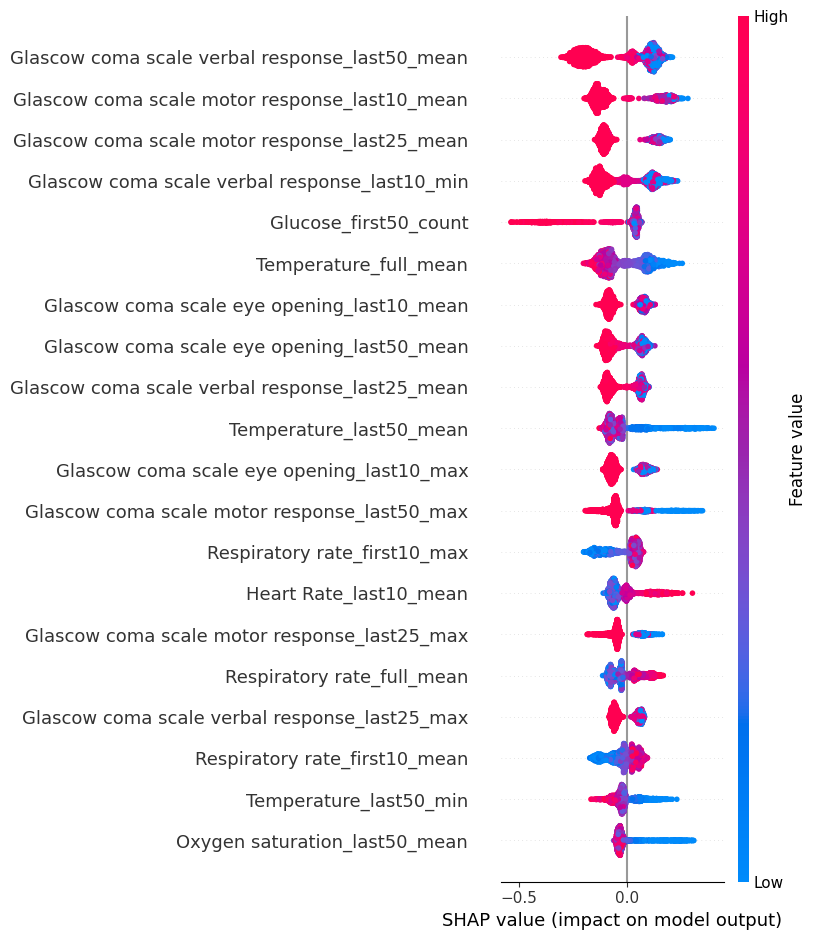

In [40]:
# shap summary plot
shap.summary_plot(shap_values, X_test_imp, show=False)

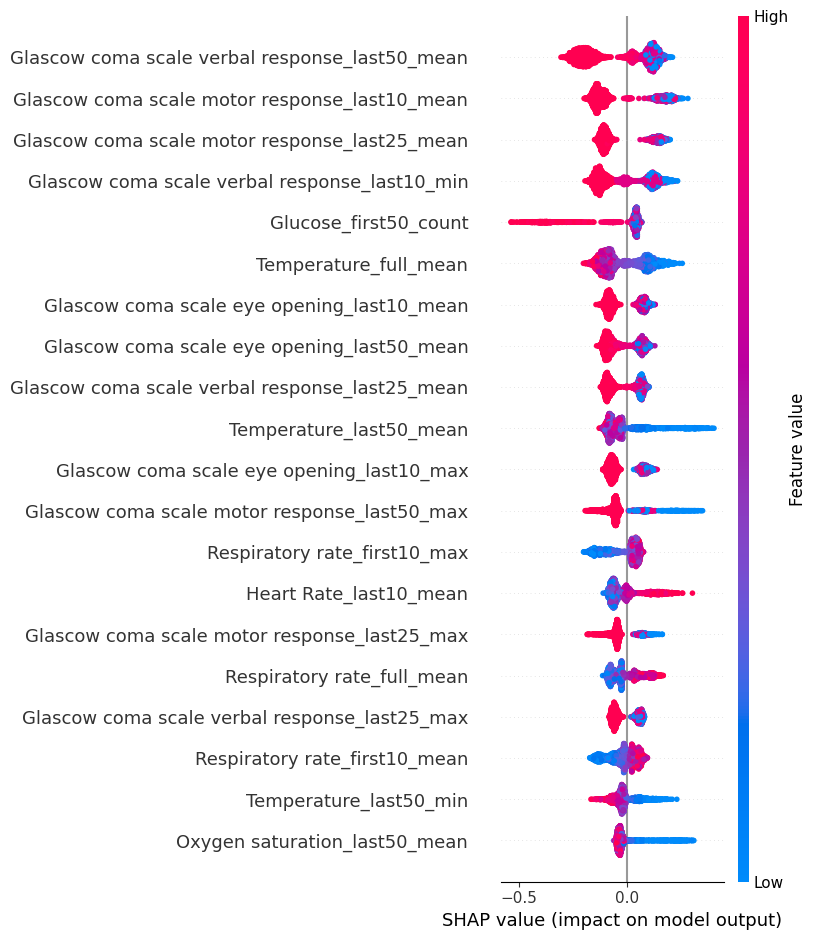

In [41]:
# save
import matplotlib.pyplot as plt

plt.figure()
shap.summary_plot(shap_values, X_test_imp, show=False)
plt.savefig("/content/drive/MyDrive/MIMIC_ensemble/shap_summary_full_48h.png", bbox_inches="tight")
plt.show()

In [42]:
#get top features
# Mean absolute SHAP value per feature
feature_importance = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X_test_imp.columns,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)

importance_df.head(20)

,feature,importance
322,Glascow coma scale verbal response_last50_mean,0.148859
238,Glascow coma scale motor response_last10_mean,0.139465
231,Glascow coma scale motor response_last25_mean,0.113771
338,Glascow coma scale verbal response_last10_min,0.113173
369,Glucose_first50_count,0.099981
679,Temperature_full_mean,0.097055
189,Glascow coma scale eye opening_last10_mean,0.079551
175,Glascow coma scale eye opening_last50_mean,0.077907
329,Glascow coma scale verbal response_last25_mean,0.074921
707,Temperature_last50_mean,0.074634


In [43]:
#save feature importance
importance_df.to_csv(
    "/content/drive/MyDrive/MIMIC_ensemble/shap_feature_importance_full_48h.csv",
    index=False
)

In [44]:
#map engineered features to original variables
def extract_base_feature(col):
    return col.split("_")[0]

importance_df["base_feature"] = importance_df["feature"].apply(extract_base_feature)

grouped_importance = (
    importance_df.groupby("base_feature")["importance"]
    .sum()
    .reset_index()
    .sort_values(by="importance", ascending=False)
)

grouped_importance.head(20)

,base_feature,importance
4,Glascow coma scale motor response,0.560094
14,Temperature,0.486464
6,Glascow coma scale verbal response,0.479493
12,Respiratory rate,0.469488
3,Glascow coma scale eye opening,0.402948
7,Glucose,0.393494
1,Diastolic blood pressure,0.323130
8,Heart Rate,0.282801
16,pH,0.236297
13,Systolic blood pressure,0.230705


In [45]:
# save grouped features
grouped_importance.to_csv(
    "/content/drive/MyDrive/MIMIC_ensemble/shap_grouped_importance_17_features.csv",
    index=False
)

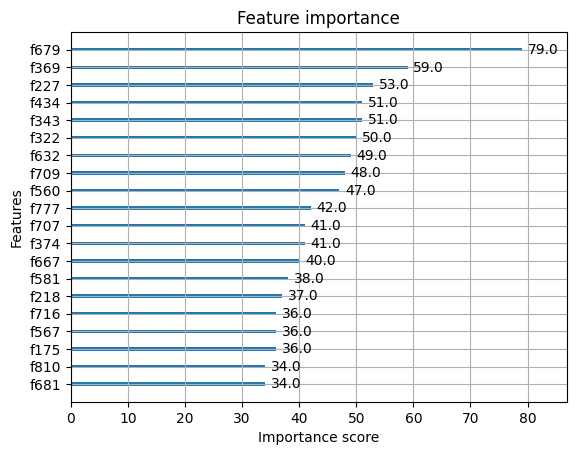

In [46]:
#XGBoost Built-in feature importance
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=20)
plt.savefig("/content/drive/MyDrive/MIMIC_ensemble/xgb_importance.png")
plt.show()

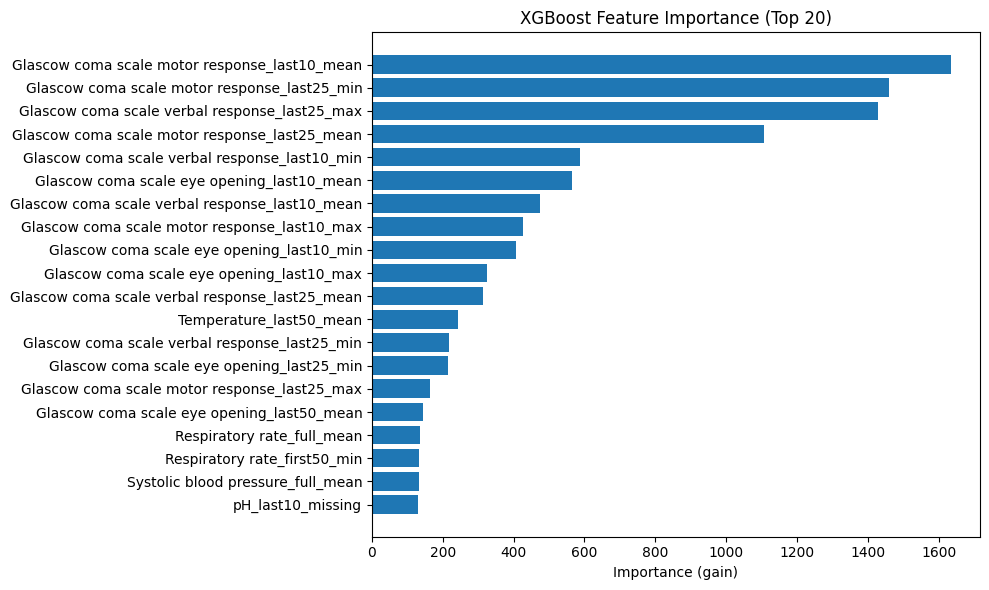

In [49]:
#column name mapping to the index name
import matplotlib.pyplot as plt

# Get importance scores
importance_dict = model.get_booster().get_score(importance_type="gain")

# Map fXXX → real feature names
feature_map = {f"f{i}": col for i, col in enumerate(kept_cols)}

# Convert to readable DataFrame
importance_df = pd.DataFrame({
    "feature": [feature_map.get(k, k) for k in importance_dict.keys()],
    "importance": importance_dict.values()
}).sort_values(by="importance", ascending=False)

# Plot top 20
top_n = 20
plt.figure(figsize=(10,6))
plt.barh(
    importance_df["feature"].head(top_n)[::-1],
    importance_df["importance"].head(top_n)[::-1]
)
plt.xlabel("Importance (gain)")
plt.title("XGBoost Feature Importance (Top 20)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MIMIC_ensemble/xgb_inbuilt_importance.png")
plt.show()

In [52]:
#remap to column names
importance_df["base_feature"] = importance_df["feature"].apply(lambda x: x.split("_")[0])

grouped_importance = (
    importance_df.groupby("base_feature")["importance"]
    .sum()
    .reset_index()
    .sort_values(by="importance", ascending=False)
)
grouped_importance.head(20)

,base_feature,importance
4,Glascow coma scale motor response,6069.417395
6,Glascow coma scale verbal response,4016.286991
3,Glascow coma scale eye opening,3079.802040
12,Respiratory rate,2061.713146
16,pH,1874.276071
1,Diastolic blood pressure,1848.038271
14,Temperature,1791.679674
13,Systolic blood pressure,1772.395617
8,Heart Rate,1688.229136
7,Glucose,1559.741426


EXPERIMENT 4 - TIME WINDOW- LAST 12 HR AND LAST 24 HRS WITHIN 48 HR WINDOW

In [2]:
import os
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb
from xgboost.callback import EarlyStopping

# ============================================================
# Config
# ============================================================
DATA_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
LISTFILE_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment4/xgb/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Experiment 4 window selector
# Change this one line per run
# ------------------------------------------------------------
EXP4_WINDOW = "last12h"   # options: "last12h", "last24h"

WINDOW_SUFFIX = {
    "last12h": "_last25_",
    "last24h": "_last50_",
}

if EXP4_WINDOW not in WINDOW_SUFFIX:
    raise ValueError("EXP4_WINDOW must be one of: ['last12h', 'last24h']")

SELECT_SUFFIX = WINDOW_SUFFIX[EXP4_WINDOW]
print(f"Running XGBoost Experiment 4 window: {EXP4_WINDOW}")
print(f"Selecting engineered features with suffix pattern: {SELECT_SUFFIX}")

# ============================================================
# Load full feature tables
# ============================================================
train_df = pd.read_csv(DATA_PATH + "train_features.csv")
val_df   = pd.read_csv(DATA_PATH + "val_features.csv")
test_df  = pd.read_csv(DATA_PATH + "test_features.csv")

print("Full train shape:", train_df.shape)
print("Full val shape  :", val_df.shape)
print("Full test shape :", test_df.shape)

# ============================================================
# Select only the engineered columns for the desired time window
# ============================================================
selected_cols = [
    col for col in train_df.columns
    if col != "label" and SELECT_SUFFIX in col
]

print(f"\nSelected {len(selected_cols)} columns for {EXP4_WINDOW}")
print("First 10 selected columns:", selected_cols[:10])

# ============================================================
# Build X / y
# ============================================================
X_train = train_df[selected_cols]
y_train = train_df["label"]

X_val = val_df[selected_cols]
y_val = val_df["label"]

X_test = test_df[selected_cols]
y_test = test_df["label"]

print("\nWindow-specific train shape:", X_train.shape)
print("Window-specific val shape  :", X_val.shape)
print("Window-specific test shape :", X_test.shape)

# ============================================================
# Mean imputation
# ============================================================
imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

# ============================================================
# Best XGBoost config from Experiment 1
# ============================================================
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6.39,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="aucpr",
    tree_method="hist",
    callbacks=[EarlyStopping(rounds=50, save_best=True)],
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# ============================================================
# Predict probabilities
# ============================================================
val_probs = model.predict_proba(X_val)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

# ============================================================
# Evaluate
# ============================================================
val_roc = roc_auc_score(y_val, val_probs)
val_pr = average_precision_score(y_val, val_probs)

test_roc = roc_auc_score(y_test, test_probs)
test_pr = average_precision_score(y_test, test_probs)

print("\nFINAL RESULTS")
print(f"VAL ROC-AUC : {val_roc:.4f}")
print(f"VAL PR-AUC  : {val_pr:.4f}")
print(f"TEST ROC-AUC: {test_roc:.4f}")
print(f"TEST PR-AUC : {test_pr:.4f}")
print("Best iteration:", getattr(model, "best_iteration", None))

# ============================================================
# Attach stay IDs using listfiles
# ============================================================
val_listfile = pd.read_csv(LISTFILE_PATH + "val_listfile.csv")
test_listfile = pd.read_csv(LISTFILE_PATH + "test_listfile.csv")

val_listfile.columns = ["stay", "y_true"]
test_listfile.columns = ["stay", "y_true"]

assert len(val_listfile) == len(val_probs), "Mismatch in val rows and predictions"
assert len(test_listfile) == len(test_probs), "Mismatch in test rows and predictions"

val_pred_df = val_listfile.copy()
val_pred_df["xgb_prob"] = val_probs

test_pred_df = test_listfile.copy()
test_pred_df["xgb_prob"] = test_probs

# ============================================================
# Save outputs
# ============================================================
model_path = os.path.join(SAVE_DIR, f"xgb_model_exp4_{EXP4_WINDOW}.json")
val_path = os.path.join(SAVE_DIR, f"xgb_val_predictions_exp4_{EXP4_WINDOW}.csv")
test_path = os.path.join(SAVE_DIR, f"xgb_test_predictions_exp4_{EXP4_WINDOW}.csv")
cols_path = os.path.join(SAVE_DIR, f"xgb_selected_columns_exp4_{EXP4_WINDOW}.txt")

model.save_model(model_path)
val_pred_df.to_csv(val_path, index=False)
test_pred_df.to_csv(test_path, index=False)

with open(cols_path, "w") as f:
    for c in selected_cols:
        f.write(c + "\n")

print("\nSaved model to:", model_path)
print("Saved val predictions to:", val_path)
print("Saved test predictions to:", test_path)
print("Saved selected column list to:", cols_path)

Running XGBoost Experiment 4 window: last12h
Selecting engineered features with suffix pattern: _last25_
Full train shape: (14681, 834)
Full val shape  : (3222, 834)
Full test shape : (3236, 834)

Selected 119 columns for last12h
First 10 selected columns: ['Capillary refill rate_last25_mean', 'Capillary refill rate_last25_std', 'Capillary refill rate_last25_min', 'Capillary refill rate_last25_max', 'Capillary refill rate_last25_skew', 'Capillary refill rate_last25_count', 'Capillary refill rate_last25_missing', 'Diastolic blood pressure_last25_mean', 'Diastolic blood pressure_last25_std', 'Diastolic blood pressure_last25_min']

Window-specific train shape: (14681, 119)
Window-specific val shape  : (3222, 119)
Window-specific test shape : (3236, 119)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_last25_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_last25_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_last25_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


[0]	validation_0-aucpr:0.33772
[50]	validation_0-aucpr:0.47010
[100]	validation_0-aucpr:0.48451
[150]	validation_0-aucpr:0.49410
[200]	validation_0-aucpr:0.49881
[250]	validation_0-aucpr:0.50366
[300]	validation_0-aucpr:0.50816
[350]	validation_0-aucpr:0.51009
[400]	validation_0-aucpr:0.51344
[450]	validation_0-aucpr:0.51327
[477]	validation_0-aucpr:0.51401

FINAL RESULTS
VAL ROC-AUC : 0.8522
VAL PR-AUC  : 0.5151
TEST ROC-AUC: 0.8528
TEST PR-AUC : 0.4867
Best iteration: 428

Saved model to: /content/drive/MyDrive/MIMIC_ensemble/experiment4/xgb/xgb_model_exp4_last12h.json
Saved val predictions to: /content/drive/MyDrive/MIMIC_ensemble/experiment4/xgb/xgb_val_predictions_exp4_last12h.csv
Saved test predictions to: /content/drive/MyDrive/MIMIC_ensemble/experiment4/xgb/xgb_test_predictions_exp4_last12h.csv
Saved selected column list to: /content/drive/MyDrive/MIMIC_ensemble/experiment4/xgb/xgb_selected_columns_exp4_last12h.txt


In [3]:
#XGBOOST for last 24 hr
import os
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb
from xgboost.callback import EarlyStopping

# ============================================================
# Config
# ============================================================
DATA_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
LISTFILE_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment4/xgb/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Experiment 4 window selector
# Change this one line per run
# ------------------------------------------------------------
EXP4_WINDOW = "last24h"   # options: "last12h", "last24h"

WINDOW_SUFFIX = {
    "last12h": "_last25_",
    "last24h": "_last50_",
}

if EXP4_WINDOW not in WINDOW_SUFFIX:
    raise ValueError("EXP4_WINDOW must be one of: ['last12h', 'last24h']")

SELECT_SUFFIX = WINDOW_SUFFIX[EXP4_WINDOW]
print(f"Running XGBoost Experiment 4 window: {EXP4_WINDOW}")
print(f"Selecting engineered features with suffix pattern: {SELECT_SUFFIX}")

# ============================================================
# Load full feature tables
# ============================================================
train_df = pd.read_csv(DATA_PATH + "train_features.csv")
val_df   = pd.read_csv(DATA_PATH + "val_features.csv")
test_df  = pd.read_csv(DATA_PATH + "test_features.csv")

print("Full train shape:", train_df.shape)
print("Full val shape  :", val_df.shape)
print("Full test shape :", test_df.shape)

# ============================================================
# Select only the engineered columns for the desired time window
# ============================================================
selected_cols = [
    col for col in train_df.columns
    if col != "label" and SELECT_SUFFIX in col
]

print(f"\nSelected {len(selected_cols)} columns for {EXP4_WINDOW}")
print("First 10 selected columns:", selected_cols[:10])

# ============================================================
# Build X / y
# ============================================================
X_train = train_df[selected_cols]
y_train = train_df["label"]

X_val = val_df[selected_cols]
y_val = val_df["label"]

X_test = test_df[selected_cols]
y_test = test_df["label"]

print("\nWindow-specific train shape:", X_train.shape)
print("Window-specific val shape  :", X_val.shape)
print("Window-specific test shape :", X_test.shape)

# ============================================================
# Mean imputation
# ============================================================
imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

# ============================================================
# Best XGBoost config from Experiment 1
# ============================================================
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6.39,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="aucpr",
    tree_method="hist",
    callbacks=[EarlyStopping(rounds=50, save_best=True)],
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# ============================================================
# Predict probabilities
# ============================================================
val_probs = model.predict_proba(X_val)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

# ============================================================
# Evaluate
# ============================================================
val_roc = roc_auc_score(y_val, val_probs)
val_pr = average_precision_score(y_val, val_probs)

test_roc = roc_auc_score(y_test, test_probs)
test_pr = average_precision_score(y_test, test_probs)

print("\nFINAL RESULTS")
print(f"VAL ROC-AUC : {val_roc:.4f}")
print(f"VAL PR-AUC  : {val_pr:.4f}")
print(f"TEST ROC-AUC: {test_roc:.4f}")
print(f"TEST PR-AUC : {test_pr:.4f}")
print("Best iteration:", getattr(model, "best_iteration", None))

# ============================================================
# Attach stay IDs using listfiles
# ============================================================
val_listfile = pd.read_csv(LISTFILE_PATH + "val_listfile.csv")
test_listfile = pd.read_csv(LISTFILE_PATH + "test_listfile.csv")

val_listfile.columns = ["stay", "y_true"]
test_listfile.columns = ["stay", "y_true"]

assert len(val_listfile) == len(val_probs), "Mismatch in val rows and predictions"
assert len(test_listfile) == len(test_probs), "Mismatch in test rows and predictions"

val_pred_df = val_listfile.copy()
val_pred_df["xgb_prob"] = val_probs

test_pred_df = test_listfile.copy()
test_pred_df["xgb_prob"] = test_probs

# ============================================================
# Save outputs
# ============================================================
model_path = os.path.join(SAVE_DIR, f"xgb_model_exp4_{EXP4_WINDOW}.json")
val_path = os.path.join(SAVE_DIR, f"xgb_val_predictions_exp4_{EXP4_WINDOW}.csv")
test_path = os.path.join(SAVE_DIR, f"xgb_test_predictions_exp4_{EXP4_WINDOW}.csv")
cols_path = os.path.join(SAVE_DIR, f"xgb_selected_columns_exp4_{EXP4_WINDOW}.txt")

model.save_model(model_path)
val_pred_df.to_csv(val_path, index=False)
test_pred_df.to_csv(test_path, index=False)

with open(cols_path, "w") as f:
    for c in selected_cols:
        f.write(c + "\n")

print("\nSaved model to:", model_path)
print("Saved val predictions to:", val_path)
print("Saved test predictions to:", test_path)
print("Saved selected column list to:", cols_path)

Running XGBoost Experiment 4 window: last24h
Selecting engineered features with suffix pattern: _last50_
Full train shape: (14681, 834)
Full val shape  : (3222, 834)
Full test shape : (3236, 834)

Selected 119 columns for last24h
First 10 selected columns: ['Capillary refill rate_last50_mean', 'Capillary refill rate_last50_std', 'Capillary refill rate_last50_min', 'Capillary refill rate_last50_max', 'Capillary refill rate_last50_skew', 'Capillary refill rate_last50_count', 'Capillary refill rate_last50_missing', 'Diastolic blood pressure_last50_mean', 'Diastolic blood pressure_last50_std', 'Diastolic blood pressure_last50_min']

Window-specific train shape: (14681, 119)
Window-specific val shape  : (3222, 119)
Window-specific test shape : (3236, 119)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_last50_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_last50_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_last50_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


[0]	validation_0-aucpr:0.40599
[50]	validation_0-aucpr:0.47543
[100]	validation_0-aucpr:0.50081
[150]	validation_0-aucpr:0.50950
[200]	validation_0-aucpr:0.51789
[250]	validation_0-aucpr:0.52524
[300]	validation_0-aucpr:0.53032
[350]	validation_0-aucpr:0.53232
[400]	validation_0-aucpr:0.53406
[450]	validation_0-aucpr:0.53291
[454]	validation_0-aucpr:0.53318

FINAL RESULTS
VAL ROC-AUC : 0.8552
VAL PR-AUC  : 0.5358
TEST ROC-AUC: 0.8516
TEST PR-AUC : 0.4867
Best iteration: 405

Saved model to: /content/drive/MyDrive/MIMIC_ensemble/experiment4/xgb/xgb_model_exp4_last24h.json
Saved val predictions to: /content/drive/MyDrive/MIMIC_ensemble/experiment4/xgb/xgb_val_predictions_exp4_last24h.csv
Saved test predictions to: /content/drive/MyDrive/MIMIC_ensemble/experiment4/xgb/xgb_test_predictions_exp4_last24h.csv
Saved selected column list to: /content/drive/MyDrive/MIMIC_ensemble/experiment4/xgb/xgb_selected_columns_exp4_last24h.txt


EXPERIMENT 4- TIME WINDOW- ENSEMBLE MODEL

In [4]:
#LAST 12 HRS
import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# ============================================================
# Config
# ============================================================
EXP4_WINDOW = "last12h"   # options: "last12h", "last24h"

GRUD_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment4/grud/"
XGB_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment4/xgb/"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment4/ensemble/"

os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Running ensemble for Experiment 4 window: {EXP4_WINDOW}")

# ============================================================
# Load prediction files
# ============================================================
grud_val = pd.read_csv(f"{GRUD_DIR}/grud_val_predictions_exp4_{EXP4_WINDOW}.csv")
grud_test = pd.read_csv(f"{GRUD_DIR}/grud_test_predictions_exp4_{EXP4_WINDOW}.csv")

xgb_val = pd.read_csv(f"{XGB_DIR}/xgb_val_predictions_exp4_{EXP4_WINDOW}.csv")
xgb_test = pd.read_csv(f"{XGB_DIR}/xgb_test_predictions_exp4_{EXP4_WINDOW}.csv")

print("GRU-D val shape :", grud_val.shape)
print("GRU-D test shape:", grud_test.shape)
print("XGB val shape   :", xgb_val.shape)
print("XGB test shape  :", xgb_test.shape)

# ============================================================
# Optional stay normalization for safe merge
# Uncomment if needed
# ============================================================
# grud_val["stay"] = grud_val["stay"].str.replace(".csv", "", regex=False)
# grud_test["stay"] = grud_test["stay"].str.replace(".csv", "", regex=False)
# xgb_val["stay"] = xgb_val["stay"].str.replace(".csv", "", regex=False)
# xgb_test["stay"] = xgb_test["stay"].str.replace(".csv", "", regex=False)

# ============================================================
# Merge on stay and y_true
# ============================================================
val_df = grud_val.merge(xgb_val, on=["stay", "y_true"], how="inner")
test_df = grud_test.merge(xgb_test, on=["stay", "y_true"], how="inner")

print("\nMerged val shape :", val_df.shape)
print("Merged test shape:", test_df.shape)

assert len(val_df) == len(grud_val) == len(xgb_val), "Validation merge mismatch"
assert len(test_df) == len(grud_test) == len(xgb_test), "Test merge mismatch"

print("\nMerged val preview:")
print(val_df.head())

# ============================================================
# Weighted-average search
# grud_weight = w
# xgb_weight = 1 - w
# ============================================================
weights = np.arange(0.0, 1.01, 0.05)
results = []

for w in weights:
    val_pred = w * val_df["grud_prob"] + (1 - w) * val_df["xgb_prob"]
    test_pred = w * test_df["grud_prob"] + (1 - w) * test_df["xgb_prob"]

    val_roc = roc_auc_score(val_df["y_true"], val_pred)
    val_pr = average_precision_score(val_df["y_true"], val_pred)

    test_roc = roc_auc_score(test_df["y_true"], test_pred)
    test_pr = average_precision_score(test_df["y_true"], test_pred)

    results.append({
        "window": EXP4_WINDOW,
        "grud_weight": round(float(w), 2),
        "xgb_weight": round(float(1 - w), 2),
        "val_roc": val_roc,
        "val_pr": val_pr,
        "test_roc": test_roc,
        "test_pr": test_pr,
    })

results_df = pd.DataFrame(results).sort_values(["val_pr", "val_roc"], ascending=False)

print("\nTop 10 ensemble weight combinations:")
print(results_df.head(10))

best_row = results_df.iloc[0]
print("\nBest ensemble by validation PR-AUC:")
print(best_row)

# ============================================================
# Save best ensemble predictions
# ============================================================
best_w = best_row["grud_weight"]

val_df["ensemble_prob"] = best_w * val_df["grud_prob"] + (1 - best_w) * val_df["xgb_prob"]
test_df["ensemble_prob"] = best_w * test_df["grud_prob"] + (1 - best_w) * test_df["xgb_prob"]

val_out = val_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].copy()
test_out = test_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].copy()

val_path = f"{SAVE_DIR}/ensemble_val_predictions_exp4_{EXP4_WINDOW}.csv"
test_path = f"{SAVE_DIR}/ensemble_test_predictions_exp4_{EXP4_WINDOW}.csv"
weights_path = f"{SAVE_DIR}/ensemble_weights_exp4_{EXP4_WINDOW}.csv"
search_path = f"{SAVE_DIR}/ensemble_weight_search_exp4_{EXP4_WINDOW}.csv"

val_out.to_csv(val_path, index=False)
test_out.to_csv(test_path, index=False)
pd.DataFrame([best_row]).to_csv(weights_path, index=False)
results_df.to_csv(search_path, index=False)

print("\nSaved ensemble val predictions to:", val_path)
print("Saved ensemble test predictions to:", test_path)
print("Saved best ensemble weights to:", weights_path)
print("Saved full weight search table to:", search_path)

Running ensemble for Experiment 4 window: last12h
GRU-D val shape : (3222, 3)
GRU-D test shape: (3236, 3)
XGB val shape   : (3222, 3)
XGB test shape  : (3236, 3)

Merged val shape : (3222, 4)
Merged test shape: (3236, 4)

Merged val preview:
                            stay  y_true  grud_prob  xgb_prob
0  25802_episode1_timeseries.csv     0.0   0.657346  0.657805
1  16396_episode1_timeseries.csv     0.0   0.267395  0.254563
2  19541_episode1_timeseries.csv     0.0   0.089861  0.111727
3  17251_episode1_timeseries.csv     0.0   0.004252  0.061866
4   3214_episode1_timeseries.csv     0.0   0.152168  0.147865

Top 10 ensemble weight combinations:
     window  grud_weight  xgb_weight   val_roc    val_pr  test_roc   test_pr
17  last12h         0.85        0.15  0.861346  0.550723  0.850428  0.496196
16  last12h         0.80        0.20  0.861974  0.550624  0.851706  0.498867
18  last12h         0.90        0.10  0.860428  0.550586  0.848884  0.492289
15  last12h         0.75        0.25  0.

In [5]:
#LAST 24 HR
import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# ============================================================
# Config
# ============================================================
EXP4_WINDOW = "last24h"   # options: "last12h", "last24h"

GRUD_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment4/grud/"
XGB_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment4/xgb/"
SAVE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment4/ensemble/"

os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Running ensemble for Experiment 4 window: {EXP4_WINDOW}")

# ============================================================
# Load prediction files
# ============================================================
grud_val = pd.read_csv(f"{GRUD_DIR}/grud_val_predictions_exp4_{EXP4_WINDOW}.csv")
grud_test = pd.read_csv(f"{GRUD_DIR}/grud_test_predictions_exp4_{EXP4_WINDOW}.csv")

xgb_val = pd.read_csv(f"{XGB_DIR}/xgb_val_predictions_exp4_{EXP4_WINDOW}.csv")
xgb_test = pd.read_csv(f"{XGB_DIR}/xgb_test_predictions_exp4_{EXP4_WINDOW}.csv")

print("GRU-D val shape :", grud_val.shape)
print("GRU-D test shape:", grud_test.shape)
print("XGB val shape   :", xgb_val.shape)
print("XGB test shape  :", xgb_test.shape)

# ============================================================
# Optional stay normalization for safe merge
# Uncomment if needed
# ============================================================
# grud_val["stay"] = grud_val["stay"].str.replace(".csv", "", regex=False)
# grud_test["stay"] = grud_test["stay"].str.replace(".csv", "", regex=False)
# xgb_val["stay"] = xgb_val["stay"].str.replace(".csv", "", regex=False)
# xgb_test["stay"] = xgb_test["stay"].str.replace(".csv", "", regex=False)

# ============================================================
# Merge on stay and y_true
# ============================================================
val_df = grud_val.merge(xgb_val, on=["stay", "y_true"], how="inner")
test_df = grud_test.merge(xgb_test, on=["stay", "y_true"], how="inner")

print("\nMerged val shape :", val_df.shape)
print("Merged test shape:", test_df.shape)

assert len(val_df) == len(grud_val) == len(xgb_val), "Validation merge mismatch"
assert len(test_df) == len(grud_test) == len(xgb_test), "Test merge mismatch"

print("\nMerged val preview:")
print(val_df.head())

# ============================================================
# Weighted-average search
# grud_weight = w
# xgb_weight = 1 - w
# ============================================================
weights = np.arange(0.0, 1.01, 0.05)
results = []

for w in weights:
    val_pred = w * val_df["grud_prob"] + (1 - w) * val_df["xgb_prob"]
    test_pred = w * test_df["grud_prob"] + (1 - w) * test_df["xgb_prob"]

    val_roc = roc_auc_score(val_df["y_true"], val_pred)
    val_pr = average_precision_score(val_df["y_true"], val_pred)

    test_roc = roc_auc_score(test_df["y_true"], test_pred)
    test_pr = average_precision_score(test_df["y_true"], test_pred)

    results.append({
        "window": EXP4_WINDOW,
        "grud_weight": round(float(w), 2),
        "xgb_weight": round(float(1 - w), 2),
        "val_roc": val_roc,
        "val_pr": val_pr,
        "test_roc": test_roc,
        "test_pr": test_pr,
    })

results_df = pd.DataFrame(results).sort_values(["val_pr", "val_roc"], ascending=False)

print("\nTop 10 ensemble weight combinations:")
print(results_df.head(10))

best_row = results_df.iloc[0]
print("\nBest ensemble by validation PR-AUC:")
print(best_row)

# ============================================================
# Save best ensemble predictions
# ============================================================
best_w = best_row["grud_weight"]

val_df["ensemble_prob"] = best_w * val_df["grud_prob"] + (1 - best_w) * val_df["xgb_prob"]
test_df["ensemble_prob"] = best_w * test_df["grud_prob"] + (1 - best_w) * test_df["xgb_prob"]

val_out = val_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].copy()
test_out = test_df[["stay", "y_true", "grud_prob", "xgb_prob", "ensemble_prob"]].copy()

val_path = f"{SAVE_DIR}/ensemble_val_predictions_exp4_{EXP4_WINDOW}.csv"
test_path = f"{SAVE_DIR}/ensemble_test_predictions_exp4_{EXP4_WINDOW}.csv"
weights_path = f"{SAVE_DIR}/ensemble_weights_exp4_{EXP4_WINDOW}.csv"
search_path = f"{SAVE_DIR}/ensemble_weight_search_exp4_{EXP4_WINDOW}.csv"

val_out.to_csv(val_path, index=False)
test_out.to_csv(test_path, index=False)
pd.DataFrame([best_row]).to_csv(weights_path, index=False)
results_df.to_csv(search_path, index=False)

print("\nSaved ensemble val predictions to:", val_path)
print("Saved ensemble test predictions to:", test_path)
print("Saved best ensemble weights to:", weights_path)
print("Saved full weight search table to:", search_path)

Running ensemble for Experiment 4 window: last24h
GRU-D val shape : (3222, 3)
GRU-D test shape: (3236, 3)
XGB val shape   : (3222, 3)
XGB test shape  : (3236, 3)

Merged val shape : (3222, 4)
Merged test shape: (3236, 4)

Merged val preview:
                            stay  y_true  grud_prob  xgb_prob
0  25802_episode1_timeseries.csv     0.0   0.504839  0.394250
1  16396_episode1_timeseries.csv     0.0   0.080551  0.059201
2  19541_episode1_timeseries.csv     0.0   0.099861  0.065575
3  17251_episode1_timeseries.csv     0.0   0.035754  0.133959
4   3214_episode1_timeseries.csv     0.0   0.038505  0.056283

Top 10 ensemble weight combinations:
     window  grud_weight  xgb_weight   val_roc    val_pr  test_roc   test_pr
16  last24h         0.80        0.20  0.868241  0.579799  0.864445  0.522593
15  last24h         0.75        0.25  0.868672  0.579701  0.864702  0.522392
14  last24h         0.70        0.30  0.868920  0.579249  0.864876  0.522154
17  last24h         0.85        0.15  0.

EXPERIMENT 4- TIME WINDOW- compute full metrics

In [6]:
#get full metrics
import os
import pandas as pd
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
)

# ============================================================
# Paths
# ============================================================
BASE_DIR = "/content/drive/MyDrive/MIMIC_ensemble/experiment4"

LSTM_DIR = f"{BASE_DIR}/lstm"
GRUD_DIR = f"{BASE_DIR}/grud"
XGB_DIR = f"{BASE_DIR}/xgb"
ENSEMBLE_DIR = f"{BASE_DIR}/ensemble"

# ============================================================
# Windows
# ============================================================
WINDOWS = {
    "last12h": "Last 12h",
    "last24h": "Last 24h",
}

# ============================================================
# Metrics function
# ============================================================
def compute_all_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        output_dict=True,
        zero_division=0
    )

    return {
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),

        "precision_class_0": report["0"]["precision"],
        "recall_class_0": report["0"]["recall"],
        "f1_class_0": report["0"]["f1-score"],

        "precision_class_1": report["1"]["precision"],
        "recall_class_1": report["1"]["recall"],
        "f1_class_1": report["1"]["f1-score"],
    }

# ============================================================
# Build results
# ============================================================
results = []

def add_row(window_label, model_name, metrics):
    return {
        "Experiment": "Exp 4",
        "Subset": window_label,
        "Model": model_name,
        **metrics
    }

# ============================================================
# Loop over windows
# ============================================================
for window_key, window_label in WINDOWS.items():
    print(f"\nProcessing window: {window_key}")

    # -------------------------
    # File paths
    # -------------------------
    lstm_path = f"{LSTM_DIR}/lstm_test_predictions_exp4_{window_key}.csv"
    grud_path = f"{GRUD_DIR}/grud_test_predictions_exp4_{window_key}.csv"
    xgb_path = f"{XGB_DIR}/xgb_test_predictions_exp4_{window_key}.csv"
    ensemble_path = f"{ENSEMBLE_DIR}/ensemble_test_predictions_exp4_{window_key}.csv"

    # -------------------------
    # Load
    # -------------------------
    lstm_df = pd.read_csv(lstm_path)
    grud_df = pd.read_csv(grud_path)
    xgb_df = pd.read_csv(xgb_path)
    ensemble_df = pd.read_csv(ensemble_path)

    print("Loaded files:")
    print("LSTM:", lstm_df.shape)
    print("GRU-D:", grud_df.shape)
    print("XGB:", xgb_df.shape)
    print("Ensemble:", ensemble_df.shape)

    # -------------------------
    # Compute metrics
    # -------------------------
    lstm_metrics = compute_all_metrics(lstm_df["y_true"], lstm_df["lstm_prob"])
    grud_metrics = compute_all_metrics(grud_df["y_true"], grud_df["grud_prob"])
    xgb_metrics = compute_all_metrics(xgb_df["y_true"], xgb_df["xgb_prob"])
    ensemble_metrics = compute_all_metrics(ensemble_df["y_true"], ensemble_df["ensemble_prob"])

    # -------------------------
    # Append
    # -------------------------
    results.append(add_row(window_label, "LSTM", lstm_metrics))
    results.append(add_row(window_label, "GRU-D", grud_metrics))
    results.append(add_row(window_label, "XGBoost", xgb_metrics))
    results.append(add_row(window_label, "Ensemble", ensemble_metrics))

# ============================================================
# Final dataframe
# ============================================================
exp4_results_df = pd.DataFrame(results)

# Round values
metric_cols = [c for c in exp4_results_df.columns if c not in ["Experiment", "Subset", "Model"]]
exp4_results_df[metric_cols] = exp4_results_df[metric_cols].round(4)

# Column order
final_cols = [
    "Experiment",
    "Subset",
    "Model",
    "auroc",
    "auprc",
    "accuracy",
    "balanced_accuracy",
    "precision_class_0",
    "recall_class_0",
    "f1_class_0",
    "precision_class_1",
    "recall_class_1",
    "f1_class_1",
]

exp4_results_df = exp4_results_df[final_cols]

print("\nExperiment 4 results table:")
print(exp4_results_df)

# ============================================================
# Save
# ============================================================
save_path = f"{BASE_DIR}/experiment4_metrics_table.csv"
exp4_results_df.to_csv(save_path, index=False)

print("\nSaved Experiment 4 metrics table to:", save_path)


Processing window: last12h
Loaded files:
LSTM: (3236, 3)
GRU-D: (3236, 3)
XGB: (3236, 3)
Ensemble: (3236, 5)

Processing window: last24h
Loaded files:
LSTM: (3236, 3)
GRU-D: (3236, 3)
XGB: (3236, 3)
Ensemble: (3236, 5)

Experiment 4 results table:
  Experiment    Subset     Model   auroc   auprc  accuracy  balanced_accuracy  \
0      Exp 4  Last 12h      LSTM  0.8392  0.4703    0.7608             0.7683   
1      Exp 4  Last 12h     GRU-D  0.8454  0.4830    0.7485             0.7706   
2      Exp 4  Last 12h   XGBoost  0.8528  0.4867    0.7911             0.7622   
3      Exp 4  Last 12h  Ensemble  0.8504  0.4962    0.7574             0.7745   
4      Exp 4  Last 24h      LSTM  0.8410  0.4753    0.7908             0.7574   
5      Exp 4  Last 24h     GRU-D  0.8616  0.5140    0.7834             0.7776   
6      Exp 4  Last 24h   XGBoost  0.8516  0.4867    0.7942             0.7535   
7      Exp 4  Last 24h  Ensemble  0.8644  0.5226    0.7908             0.7795   

   precision_class_0 

In [7]:
#combine the results to master table
import pandas as pd

# ============================================================
# Paths
# ============================================================
BASE_DIR = "/content/drive/MyDrive/MIMIC_ensemble"

exp12_path = f"{BASE_DIR}/master_results_table_exp1_exp2.csv"
exp4_path = f"{BASE_DIR}/experiment4/experiment4_metrics_table.csv"

# Output
combined_path = f"{BASE_DIR}/master_results_table_exp1_exp2_exp4.csv"

# ============================================================
# Load
# ============================================================
exp12_df = pd.read_csv(exp12_path)
exp4_df = pd.read_csv(exp4_path)

print("Exp1+2 shape:", exp12_df.shape)
print("Exp4 shape   :", exp4_df.shape)

print("\nExp1+2 columns:", exp12_df.columns.tolist())
print("Exp4 columns   :", exp4_df.columns.tolist())

# ============================================================
# Standardize columns if needed
# ============================================================
# Make sure model column is consistently named
if "model" in exp12_df.columns:
    exp12_df = exp12_df.rename(columns={"model": "Model"})
if "model" in exp4_df.columns:
    exp4_df = exp4_df.rename(columns={"model": "Model"})

# Ensure Experiment and Subset columns exist
if "Experiment" not in exp12_df.columns:
    raise ValueError("Exp1+2 table is missing 'Experiment' column")
if "Subset" not in exp12_df.columns:
    raise ValueError("Exp1+2 table is missing 'Subset' column")
if "Experiment" not in exp4_df.columns:
    raise ValueError("Exp4 table is missing 'Experiment' column")
if "Subset" not in exp4_df.columns:
    raise ValueError("Exp4 table is missing 'Subset' column")

# Final desired column order
final_cols = [
    "Experiment",
    "Subset",
    "Model",
    "auroc",
    "auprc",
    "accuracy",
    "balanced_accuracy",
    "precision_class_0",
    "recall_class_0",
    "f1_class_0",
    "precision_class_1",
    "recall_class_1",
    "f1_class_1",
]

# Keep only those columns in that order
exp12_df = exp12_df[final_cols]
exp4_df = exp4_df[final_cols]

# ============================================================
# Combine
# ============================================================
master_df = pd.concat([exp12_df, exp4_df], ignore_index=True)

# ============================================================
# Sort nicely
# ============================================================
experiment_order = {
    "Exp 1": 1,
    "Exp 2": 2,
    "Exp 4": 4,
}

subset_order = {
    "All Features": 0,
    "Hemodynamics": 1,
    "Respiratory/Acid-Base": 2,
    "Neurologic": 3,
    "Metabolic/General": 4,
    "Last 12h": 5,
    "Last 24h": 6,
}

model_order = {
    "LSTM": 1,
    "GRU-D": 2,
    "XGBoost": 3,
    "Ensemble": 4,
}

master_df["experiment_order"] = master_df["Experiment"].map(experiment_order)
master_df["subset_order"] = master_df["Subset"].map(subset_order)
master_df["model_order"] = master_df["Model"].map(model_order)

master_df = master_df.sort_values(
    by=["experiment_order", "subset_order", "model_order"]
).drop(columns=["experiment_order", "subset_order", "model_order"]).reset_index(drop=True)

# Round metrics
metric_cols = [c for c in master_df.columns if c not in ["Experiment", "Subset", "Model"]]
master_df[metric_cols] = master_df[metric_cols].round(4)

print("\nCombined master table:")
print(master_df)

# ============================================================
# Save
# ============================================================
master_df.to_csv(combined_path, index=False)
print("\nSaved combined master table to:", combined_path)

Exp1+2 shape: (20, 13)
Exp4 shape   : (8, 13)

Exp1+2 columns: ['Experiment', 'Subset', 'Model', 'auroc', 'auprc', 'accuracy', 'balanced_accuracy', 'precision_class_0', 'recall_class_0', 'f1_class_0', 'precision_class_1', 'recall_class_1', 'f1_class_1']
Exp4 columns   : ['Experiment', 'Subset', 'Model', 'auroc', 'auprc', 'accuracy', 'balanced_accuracy', 'precision_class_0', 'recall_class_0', 'f1_class_0', 'precision_class_1', 'recall_class_1', 'f1_class_1']

Combined master table:
   Experiment                 Subset     Model   auroc   auprc  accuracy  \
0       Exp 1           All Features      LSTM  0.8525  0.4999    0.7883   
1       Exp 1           All Features     GRU-D  0.8638  0.5208    0.7871   
2       Exp 1           All Features   XGBoost  0.8654  0.5235    0.8059   
3       Exp 1           All Features  Ensemble  0.8713  0.5363    0.7933   
4       Exp 2           Hemodynamics      LSTM  0.6641  0.2755    0.5430   
5       Exp 2           Hemodynamics     GRU-D  0.6968  0.

EXPERIMENT 5- CASE STUDIES - TP/FP/FN/TN

                            stay  y_true  grud_prob  xgb_prob  ensemble_prob
0  10011_episode1_timeseries.csv       1   0.926938  0.655036       0.845368
1  10026_episode1_timeseries.csv       0   0.402421  0.341314       0.384089
2  10030_episode1_timeseries.csv       0   0.048955  0.161774       0.082801
3  10042_episode1_timeseries.csv       0   0.011960  0.264180       0.087626
4  10094_episode1_timeseries.csv       0   0.654772  0.758516       0.685895
Index(['stay', 'y_true', 'grud_prob', 'xgb_prob', 'ensemble_prob'], dtype='object')


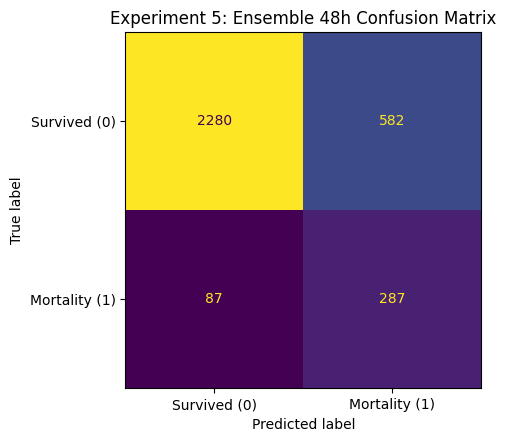

Saved confusion matrix to: /content/drive/MyDrive/MIMIC_ensemble/experiment5_confusion_matrix_ensemble_48h.png
Confusion matrix:
 [[2280  582]
 [  87  287]]


In [1]:
#LOAD ENSEMBLE PREDICTIONS AND CREATE CONFUSION MATRIX CATEGOREIS
import os
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Path to Experiment 1 / All Features ensemble predictions
# Update if your filename differs
# ------------------------------------------------------------
BASE_DIR = "/content/drive/MyDrive/MIMIC_ensemble"
ENSEMBLE_TEST_PATH = f"{BASE_DIR}/ensemble_test_predictions.csv"

df = pd.read_csv(ENSEMBLE_TEST_PATH)

print(df.head())
print(df.columns)

# Required columns expected:
# stay, y_true, grud_prob, xgb_prob, ensemble_prob

# ------------------------------------------------------------
# Threshold for binary prediction
# ------------------------------------------------------------
THRESHOLD = 0.5

df["y_true"] = df["y_true"].astype(int)
df["y_pred"] = (df["ensemble_prob"] >= THRESHOLD).astype(int)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------
cm = confusion_matrix(df["y_true"], df["y_pred"], labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survived (0)", "Mortality (1)"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, values_format="d", colorbar=False)
plt.title("Experiment 5: Ensemble 48h Confusion Matrix")
plt.tight_layout()

cm_path = f"{BASE_DIR}/experiment5_confusion_matrix_ensemble_48h.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix to:", cm_path)
print("Confusion matrix:\n", cm)

In [2]:
#EXTRACT TP/TN/FP/FN TABLES
tp = df[(df["y_true"] == 1) & (df["y_pred"] == 1)].copy()
tn = df[(df["y_true"] == 0) & (df["y_pred"] == 0)].copy()
fp = df[(df["y_true"] == 0) & (df["y_pred"] == 1)].copy()
fn = df[(df["y_true"] == 1) & (df["y_pred"] == 0)].copy()

print("TP:", tp.shape)
print("TN:", tn.shape)
print("FP:", fp.shape)
print("FN:", fn.shape)

TP: (287, 6)
TN: (2280, 6)
FP: (582, 6)
FN: (87, 6)


In [3]:
#PICK REPRESENTATIVE CASES
#This picks high-confidence examples:
#TP: highest predicted mortality among actual mortality
#TN: lowest predicted mortality among actual survival
#FP: highest predicted mortality among actual survival
#FN: lowest predicted mortality among actual mortality

# High-confidence representatives
tp_case = tp.sort_values("ensemble_prob", ascending=False).iloc[0]
tn_case = tn.sort_values("ensemble_prob", ascending=True).iloc[0]
fp_case = fp.sort_values("ensemble_prob", ascending=False).iloc[0]
fn_case = fn.sort_values("ensemble_prob", ascending=True).iloc[0]

selected_cases = pd.DataFrame([
    {"case_type": "TP", **tp_case.to_dict()},
    {"case_type": "TN", **tn_case.to_dict()},
    {"case_type": "FP", **fp_case.to_dict()},
    {"case_type": "FN", **fn_case.to_dict()},
])

selected_cases

,case_type,stay,y_true,grud_prob,xgb_prob,ensemble_prob,y_pred
0,TP,25556_episode1_timeseries.csv,1,0.998410,0.980120,0.992923,1
1,TN,4625_episode1_timeseries.csv,0,0.004251,0.012098,0.006605,0
2,FP,20794_episode2_timeseries.csv,0,0.976700,0.905189,0.955247,1
3,FN,62103_episode1_timeseries.csv,1,0.020185,0.099416,0.043954,0


In [4]:
#SAVE CASE REPRESENTATIVES
case_save_path = f"{BASE_DIR}/experiment5_selected_cases_ensemble_48h.csv"
selected_cases.to_csv(case_save_path, index=False)
print("Saved selected cases to:", case_save_path)

Saved selected cases to: /content/drive/MyDrive/MIMIC_ensemble/experiment5_selected_cases_ensemble_48h.csv


In [5]:
#OPTIONAL SAVE LARGER CANDIDATE POOL
top_tp = tp.sort_values("ensemble_prob", ascending=False).head(10).copy()
top_tn = tn.sort_values("ensemble_prob", ascending=True).head(10).copy()
top_fp = fp.sort_values("ensemble_prob", ascending=False).head(10).copy()
top_fn = fn.sort_values("ensemble_prob", ascending=True).head(10).copy()

top_tp["case_type"] = "TP"
top_tn["case_type"] = "TN"
top_fp["case_type"] = "FP"
top_fn["case_type"] = "FN"

candidate_pool = pd.concat([top_tp, top_tn, top_fp, top_fn], ignore_index=True)

candidate_pool_path = f"{BASE_DIR}/experiment5_candidate_case_pool_ensemble_48h.csv"
candidate_pool.to_csv(candidate_pool_path, index=False)

print("Saved candidate pool to:", candidate_pool_path)
candidate_pool.head()

Saved candidate pool to: /content/drive/MyDrive/MIMIC_ensemble/experiment5_candidate_case_pool_ensemble_48h.csv


,stay,y_true,grud_prob,xgb_prob,ensemble_prob,y_pred,case_type
0,25556_episode1_timeseries.csv,1,0.998410,0.980120,0.992923,1,TP
1,6898_episode1_timeseries.csv,1,0.992265,0.975714,0.987300,1,TP
2,25063_episode1_timeseries.csv,1,0.995643,0.956749,0.983975,1,TP
3,2570_episode1_timeseries.csv,1,0.990155,0.966723,0.983125,1,TP
4,931_episode1_timeseries.csv,1,0.985581,0.958245,0.977380,1,TP


EXPERIMENT 5 - CASE STUDY- UNDERSTANDING THE FEATURE CONTRIBUTION USING SHAP FOR EACH CASE TYPE- ON THE XGBOOST FULL-FEATURE MODEL RATHER THAN ENSEMBLE DIRECTLY
Case-level feature attribution was performed using the XGBoost component model.

X_train shape: (14681, 833)
X_test shape : (3236, 833)
test_listfile shape: (3236, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_full_skew' 'Height_first10_skew' 'Height_first25_skew'
 'Height_first50_skew' 'Height_last50_skew' 'Height_last25_skew'
 'Height_last10_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Height_full_skew' 'Height_first10_skew' 'Height_first25_skew'
 'Height_first50_skew' 'Height_last50_skew' 'Height_last25_skew'
 'Height_last10_skew']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Imputed X_test shape: (3236, 826)
Loaded model from: /content/drive/MyDrive/MIMIC_ensemble/xgb_model_exp1.json
SHAP values shape: (3236, 826)
  case_type                           stay  y_true  grud_prob  xgb_prob  \
0        TP  25556_episode1_timeseries.csv       1   0.998410  0.980120   
1        TN   4625_episode1_timeseries.csv       0   0.004251  0.012098   
2        FP  20794_episode2_timeseries.csv       0   0.976700  0.905189   
3        FN  62103_episode1_timeseries.csv       1   0.020185  0.099416   

   ensemble_prob  y_pred  
0       0.992923       1  
1       0.006605       0  
2       0.955247       1  
3       0.043954       0  
Selected cases shape: (4, 7)

Processing TP | 25556_episode1_timeseries.csv | idx=1167


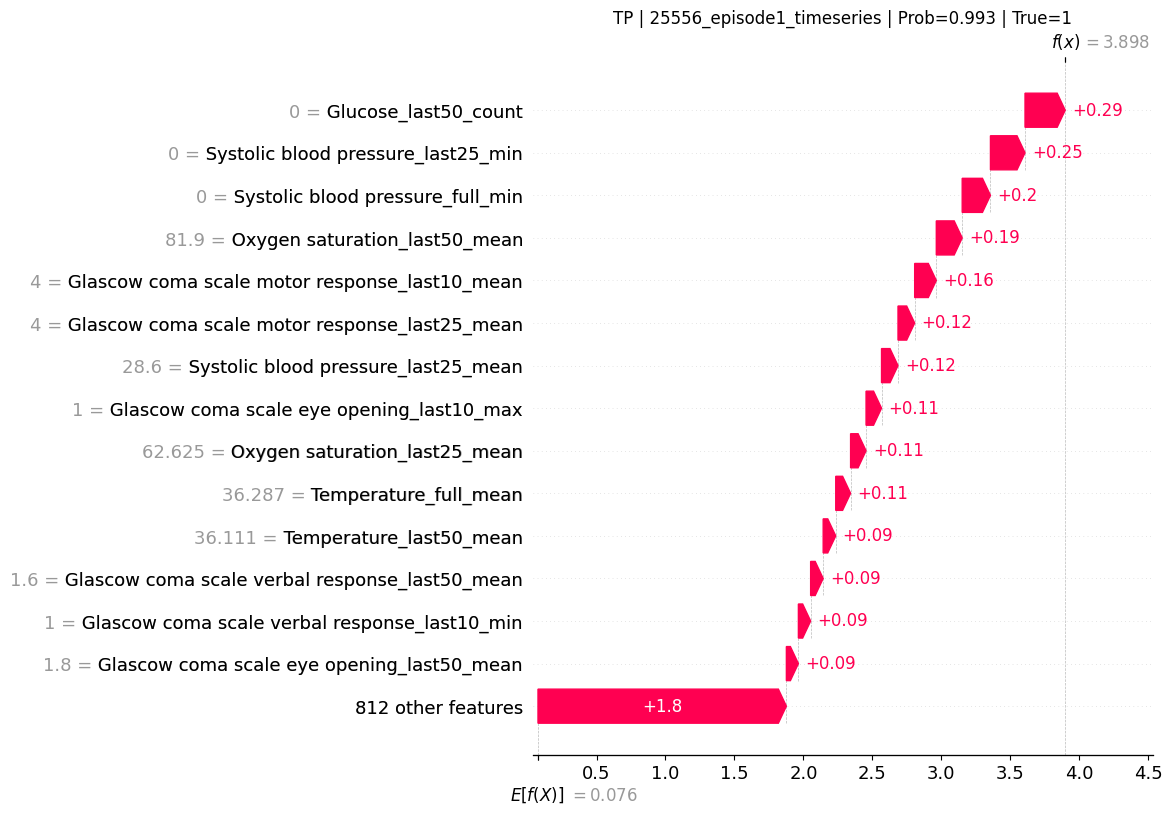

Saved waterfall plot to: /content/drive/MyDrive/MIMIC_ensemble/experiment5_shap_cases/shap_waterfall_TP_25556_episode1_timeseries.png


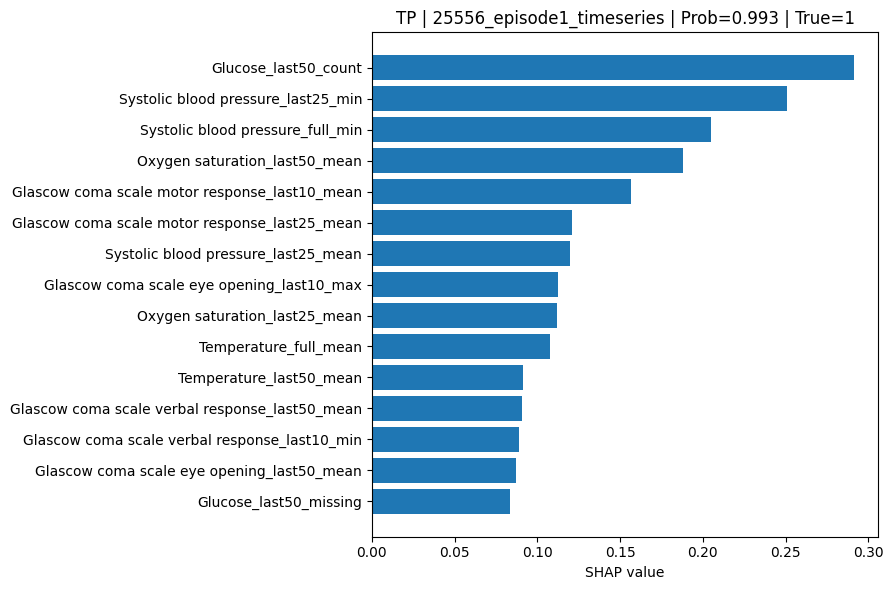

Saved SHAP bar plot to: /content/drive/MyDrive/MIMIC_ensemble/experiment5_shap_cases/shap_bar_TP_25556_episode1_timeseries.png

Processing TN | 4625_episode1_timeseries.csv | idx=1876


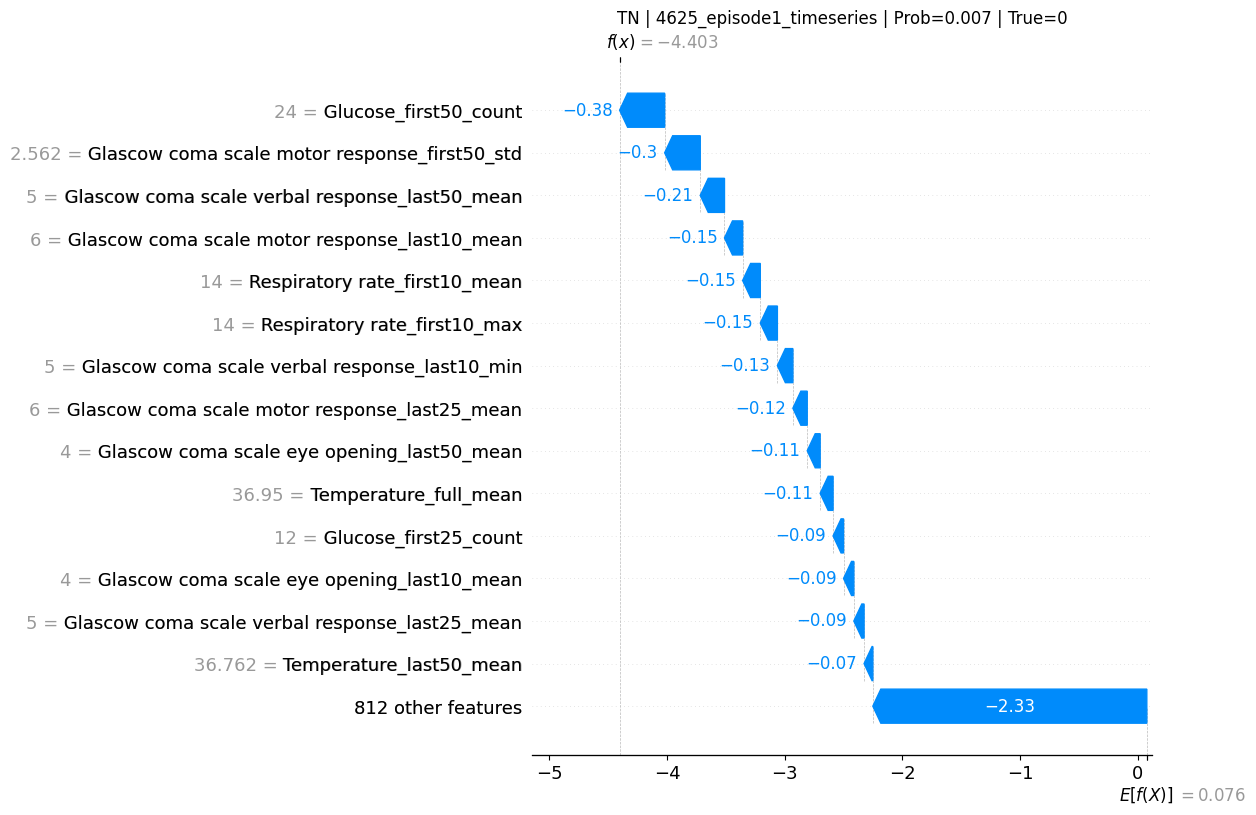

Saved waterfall plot to: /content/drive/MyDrive/MIMIC_ensemble/experiment5_shap_cases/shap_waterfall_TN_4625_episode1_timeseries.png


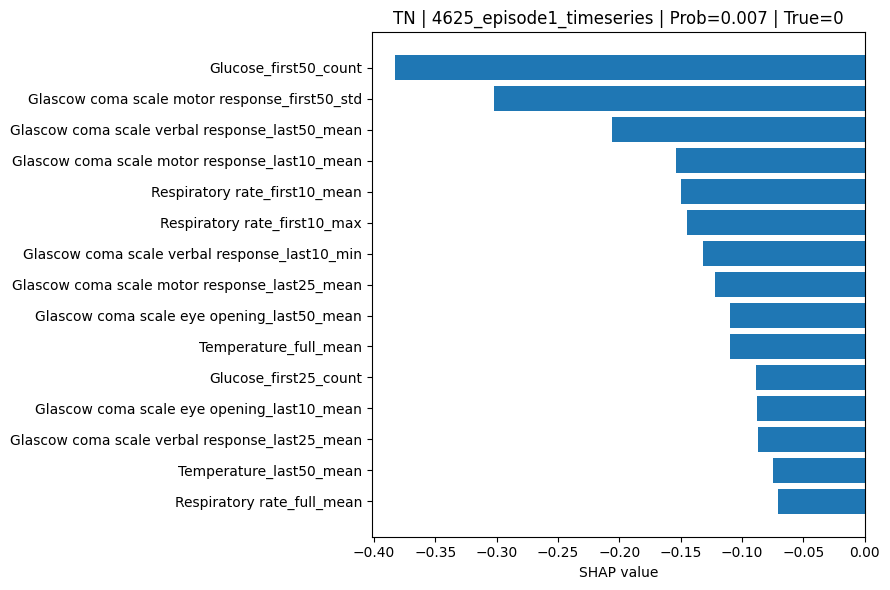

Saved SHAP bar plot to: /content/drive/MyDrive/MIMIC_ensemble/experiment5_shap_cases/shap_bar_TN_4625_episode1_timeseries.png

Processing FP | 20794_episode2_timeseries.csv | idx=784


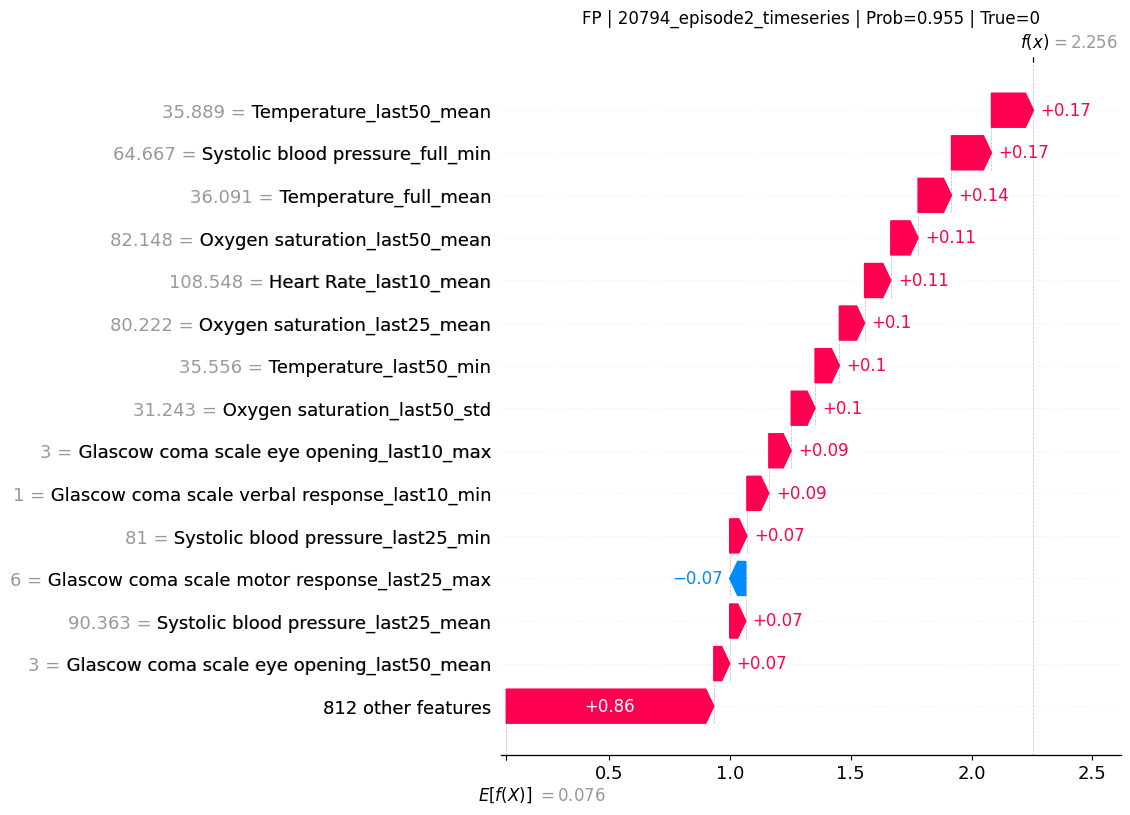

Saved waterfall plot to: /content/drive/MyDrive/MIMIC_ensemble/experiment5_shap_cases/shap_waterfall_FP_20794_episode2_timeseries.png


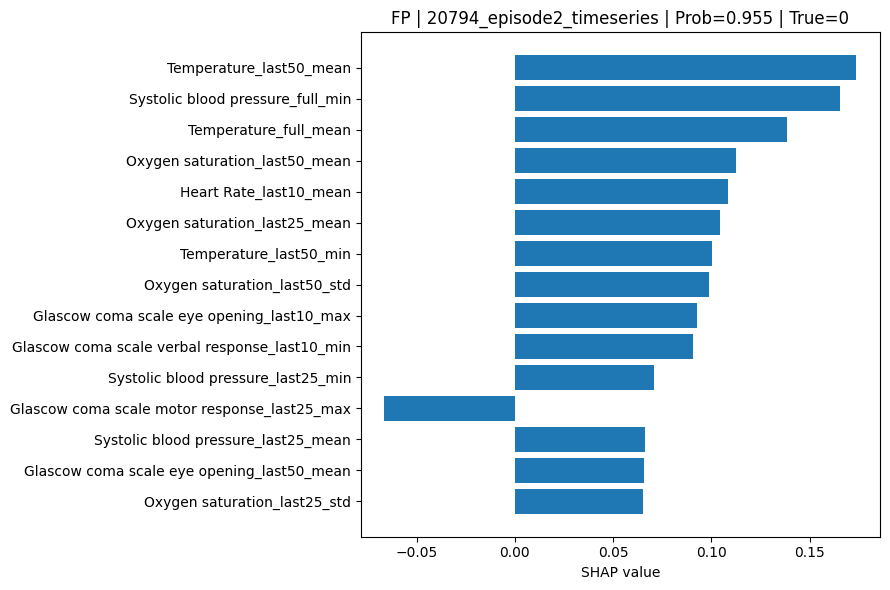

Saved SHAP bar plot to: /content/drive/MyDrive/MIMIC_ensemble/experiment5_shap_cases/shap_bar_FP_20794_episode2_timeseries.png

Processing FN | 62103_episode1_timeseries.csv | idx=2294


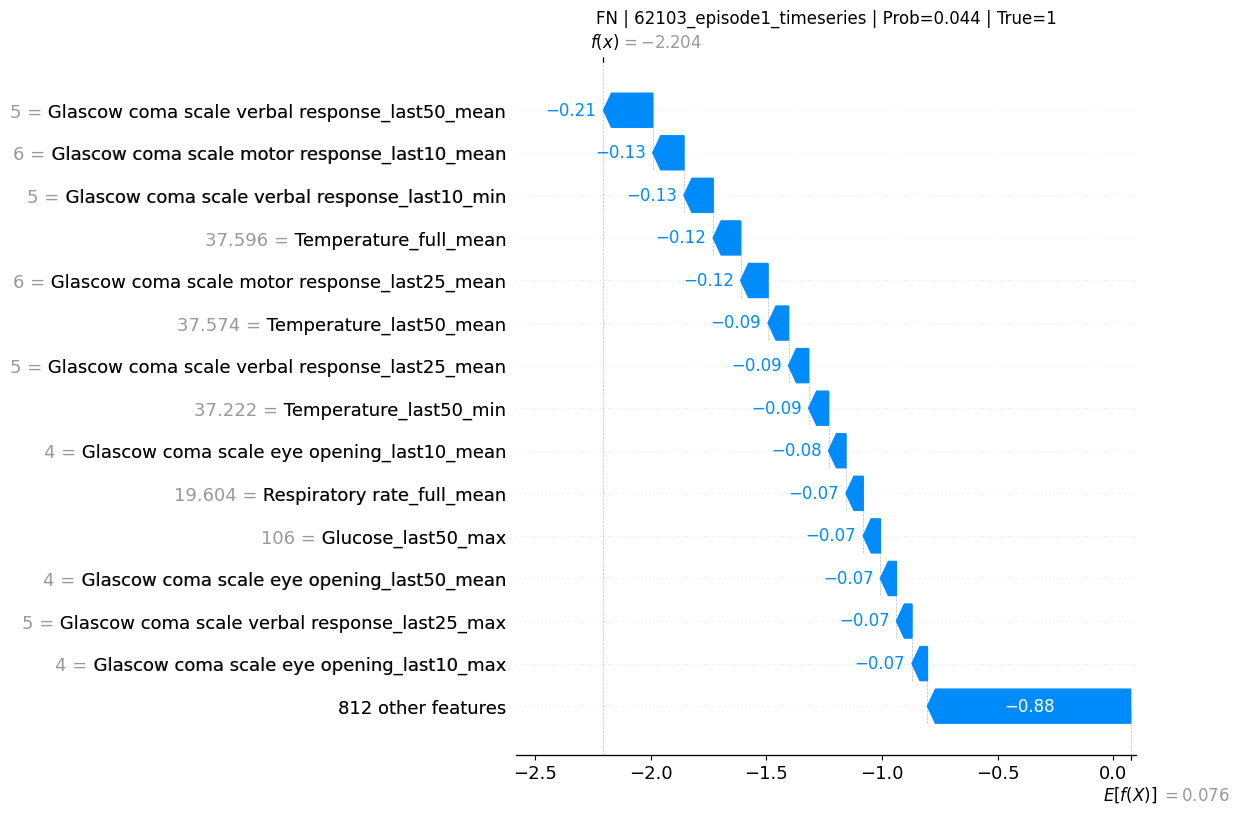

Saved waterfall plot to: /content/drive/MyDrive/MIMIC_ensemble/experiment5_shap_cases/shap_waterfall_FN_62103_episode1_timeseries.png


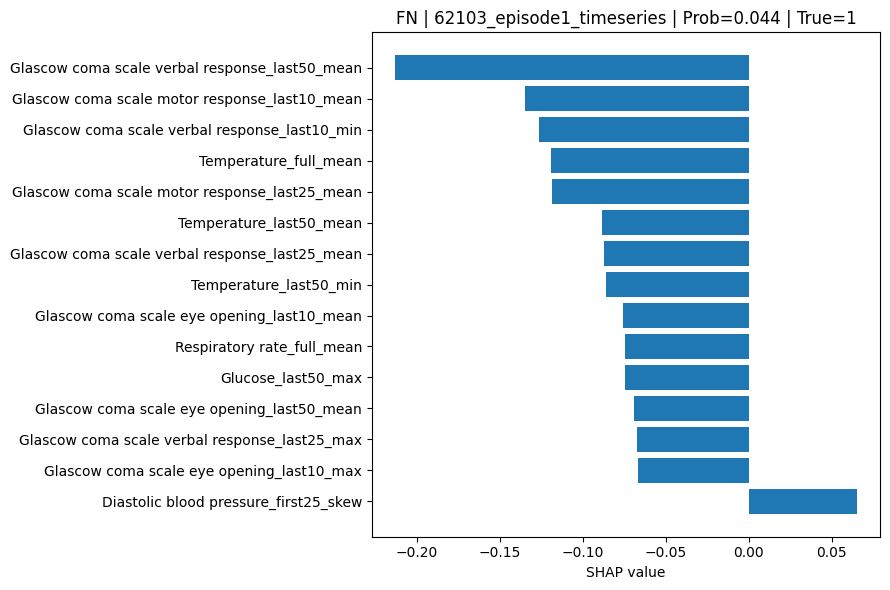

Saved SHAP bar plot to: /content/drive/MyDrive/MIMIC_ensemble/experiment5_shap_cases/shap_bar_FN_62103_episode1_timeseries.png

Saved SHAP plot manifest to: /content/drive/MyDrive/MIMIC_ensemble/experiment5_shap_cases/experiment5_shap_plot_manifest.csv


,case_type,stay,case_idx,y_true,ensemble_prob,waterfall_plot,bar_plot
0,TP,25556_episode1_timeseries.csv,1167,1,0.992923,/content/drive/MyDrive/MIMIC_ensemble/experime...,/content/drive/MyDrive/MIMIC_ensemble/experime...
1,TN,4625_episode1_timeseries.csv,1876,0,0.006605,/content/drive/MyDrive/MIMIC_ensemble/experime...,/content/drive/MyDrive/MIMIC_ensemble/experime...
2,FP,20794_episode2_timeseries.csv,784,0,0.955247,/content/drive/MyDrive/MIMIC_ensemble/experime...,/content/drive/MyDrive/MIMIC_ensemble/experime...
3,FN,62103_episode1_timeseries.csv,2294,1,0.043954,/content/drive/MyDrive/MIMIC_ensemble/experime...,/content/drive/MyDrive/MIMIC_ensemble/experime...


In [2]:
import os
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer

# ============================================================
# Paths
# ============================================================
BASE_DIR = "/content/drive/MyDrive/MIMIC_ensemble"
DATA_PATH = "/content/drive/MyDrive/in-hospital-mortality-7subseq-features/"

MODEL_PATH = f"{BASE_DIR}/xgb_model_exp1.json"
SELECTED_CASES_PATH = f"{BASE_DIR}/experiment5_selected_cases_ensemble_48h.csv"

SAVE_DIR = f"{BASE_DIR}/experiment5_shap_cases"
os.makedirs(SAVE_DIR, exist_ok=True)

# ============================================================
# Helper: sanitize names for file saving
# ============================================================
def safe_name(text: str) -> str:
    return (
        str(text)
        .replace(".csv", "")
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
    )

# ============================================================
# Load train/test data
# ============================================================
train_df = pd.read_csv(DATA_PATH + "train_features.csv")
test_df = pd.read_csv(DATA_PATH + "test_features.csv")

X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

# Test listfile must align row-wise with test_features.csv
test_listfile = pd.read_csv(DATA_PATH + "test_listfile.csv")
test_listfile.columns = ["stay", "y_true"]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("test_listfile shape:", test_listfile.shape)

# ============================================================
# Recreate same imputation pipeline used for XGBoost
# ============================================================
imputer = SimpleImputer(strategy="mean")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Keep only columns that survived imputation
kept_cols = X_train.columns[~np.isnan(imputer.statistics_)]

X_train_imp = pd.DataFrame(X_train_imp, columns=kept_cols)
X_test_imp = pd.DataFrame(X_test_imp, columns=kept_cols)

print("Imputed X_test shape:", X_test_imp.shape)

# ============================================================
# Load model
# ============================================================
model = xgb.XGBClassifier()
model.load_model(MODEL_PATH)
print("Loaded model from:", MODEL_PATH)

# ============================================================
# Compute SHAP values once
# ============================================================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_imp)

print("SHAP values shape:", np.array(shap_values).shape)

# ============================================================
# Load selected cases
# ============================================================
selected_cases = pd.read_csv(SELECTED_CASES_PATH)
print(selected_cases.head())
print("Selected cases shape:", selected_cases.shape)

required_cols = {"case_type", "stay"}
missing = required_cols - set(selected_cases.columns)
if missing:
    raise ValueError(f"Selected cases CSV missing required columns: {missing}")

# ============================================================
# Build stay -> row index mapping
# ============================================================
# normalize in case of accidental whitespace
test_listfile["stay"] = test_listfile["stay"].astype(str).str.strip()
selected_cases["stay"] = selected_cases["stay"].astype(str).str.strip()

stay_to_idx = {stay: idx for idx, stay in enumerate(test_listfile["stay"])}

# ============================================================
# Plot functions
# ============================================================
def plot_shap_waterfall_for_case(case_idx, case_type, stay, y_true=None, pred_prob=None):
    case_features = X_test_imp.iloc[case_idx]

    exp = shap.Explanation(
        values=shap_values[case_idx],
        base_values=explainer.expected_value,
        data=case_features.values,
        feature_names=case_features.index.tolist(),
    )

    plt.figure()
    shap.plots.waterfall(exp, max_display=15, show=False)

    title_parts = [f"{case_type}", safe_name(stay)]
    if pred_prob is not None:
        title_parts.append(f"Prob={pred_prob:.3f}")
    if y_true is not None:
        title_parts.append(f"True={int(y_true)}")

    plt.title(" | ".join(title_parts))

    save_path = os.path.join(
        SAVE_DIR,
        f"shap_waterfall_{safe_name(case_type)}_{safe_name(stay)}.png"
    )
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved waterfall plot to:", save_path)

    return save_path


def plot_shap_bar_for_case(case_idx, case_type, stay, y_true=None, pred_prob=None, top_n=15):
    contrib_df = pd.DataFrame({
        "feature": X_test_imp.columns,
        "shap_value": shap_values[case_idx],
    })
    contrib_df["abs_shap"] = contrib_df["shap_value"].abs()
    contrib_df = contrib_df.sort_values("abs_shap", ascending=False).head(top_n)

    plt.figure(figsize=(9, 6))
    plt.barh(contrib_df["feature"][::-1], contrib_df["shap_value"][::-1])
    plt.xlabel("SHAP value")

    title_parts = [f"{case_type}", safe_name(stay)]
    if pred_prob is not None:
        title_parts.append(f"Prob={pred_prob:.3f}")
    if y_true is not None:
        title_parts.append(f"True={int(y_true)}")

    plt.title(" | ".join(title_parts))
    plt.tight_layout()

    save_path = os.path.join(
        SAVE_DIR,
        f"shap_bar_{safe_name(case_type)}_{safe_name(stay)}.png"
    )
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved SHAP bar plot to:", save_path)

    return save_path


# ============================================================
# Run for all selected cases
# ============================================================
output_rows = []

for _, row in selected_cases.iterrows():
    case_type = str(row["case_type"]).strip().upper()
    stay = str(row["stay"]).strip()

    if stay not in stay_to_idx:
        print(f"WARNING: stay not found in test_listfile, skipping: {stay}")
        continue

    case_idx = stay_to_idx[stay]

    y_true_val = row["y_true"] if "y_true" in selected_cases.columns else None
    pred_prob_val = row["ensemble_prob"] if "ensemble_prob" in selected_cases.columns else None

    print(f"\nProcessing {case_type} | {stay} | idx={case_idx}")

    waterfall_path = plot_shap_waterfall_for_case(
        case_idx=case_idx,
        case_type=case_type,
        stay=stay,
        y_true=y_true_val,
        pred_prob=pred_prob_val,
    )

    bar_path = plot_shap_bar_for_case(
        case_idx=case_idx,
        case_type=case_type,
        stay=stay,
        y_true=y_true_val,
        pred_prob=pred_prob_val,
        top_n=15,
    )

    output_rows.append({
        "case_type": case_type,
        "stay": stay,
        "case_idx": case_idx,
        "y_true": y_true_val,
        "ensemble_prob": pred_prob_val,
        "waterfall_plot": waterfall_path,
        "bar_plot": bar_path,
    })

# ============================================================
# Save plot manifest
# ============================================================
manifest_df = pd.DataFrame(output_rows)
manifest_path = os.path.join(SAVE_DIR, "experiment5_shap_plot_manifest.csv")
manifest_df.to_csv(manifest_path, index=False)

print("\nSaved SHAP plot manifest to:", manifest_path)
manifest_df